# EBSD Recurrence Analysis

**Self-contained recurrence-plot / RQA analysis on EBSD scalar fields.**

Sections:
1. Data loading + grain ID + smart fill (matches `ebsd_wtmm_pergrain_pantleon.ipynb`).
2. Per-grain demean → `combined_log`, `combined_mask`.
3. Kantelhardt shuffle → `combined_log_shuf`, `combined_log_shufall`.
4. Tensor WTMM (alpha-TWTMM SVD) → `svd_fields['alpha_sigma_max']` etc.
5. NNLS slip-system resolution (LP solver) → `gnd_total`, `_alpha_3x3`.
6. Bundle candidate scalar fields → `rqa_fields`.
7. Delay-embedding RP / multi-threshold RP + RQA.
8. Cross / Joint RP + CRQA / JRQA.
9. Filter parameter sweep (separate cell — slow; doesn't auto-run).
10. Per-tier RQA box-and-whisker plots across H rows and V cols.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import fftfreq
import ipywidgets as widgets
from IPython.display import display
import sys

import mlx.core as mx

sys.path.insert(0, 'XSmurfWrapper')
import xsmurf_wrapper as xsm

print(f"MLX: {mx.__version__}, xsmurf: {xsm.__version__}")
# --- Shear-zone additions ---
try:
    from orix.quaternion import Orientation, Rotation
    from orix.quaternion.symmetry import D2, D3, C1
    _HAS_ORIX = True
    print(f'orix available for rotation + symmetry ops')
except ImportError:
    _HAS_ORIX = False
    print('orix not in this env — rotation + KAM fall back to pure-numpy path')

JOSEPHINE_ROTATION_XLSX = Path('EBSD/Josephine_Peridotite_Olivine/1365-3_RotationMetadata.xlsx')
EBSD_DIR = Path('/Users/amasaryk/projects/Creep/wavelet/EBSD')


MLX: 0.31.1, xsmurf: 0.1.0
orix available for rotation + symmetry ops


In [2]:
def compute_scales(n_oct, n_vox, a_min=1):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm
            for o in range(n_oct) for v in range(n_vox)]

def _build_wavelet_filters_f32(kx, ky, scale, wavelet='gaussian'):
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)
    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)
    if wavelet == 'mexican':
        k2 = sx * sx + sy * sy
        return {
            'dx':  to_complex(zero, sx * k2 * gauss),
            'dy':  to_complex(zero, sy * k2 * gauss),
            'dxx':  to_complex(-sx * sx * k2 * gauss, zero),
            'dxy':  to_complex(-sy * sx * k2 * gauss, zero),
            'dyy':  to_complex(-sy * sy * k2 * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * k2 * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * k2 * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * k2 * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * k2 * gauss),
        }
    else:
        return {
            'dx':  to_complex(zero, sx * gauss),
            'dy':  to_complex(zero, sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss, zero),
            'dxy':  to_complex(-sy * sx * gauss, zero),
            'dyy':  to_complex(-sy * sy * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }

def cwt_2d_f32(image, scales, pad=32, derivs='first', wavelet='gaussian', verbose=True):
    """2D CWT via MLX FFT. derivs='first' for dx,dy only; 'all' for up to 3rd order."""
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))
    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))
    if derivs == 'first':
        names = ['dx', 'dy']
    else:
        names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    n_scales = len(scales)
    result = {n: np.zeros((n_scales, ny, nx), dtype=np.float32) for n in names}
    result['mod'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    for i, scale in enumerate(scales):
        filters = _build_wavelet_filters_f32(KX, KY, scale, wavelet=wavelet)
        for name in names:
            conv = mx.fft.ifft2(image_fft * filters[name])
            result[name][i] = np.array(conv.real)[crop]
        dx_s, dy_s = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx_s * dx_s + dy_s * dy_s)
        result['arg'][i] = np.arctan2(dy_s, dx_s).astype(np.float32)
        if verbose and (i % max(1, n_scales // 4) == 0 or i == n_scales - 1):
            print(f'  Scale {i}/{n_scales-1}: a={scale:.1f}')
    mx.eval()
    return result

def tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3):
    """SVD of 3x2 Jacobian at every pixel via closed-form J^T J eigenvalues."""
    a = gx1*gx1 + gx2*gx2 + gx3*gx3
    b = gx1*gy1 + gx2*gy2 + gx3*gy3
    d = gy1*gy1 + gy2*gy2 + gy3*gy3
    trace = a + d
    det = a * d - b * b
    disc = np.sqrt(np.maximum((trace / np.float32(2))**2 - det, np.float32(0)))
    lambda1 = trace / np.float32(2) + disc
    lambda2 = np.maximum(trace / np.float32(2) - disc, np.float32(0))
    sigma_max = np.sqrt(np.maximum(lambda1, np.float32(0))).astype(np.float32)
    sigma_min = np.sqrt(lambda2).astype(np.float32)
    vx = lambda1 - d
    vy = b
    vnorm = np.sqrt(vx**2 + vy**2) + np.float32(1e-30)
    arg = np.arctan2(vy / vnorm, vx / vnorm).astype(np.float32)
    return sigma_max, sigma_min, arg

from xsmurf_wrapper.wavelet import gkapa_numpy, gkapap_numpy


print('CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined')


CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined


In [3]:
%matplotlib widget


In [4]:
def read_ctf(filepath):
    """Read an Oxford Instruments .ctf (Channel Text File) EBSD dataset.
    
    Returns
    -------
    data : dict with 2D arrays for each field + metadata dict
    """
    filepath = Path(filepath)
    with open(filepath, 'r', errors='replace') as f:
        lines = f.readlines()

    meta = {'filepath': str(filepath), 'name': filepath.stem}
    phases = {}
    header_line = None

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.startswith('XCells'):
            meta['xcells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('YCells'):
            meta['ycells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('XStep'):
            meta['xstep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('YStep'):
            meta['ystep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('Phases'):
            n_phases = int(stripped.split('\t')[1])
            for j in range(1, n_phases + 1):
                phases[j] = lines[i + j].strip().split('\t')
            meta['phases'] = phases
            meta['n_phases'] = n_phases
        elif stripped.startswith('Phase\tX\tY'):
            header_line = i
            break

    if header_line is None:
        raise ValueError(f"Could not find data header in {filepath}")

    # Read tabular data
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line, engine='python',
                     on_bad_lines='skip')
    
    nx, ny = meta['xcells'], meta['ycells']
    expected = nx * ny
    actual = len(df)
    if actual != expected:
        print(f"  Warning: expected {expected} rows ({nx}x{ny}), got {actual}")
        # Truncate or pad
        if actual > expected:
            df = df.iloc[:expected]
        else:
            nx_adj = actual // ny if ny > 0 else nx
            meta['xcells'] = nx_adj
            nx = nx_adj

    data = {'meta': meta}
    shape = (ny, nx)
    for col in df.columns:
        try:
            data[col] = df[col].values.reshape(shape)
        except ValueError:
            data[col] = df[col].values  # keep flat if reshape fails

    # Convenience aliases
    data['euler1'] = data.get('Euler1', None)
    data['euler2'] = data.get('Euler2', None)
    data['euler3'] = data.get('Euler3', None)
    data['bc'] = data.get('BC', None)
    data['bs'] = data.get('BS', None)
    data['mad'] = data.get('MAD', None)
    data['phase'] = data.get('Phase', None)

    print(f"  Loaded {filepath.name}: {nx} x {ny}, step={meta.get('xstep','?')} µm, "
          f"{meta.get('n_phases','?')} phases")
    return data
# --- Oxford Instruments Channel 5 .cpr/.crc binary reader ---
# Pure-numpy reader for .cpr (ASCII INI metadata) + .crc (binary data) pairs.
# Field code mapping taken from defdap.file_readers.OxfordBinaryLoader source.
# Unlike defdap's loader, this one does NOT construct a crystal Phase object
# so it works for any Laue group (including trigonal quartz, monoclinic
# feldspars, etc.) that the narrow defdap Phase class would reject.

import re as _re_cpr

_CPR_FIELD_LOOKUP = {
    3:  ('ph1',      'float32'),   # Euler1 phi1 (rad)
    4:  ('phi',      'float32'),   # Euler2 Phi  (rad)
    5:  ('ph2',      'float32'),   # Euler3 phi2 (rad)
    6:  ('MAD',      'float32'),   # mean angular deviation
    7:  ('BC',       'uint8'),     # band contrast
    8:  ('BS',       'uint8'),     # band slope
    10: ('numBands', 'uint8'),
    11: ('AFI',      'uint8'),
    12: ('IB6',      'float32'),
}


def _parse_cpr_ini(cpr_path):
    text = Path(cpr_path).read_text(errors='replace')
    groups = {}
    current = None
    group_re = _re_cpr.compile(r'^\[(.+)\]\s*$')
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith(';'):
            continue
        m = group_re.match(line)
        if m:
            current = m.group(1)
            groups.setdefault(current, {})
            continue
        if current is None:
            continue
        if '=' in line:
            k, v = line.split('=', 1)
            groups[current][k.strip()] = v.strip()
    return groups


def read_cpr(filepath):
    """Read an Oxford Instruments .cpr/.crc file pair.

    Returns the same dict shape as read_ctf():
        meta          dict with xcells, ycells, xstep, ystep, phases, n_phases, name
        euler1/2/3    (ny, nx) float32 arrays in DEGREES
        phase         (ny, nx) uint8 array
        bc, bs, mad   (ny, nx) arrays if present
        Plus any EDX windows as EDX_<element> keys.
    """
    filepath = Path(filepath)
    cpr_path = filepath.with_suffix('.cpr')
    crc_path = filepath.with_suffix('.crc')
    if not cpr_path.exists():
        raise FileNotFoundError(f"CPR header not found: {cpr_path}")
    if not crc_path.exists():
        raise FileNotFoundError(f"CRC binary not found: {crc_path}")

    groups = _parse_cpr_ini(cpr_path)

    # Grid & step
    job = groups.get('Job', {})
    nx = int(job['xCells'])
    ny = int(job['yCells'])
    xstep = float(job.get('GridDistX', 1.0))
    ystep = float(job.get('GridDistY', xstep))

    # Phases: assemble ctf-like metadata so downstream cells keep working
    pg = groups.get('Phases', {})
    n_phases = int(pg.get('Count', 0))
    phases = {}
    for i in range(1, n_phases + 1):
        pi = groups.get(f'Phase{i}', {})
        lattice = '{};{};{}'.format(pi.get('a', '?'), pi.get('b', '?'), pi.get('c', '?'))
        angles = '{};{};{}'.format(pi.get('alpha', '?'), pi.get('beta', '?'), pi.get('gamma', '?'))
        phases[i] = [lattice, angles,
                     pi.get('StructureName', f'phase_{i}'),
                     pi.get('LaueGroup', '?'), pi.get('SpaceGroup', '?')]

    # EDX window names (field codes 100+i)
    edx_names = {}
    edx_group = groups.get('EDX Windows', {})
    if edx_group:
        n_edx = int(edx_group.get('Count', 0))
        for i in range(1, n_edx + 1):
            key = edx_group.get(f'Window{i}', f'edx{i}')
            edx_names[100 + i] = key

    # Build the binary record dtype from the [Fields] section
    fg = groups.get('Fields', {})
    n_fields = int(fg.get('Count', 0))
    dtype_items = [('phase', 'uint8')]   # phase is always first, uint8
    unknown = 0
    for i in range(1, n_fields + 1):
        code = int(fg[f'Field{i}'])
        if code in _CPR_FIELD_LOOKUP:
            dtype_items.append(_CPR_FIELD_LOOKUP[code])
        elif code in edx_names:
            dtype_items.append((f'EDX_{edx_names[code]}', 'float32'))
        else:
            unknown += 1
            dtype_items.append((f'unknown_{unknown}_code{code}', 'float32'))
            print(f'  warning: unknown CPR field code {code}, guessing float32')
    record_dtype = np.dtype(dtype_items)

    # Load binary
    raw = np.fromfile(str(crc_path), dtype=record_dtype, count=nx * ny)
    if raw.size != nx * ny:
        raw = raw[:nx * ny]
        print(f'  warning: CRC short read ({raw.size} records)')

    shape = (ny, nx)
    data = {'meta': {
        'filepath': str(filepath),
        'name': filepath.stem,
        'xcells': nx, 'ycells': ny,
        'xstep': xstep, 'ystep': ystep,
        'phases': phases, 'n_phases': n_phases,
        'format': 'cpr',
    }}

    data['phase'] = raw['phase'].reshape(shape)

    # CPR stores Euler in radians; convert to degrees to match ctf convention
    for raw_key, deg_key in [('ph1', 'euler1'), ('phi', 'euler2'), ('ph2', 'euler3')]:
        if raw_key in raw.dtype.names:
            data[deg_key] = np.rad2deg(raw[raw_key].reshape(shape)).astype(np.float32)

    if 'MAD' in raw.dtype.names: data['mad'] = raw['MAD'].reshape(shape)
    if 'BC'  in raw.dtype.names: data['bc']  = raw['BC'].reshape(shape)
    if 'BS'  in raw.dtype.names: data['bs']  = raw['BS'].reshape(shape)
    if 'numBands' in raw.dtype.names: data['bands'] = raw['numBands'].reshape(shape)
    for name in raw.dtype.names:
        if name.startswith('EDX_'):
            data[name] = raw[name].reshape(shape)

    print(f'  CPR: {nx}x{ny} @ {xstep} um, {n_phases} phases, {len(dtype_items)} fields')
    return data


def read_ebsd(filepath):
    """Dispatch to the right EBSD reader based on file extension."""
    filepath = Path(filepath)
    ext = filepath.suffix.lower()
    if ext == '.ctf':
        return read_ctf(filepath)
    elif ext in ('.cpr', '.crc'):
        return read_cpr(filepath)
    else:
        raise ValueError(f"Unsupported EBSD extension: {ext} (expected .ctf or .cpr/.crc)")


In [5]:
EBSD_DIR = Path('EBSD')

# --- Loadable files: .ctf (ASCII) and .cpr (Oxford binary via read_cpr) ---
ctf_files = sorted(EBSD_DIR.rglob('*.ctf'))
cpr_files = sorted(EBSD_DIR.rglob('*.cpr'))
ebsd_files = sorted(ctf_files + cpr_files, key=lambda p: (p.parts[:-1], p.name))

# Shear-zone folder tags
SHEAR_ZONE_TAGS = {
    'Calamita_Elba_Quartzite':           ('[CAL]', 'Calamita quartzite'),
    'Kuckaus_Namibia_Feldspar_Mylonite': ('[KUC]', 'Kuckaus polymineralic mylonite'),
    'Josephine_Peridotite_Olivine':      ('[JOS]', 'Josephine peridotite'),
}

def _tag(path):
    rel = path.relative_to(EBSD_DIR)
    root = rel.parts[0] if rel.parts else ''
    return SHEAR_ZONE_TAGS.get(root, ('[...]', root))[0]

labels = []
for p in ebsd_files:
    rel = p.relative_to(EBSD_DIR)
    labels.append(f'{_tag(p)} {rel}  [{p.suffix[1:]}]')

print(f'Found {len(ebsd_files)} EBSD files ({len(ctf_files)} CTF + {len(cpr_files)} CPR):\n')
from collections import defaultdict
by_tag = defaultdict(list)
for i, p in enumerate(ebsd_files):
    by_tag[_tag(p)].append(i)
for tag, idxs in by_tag.items():
    print(f'  {tag}  ({len(idxs)} files)')
    for i in idxs:
        rel = ebsd_files[i].relative_to(EBSD_DIR)
        print(f'    [{i:3d}] {rel}  [{ebsd_files[i].suffix[1:]}]')
    print()


Found 94 EBSD files (54 CTF + 40 CPR):

  [...]  (57 files)
    [  0] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Processed.ctf  [ctf]
    [  1] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Raw.ctf  [ctf]
    [  2] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Processed.ctf  [ctf]
    [  3] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Raw.ctf  [ctf]
    [  4] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite.ctf  [ctf]
    [  5] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite_processed.ctf  [ctf]
    [  6] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_Original.ctf  [ctf]
    [  7] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ci.ctf  [ctf]
    [  8] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4cii.ctf  [ctf]
    [  9] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ciii.ctf  [ctf]
    [ 10] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4di.ctf  [ctf]
    [ 11] 2015-06-26_Pearce_Mark_13963v1/data/Twin

In [10]:
# ---- Pick a dataset by index ----
DATASET_IDX = 21# <-- change this to select a different file

ebsd_path = ebsd_files[DATASET_IDX]
ctf_path = ebsd_path                        # alias: downstream cells look at ctf_path
print(f'Selected: {labels[DATASET_IDX]}')
print(f'  Path: {ebsd_path}')

ebsd = read_ebsd(ebsd_path)
meta = ebsd['meta']


Selected: [CAL] Calamita_Elba_Quartzite/EBSD Map 2/SP78_Map_2.cpr  [cpr]
  Path: EBSD/Calamita_Elba_Quartzite/EBSD Map 2/SP78_Map_2.cpr
  CPR: 1237x927 @ 1.1 um, 1 phases, 10 fields


Phases: {np.uint8(0): np.int64(116081), np.uint8(1): np.int64(1030618)}
Dominant phase: 1
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
Phase mask: 1030618/1146699 (89.9%)
Computing KAM (kernel=1)...
  Kernel=1 -> 3x3, 4 unique neighbor pairs


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_8183/1500603122.py:91: RuntimeWarning: invalid value encountered in divide
  kam = np.where(count > 0, kam / count, 0)


KAM: [0.0000, 93.3600] deg, median=0.5976


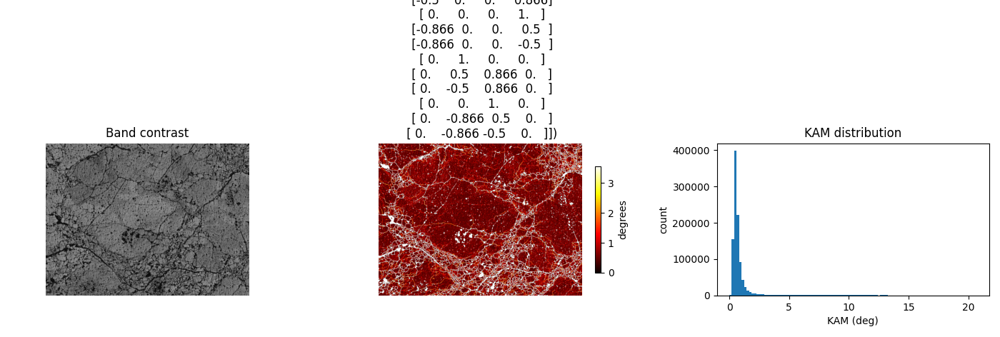

In [11]:
# ===== KAM via orix (symmetry-aware) =====

from orix.quaternion import Orientation
from orix.quaternion.symmetry import C1, C2, D2, D3, D6, C4, Oh

# ---------- USER PARAMETERS ----------
KAM_KERNEL = 1   # Kernel radius: 1 = 3x3, 2 = 5x5, 3 = 7x7, etc.
# --------------------------------------

LAUE_TO_ORIX = {
    '1': C1, '2': C2, '3': D2, '6': D3, '7': D6, '9': Oh, '11': C1,
}

def get_phase_symmetry(ebsd_data, phase_id=1):
    phases = ebsd_data['meta'].get('phases', {})
    if phase_id in phases:
        info = phases[phase_id]
        laue_str = str(info[3]).strip() if len(info) > 3 else '?'
        sym = LAUE_TO_ORIX.get(laue_str, None)
        name = info[2] if len(info) > 2 else f'phase_{phase_id}'
        print(f'  Phase {phase_id}: {name}, Laue={laue_str} -> {sym}')
        return sym
    return None


def compute_kam_orix(e1_deg, e2_deg, e3_deg, symmetry, mask=None,
                      kernel=1, degrees=True):
    """Compute KAM using orix Orientation.angle_with().

    kernel: neighborhood radius in pixels.
        1 = 3x3 (8 neighbors), 2 = 5x5 (24 neighbors), etc.
        Matches MTEX/OIM convention.
    """
    ny, nx = e1_deg.shape
    euler_rad = np.deg2rad(np.stack([e1_deg, e2_deg, e3_deg], axis=-1)).astype(np.float64)

    ori = Orientation.from_euler(euler_rad.reshape(-1, 3), symmetry=symmetry)
    ori = ori.reshape(ny, nx)

    kam = np.zeros((ny, nx), dtype=np.float64)
    count = np.zeros((ny, nx), dtype=np.float64)

    if mask is None:
        mask = np.ones((ny, nx), dtype=bool)

    # Generate all (dy, dx) offsets within the kernel radius
    offsets = []
    for dy in range(-kernel, kernel + 1):
        for dx in range(-kernel, kernel + 1):
            if dy == 0 and dx == 0:
                continue
            # Only count each pair once: (dy,dx) and (-dy,-dx) are the same pair
            if (dy, dx) > (0, 0) or (dy == 0 and dx > 0):
                offsets.append((dy, dx))

    print(f'  Kernel={kernel} -> {2*kernel+1}x{2*kernel+1}, {len(offsets)} unique neighbor pairs')

    for dy, dx in offsets:
        # Slice pairs so ori1[i,j] is compared with ori2[i,j] = ori1[i+dy, j+dx]
        if dy >= 0:
            sy1 = slice(None, ny - dy) if dy > 0 else slice(None)
            sy2 = slice(dy, None) if dy > 0 else slice(None)
        else:
            sy1 = slice(-dy, None)
            sy2 = slice(None, ny + dy)

        if dx >= 0:
            sx1 = slice(None, nx - dx) if dx > 0 else slice(None)
            sx2 = slice(dx, None) if dx > 0 else slice(None)
        else:
            sx1 = slice(-dx, None)
            sx2 = slice(None, nx + dx)

        o1 = ori[sy1, sx1]
        o2 = ori[sy2, sx2]
        m = mask[sy1, sx1] & mask[sy2, sx2]

        if not m.any():
            continue

        angles = np.full(o1.shape, np.nan)
        angles[m] = o1[m].angle_with(o2[m])
        v = np.isfinite(angles)
        a = np.where(v, angles, 0)

        kam[sy1, sx1] += a
        kam[sy2, sx2] += a
        count[sy1, sx1] += v
        count[sy2, sx2] += v

    kam = np.where(count > 0, kam / count, 0)
    kam[~mask] = np.nan
    if degrees:
        kam = np.rad2deg(kam)
    return kam


# --- Compute KAM for current dataset ---
phase_map = ebsd['phase']
unique_phases, phase_counts = np.unique(phase_map, return_counts=True)
dominant_phase = unique_phases[np.argmax(phase_counts)]
print(f'Phases: {dict(zip(unique_phases, phase_counts))}')
print(f'Dominant phase: {dominant_phase}')

sym = get_phase_symmetry(ebsd, phase_id=dominant_phase)
if sym is None:
    for pid in unique_phases:
        sym = get_phase_symmetry(ebsd, phase_id=int(pid))
        if sym is not None:
            dominant_phase = int(pid)
            break
if sym is None:
    print('WARNING: could not determine symmetry, using C1')
    sym = C1

phase_mask = (phase_map == dominant_phase)
print(f'Phase mask: {phase_mask.sum()}/{phase_mask.size} ({phase_mask.mean():.1%})')

print(f'Computing KAM (kernel={KAM_KERNEL})...')
kam = compute_kam_orix(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'],
                        symmetry=sym, mask=phase_mask,
                        kernel=KAM_KERNEL, degrees=True)
print(f'KAM: [{np.nanmin(kam):.4f}, {np.nanmax(kam):.4f}] deg, median={np.nanmedian(kam):.4f}')

ny, nx = kam.shape
aspect = ny / nx
fig_w = 14
fig_h = max(4, fig_w * aspect * 0.45)

fig, axes = plt.subplots(1, 3, figsize=(fig_w, fig_h))
axes[0].imshow(ebsd['bc'], cmap='gray', aspect='equal')
axes[0].set_title('Band contrast')
im = axes[1].imshow(kam, cmap='hot', vmin=0, vmax=np.nanpercentile(kam, 95), aspect='equal')
axes[1].set_title(f'KAM (kernel={KAM_KERNEL}, {sym})')
plt.colorbar(im, ax=axes[1], label='degrees', shrink=0.7)
axes[2].hist(kam[np.isfinite(kam)].ravel(), bins=100,
             range=(0, np.nanpercentile(kam, 99)))
axes[2].set(xlabel='KAM (deg)', ylabel='count', title='KAM distribution')
for ax in axes[:2]: ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# ===== Quaternion helpers (shared) =====
def _quat_mul(a, b):
    """Hamilton product.  Broadcasts over leading dims.  Last dim = 4 (w, x, y, z)."""
    aw, ax, ay, az = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    bw, bx, by, bz = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return np.stack([
        
        aw * bw - ax * bx - ay * by - az * bz,
        aw * bx + ax * bw + ay * bz - az * by,
        aw * by - ax * bz + ay * bw + az * bx,
        aw * bz + ax * by - ay * bx + az * bw,
    ], axis=-1)

def _quat_conj(q):
    out = q.copy()
    out[..., 1:] *= -1.0
    return out


## Grain identification (adjacency flood-fill, no kernels)

  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
Grains found: 14969 total, 2767 with >= 10 px
Median grain size: 1 px, max: 151066 px

Smart fill (cluster-classified Voronoi):
  Small-cluster classification (size < 10 px):
    Engulfed (one large neighbour): 6944 clusters (12,710 px)  -> dissolved
    Between (2+ large neighbours): 1796 clusters (6,121 px)  -> dissolved (Voronoi-split)
    Isolated (no large neighbours): 892 clusters (1,305 px)  -> kept
  Filled 116,081 unindexed/zero pixels (Voronoi from nearest large grain)
  Active grains after fill: 3804 (2779 >= 10 px, 1025 still < 10 px)
  Median grain size af

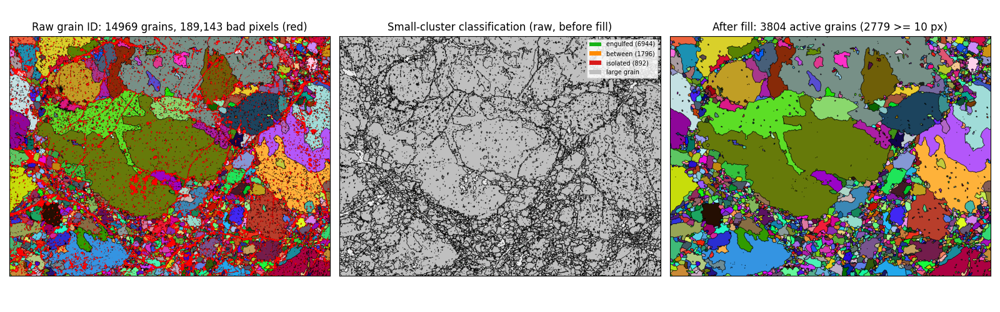

In [12]:
# ===== Grain identification via symmetry-aware adjacency flood-fill =====
# No kernels / windows: pixel neighbors only.  scipy.ndimage.label on a
# "same grain" adjacency graph built from per-neighbor misorientation.

from scipy.ndimage import label as ndi_label

# ---- parameters ----
GRAIN_THETA_DEG   = 7.0  # high-angle GB threshold (deg); 2 deg for subgrains
GRAIN_MIN_PIXELS  = 10    # drop grains smaller than this (stats only)
# ---------------------

def _sym_miso_angle(q_a, q_b, sym_q):
    """Symmetry-reduced misorientation angle between two quaternion arrays.
    q_a, q_b: (N, 4) unit quaternions.  sym_q: (S, 4) symmetry ops.
    Returns (N,) angles in radians (smallest under the point group)."""
    q_rel = _quat_mul(_quat_conj(q_a), q_b)           # (N, 4)
    q_sym = _quat_mul(q_rel[:, None, :], sym_q[None, :, :])  # (N, S, 4)
    w = np.abs(q_sym[..., 0])                         # (N, S)
    w_max = np.clip(w.max(axis=1), -1.0, 1.0)
    return 2.0 * np.arccos(w_max)

def identify_grains(ebsd_data, theta_c_deg=GRAIN_THETA_DEG):
    """Symmetry-aware grain segmentation.
    Returns: grain_id (ny, nx) int32 (0 = unindexed/background, ≥1 = grain id).
    Algorithm:
      - for each phase, compute pixel-right and pixel-down misorientation (adjacency only)
      - threshold to build 'same grain' edge graph
      - connected-components label within phase
      - concatenate grain ids across phases with unique offsets
    """
    e1 = np.deg2rad(ebsd_data['euler1'].astype(np.float64))
    e2 = np.deg2rad(ebsd_data['euler2'].astype(np.float64))
    e3 = np.deg2rad(ebsd_data['euler3'].astype(np.float64))
    phase = ebsd_data['phase']
    ny, nx = e1.shape

    # Build unit quaternion map (from Euler via orix)
    ori_all = Orientation.from_euler(np.stack([e1.ravel(), e2.ravel(), e3.ravel()], axis=1))
    q = ori_all.data.reshape(ny, nx, 4).astype(np.float64)
    q *= np.where(q[..., 0:1] >= 0, 1.0, -1.0)

    theta_c = np.deg2rad(theta_c_deg)
    grain_id = np.zeros((ny, nx), dtype=np.int32)
    gid_offset = 0

    for pid in [int(p) for p in np.unique(phase) if int(p) > 0]:
        pmask = (phase == pid)
        if pmask.sum() < GRAIN_MIN_PIXELS:
            continue
        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        sym_q = sym.data.astype(np.float64)

        # Right-neighbor misorientation: between (y, x) and (y, x+1)
        a = q[:, :-1, :].reshape(-1, 4)
        b = q[:,  1:, :].reshape(-1, 4)
        theta_right = _sym_miso_angle(a, b, sym_q).reshape(ny, nx - 1)

        # Down-neighbor misorientation: between (y, x) and (y+1, x)
        a = q[:-1, :, :].reshape(-1, 4)
        b = q[ 1:, :, :].reshape(-1, 4)
        theta_down = _sym_miso_angle(a, b, sym_q).reshape(ny - 1, nx)

        # Build same-phase adjacency: both pixels must be in this phase
        both_r = pmask[:, :-1] & pmask[:, 1:]
        both_d = pmask[:-1, :] & pmask[1:, :]

        # Same-grain edges
        same_r = both_r & (theta_right < theta_c)
        same_d = both_d & (theta_down  < theta_c)

        # Expand edge flags to a 4-connected adjacency-friendly mask:
        # a pixel is "connected to its right/down neighbor" iff same_r/same_d is True.
        # scipy.ndimage.label can use a custom structure on a binary image, but we
        # want connectivity conditional on edge labels.  Easiest: build a pseudo-pixel
        # structure by union-find over edges.
        # Use a lightweight Union-Find implementation.
        n_pix = ny * nx
        parent = np.arange(n_pix, dtype=np.int64)

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i

        def union(i, j):
            ri, rj = find(i), find(j)
            if ri != rj:
                parent[rj] = ri

        ys, xs = np.where(same_r)
        for y, x in zip(ys, xs):
            union(y * nx + x, y * nx + (x + 1))

        ys, xs = np.where(same_d)
        for y, x in zip(ys, xs):
            union(y * nx + x, (y + 1) * nx + x)

        # Harvest roots → local labels
        roots = np.array([find(i) for i in range(n_pix)], dtype=np.int64)
        # Only keep labels inside phase mask
        ravel_mask = pmask.ravel()
        # Remap roots to 1..K
        uniq_roots, inv = np.unique(roots[ravel_mask], return_inverse=True)
        local_lbl = np.zeros(n_pix, dtype=np.int32)
        local_lbl[ravel_mask] = inv.astype(np.int32) + 1
        local_lbl = local_lbl.reshape(ny, nx)

        # Offset and assign
        n_this = int(local_lbl.max())
        lbl_off = np.where(local_lbl > 0, local_lbl + gid_offset, 0)
        grain_id[pmask] = lbl_off[pmask]
        gid_offset += n_this

    return grain_id


# ---- Run ----
grain_id = identify_grains(ebsd, theta_c_deg=GRAIN_THETA_DEG)
n_grains_total = int(grain_id.max())
sizes = np.bincount(grain_id.ravel())[1:]  # skip background
n_big = int((sizes >= GRAIN_MIN_PIXELS).sum())
print(f'Grains found: {n_grains_total} total, {n_big} with >= {GRAIN_MIN_PIXELS} px')
print(f'Median grain size: {int(np.median(sizes)) if len(sizes) else 0} px, '
      f'max: {int(sizes.max()) if len(sizes) else 0} px')

# ----------------------------------------------------------------------
# Smart orientation fill (MTEX-style fillHoles + grain-aware Voronoi)
# ----------------------------------------------------------------------
# Logic:
#   1. Dissolve small clusters (size < FILL_MIN_DISSOLVE_SIZE) into the
#      nearest large grain. Tiny indexed clusters are usually mis-indexing
#      artefacts, not real subgrains. Edge-touching clusters are PROTECTED
#      (truncated real grains).
#   2. Voronoi-propagate grain_id: every grain_id == 0 pixel inherits its
#      nearest large-grain pixel's grain_id (via distance_transform_edt).
#   3. Update Euler angles at every filled pixel from the same nearest-
#      indexed source. Cell 12's Karcher mean then sees a complete map.
# Gated by FILL_ORIENTATIONS so behaviour is reversible.

FILL_ORIENTATIONS           = True
FILL_MIN_DISSOLVE_SIZE      = GRAIN_MIN_PIXELS   # below this -> dissolve into neighbour
# Per-class dissolution flags (only apply to grains < FILL_MIN_DISSOLVE_SIZE):
FILL_DISSOLVE_ENGULFED      = True   # cluster surrounded by one grain (mis-index typical)
FILL_DISSOLVE_BETWEEN       = True   # cluster bordering 2+ grains (boundary artefact OR
                                     # genuine subgrain). Set False to keep -- they will
                                     # still be skipped by cell 12's GRAIN_MIN_PIXELS, but
                                     # not absorbed into a wrong grain's Karcher mean.
FILL_DISSOLVE_ISOLATED      = False  # no large-grain neighbours; usually fully-bad
                                     # regions or extreme-edge clusters. Default keep.
FILL_BC_THRESHOLD           = 50     # for diagnostic viz: pixels below this BC drawn red
FILL_EDGE_PROTECT_MIN_SIZE  = max(3, GRAIN_MIN_PIXELS // 3)  # min size for edge-touching
                                                 # grain to be protected from dissolution.
                                                 # Tiny edge-only clusters (< this many
                                                 # px) are dissolved like any other small
                                                 # grain -- they're usually scan-edge mis-
                                                 # indexing artefacts, not real truncated
                                                 # grains. Set to 0 to protect every edge-
                                                 # toucher (old binary behaviour).

def _classify_small_grains(grain_id, small_grain_mask, large_grain_mask):
    """For each connected small-grain cluster, determine whether it is
    engulfed (one large-grain neighbour), between-grain (>=2), or isolated
    (zero). Returns (cluster_label_image, classification_dict) where the
    classification dict maps cluster_label -> 'engulfed' | 'between' |
    'isolated' along with the set of neighbouring grain IDs."""
    from scipy.ndimage import label as ndi_label, binary_dilation
    cluster_lbl, n_clusters = ndi_label(small_grain_mask, structure=np.ones((3, 3)))
    info = {}
    for lab in range(1, n_clusters + 1):
        cl = (cluster_lbl == lab)
        ring = binary_dilation(cl) & ~cl & large_grain_mask
        nbrs = set(int(g) for g in np.unique(grain_id[ring]) if g > 0)
        if len(nbrs) == 1:
            kind = 'engulfed'
        elif len(nbrs) >= 2:
            kind = 'between'
        else:
            kind = 'isolated'
        info[lab] = {'kind': kind, 'neighbours': nbrs,
                     'size': int(cl.sum())}
    return cluster_lbl, info

def _fill_grain_aware(grain_id, ebsd_data, min_dissolve, edge_protect_min,
                       diss_engulfed=True, diss_between=True, diss_isolated=False):
    """Smart fill with cluster classification.

    edge_protect_min: edge-touching grains with size >= this are protected.
    diss_engulfed/between/isolated: which small-cluster kinds get dissolved.

    Returns (filled_grain_id, was_filled, classification dict, breakdown counts dict).
    """
    from scipy.ndimage import distance_transform_edt
    ny, nx = grain_id.shape
    sizes_full = np.bincount(grain_id.ravel())
    n_grains = len(sizes_full) - 1

    # Edge-touching grain IDs, size-filtered
    edge_pix = np.zeros_like(grain_id, dtype=bool)
    edge_pix[0, :] = edge_pix[-1, :] = True
    edge_pix[:, 0] = edge_pix[:, -1] = True
    edge_grain_ids_all = set(int(g) for g in np.unique(grain_id[edge_pix]) if g > 0)
    if edge_protect_min > 0:
        edge_grain_ids = {gid for gid in edge_grain_ids_all
                          if sizes_full[gid] >= edge_protect_min}
    else:
        edge_grain_ids = edge_grain_ids_all

    # Build small-grain pixel mask (candidate clusters for dissolution)
    small_grain_mask = np.zeros_like(grain_id, dtype=bool)
    for gid in range(1, n_grains + 1):
        if sizes_full[gid] < min_dissolve and gid not in edge_grain_ids:
            small_grain_mask |= (grain_id == gid)

    is_large_grain = (grain_id > 0) & ~small_grain_mask
    if not is_large_grain.any():
        return (grain_id.copy(), np.zeros_like(grain_id, dtype=bool),
                {}, {'engulfed': 0, 'between': 0, 'isolated': 0,
                     'engulfed_pix': 0, 'between_pix': 0, 'isolated_pix': 0,
                     'holes_pix': 0})

    # Classify each connected small-grain cluster
    cluster_lbl, classification = _classify_small_grains(
        grain_id, small_grain_mask, is_large_grain)
    cnt = {'engulfed': 0, 'between': 0, 'isolated': 0,
            'engulfed_pix': 0, 'between_pix': 0, 'isolated_pix': 0}
    diss_pix_mask = np.zeros_like(grain_id, dtype=bool)
    for lab, info in classification.items():
        cnt[info['kind']] += 1
        cnt[info['kind'] + '_pix'] += info['size']
        do_dissolve = ((info['kind'] == 'engulfed' and diss_engulfed)
                       or (info['kind'] == 'between' and diss_between)
                       or (info['kind'] == 'isolated' and diss_isolated))
        if do_dissolve:
            diss_pix_mask |= (cluster_lbl == lab)

    needs_fill = diss_pix_mask | (grain_id == 0)
    cnt['holes_pix'] = int((grain_id == 0).sum())

    # Voronoi: nearest large-grain pixel propagates grain_id + Euler + phase
    ind = distance_transform_edt(~is_large_grain, return_distances=False,
                                   return_indices=True)
    filled_gid = np.where(needs_fill, grain_id[tuple(ind)], grain_id)
    if needs_fill.any():
        for key in ('euler1', 'euler2', 'euler3'):
            arr = ebsd_data.get(key)
            if arr is not None:
                ebsd_data[key] = np.where(needs_fill, arr[tuple(ind)], arr).astype(arr.dtype)
        ph = ebsd_data.get('phase')
        if ph is not None:
            ebsd_data['phase'] = np.where(needs_fill, ph[tuple(ind)], ph).astype(ph.dtype)

    return filled_gid, needs_fill, classification, cnt

if FILL_ORIENTATIONS:
    grain_id_raw = grain_id.copy()                   # preserve for diagnostic viz
    ebsd_raw_euler1 = ebsd['euler1'].copy() if ebsd.get('euler1') is not None else None
    grain_id, was_filled, _classification, _cnt = _fill_grain_aware(
        grain_id, ebsd, FILL_MIN_DISSOLVE_SIZE, FILL_EDGE_PROTECT_MIN_SIZE,
        diss_engulfed=FILL_DISSOLVE_ENGULFED,
        diss_between=FILL_DISSOLVE_BETWEEN,
        diss_isolated=FILL_DISSOLVE_ISOLATED)

    # Counts: distinguish dissolved-and-now-zero from genuinely small remaining
    sizes_after = np.bincount(grain_id.ravel())[1:]
    nonzero_after = sizes_after[sizes_after > 0]
    n_grains_active = len(nonzero_after)
    n_big_after = int((nonzero_after >= GRAIN_MIN_PIXELS).sum())
    n_small_remaining = int((nonzero_after < GRAIN_MIN_PIXELS).sum())

    print()
    print(f'Smart fill (cluster-classified Voronoi):')
    print(f'  Small-cluster classification (size < {FILL_MIN_DISSOLVE_SIZE} px):')
    print(f'    Engulfed (one large neighbour): {_cnt["engulfed"]} clusters '
          f'({_cnt["engulfed_pix"]:,} px)  '
          f'{"-> dissolved" if FILL_DISSOLVE_ENGULFED else "-> kept"}')
    print(f'    Between (2+ large neighbours): {_cnt["between"]} clusters '
          f'({_cnt["between_pix"]:,} px)  '
          f'{"-> dissolved (Voronoi-split)" if FILL_DISSOLVE_BETWEEN else "-> kept"}')
    print(f'    Isolated (no large neighbours): {_cnt["isolated"]} clusters '
          f'({_cnt["isolated_pix"]:,} px)  '
          f'{"-> dissolved" if FILL_DISSOLVE_ISOLATED else "-> kept"}')
    print(f'  Filled {_cnt["holes_pix"]:,} unindexed/zero pixels (Voronoi from nearest large grain)')
    print(f'  Active grains after fill: {n_grains_active} '
          f'({n_big_after} >= {GRAIN_MIN_PIXELS} px, '
          f'{n_small_remaining} still < {GRAIN_MIN_PIXELS} px)')
    if len(nonzero_after) > 0:
        print(f'  Median grain size after fill: {int(np.median(nonzero_after))} px '
              f'(vs raw {int(np.median(np.bincount(grain_id_raw.ravel())[1:][np.bincount(grain_id_raw.ravel())[1:] > 0]))} px)')
    print(f'  Total pixels filled: {int(was_filled.sum()):,} / {grain_id.size:,} '
          f'({100 * was_filled.sum() / grain_id.size:.2f}%)')

    # ---- Diagnostic visualization: raw boundaries + bad pixels + classification ----
    import matplotlib.pyplot as plt
    _rng_seed = np.random.RandomState(0)
    _ngr = max(int(grain_id_raw.max()), 1)
    _palette = _rng_seed.rand(_ngr + 1, 3)
    _palette[0] = [0.92, 0.92, 0.92]   # background = light gray
    _grain_rgb_raw = _palette[np.clip(grain_id_raw, 0, _ngr)]
    _grain_rgb_post = _palette[np.clip(grain_id, 0, _ngr)]

    def _gb_overlay(gid):
        """Per-pixel grain-boundary mask: True where neighbour grain_id differs."""
        b = np.zeros_like(gid, dtype=bool)
        b[:, :-1] |= (gid[:, :-1] != gid[:, 1:])
        b[:,  1:] |= (gid[:, :-1] != gid[:, 1:])
        b[:-1, :] |= (gid[:-1, :] != gid[1:, :])
        b[ 1:, :] |= (gid[:-1, :] != gid[1:, :])
        return b
    _gb_raw = _gb_overlay(grain_id_raw)
    _gb_post = _gb_overlay(grain_id)

    # Bad-pixel mask from BC + MAD + unindexed phase
    _bc = ebsd.get('bc'); _mad = ebsd.get('mad')
    _bad = (ebsd['phase'] == 0)
    if _bc is not None: _bad |= (_bc < FILL_BC_THRESHOLD)
    if _mad is not None: _bad |= (_mad > 2.0)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel A: raw grain map + boundaries + bad pixels
    ax = axes[0]
    _disp = _grain_rgb_raw.copy()
    _disp[_gb_raw] = [0, 0, 0]              # boundaries in black
    _disp[_bad] = [1, 0, 0]                  # bad pixels in red
    ax.imshow(_disp, origin='upper', aspect='equal')
    ax.set(title=f'Raw grain ID: {_ngr} grains, {int(_bad.sum()):,} bad pixels (red)',
            xticks=[], yticks=[])

    # Panel B: small-cluster classification overlay
    ax = axes[1]
    _cls_disp = np.full(grain_id_raw.shape + (3,), 0.92, dtype=np.float32)
    _cls_disp[grain_id_raw > 0] = [0.75, 0.75, 0.75]   # large grains: gray
    _color_by_kind = {'engulfed': [0.10, 0.70, 0.10],   # green
                       'between':  [1.00, 0.55, 0.00],   # orange
                       'isolated': [0.85, 0.10, 0.10]}   # red
    if FILL_ORIENTATIONS:
        from scipy.ndimage import label as _ndi_label
        _sm_mask = np.zeros_like(grain_id_raw, dtype=bool)
        for gid in range(1, int(grain_id_raw.max()) + 1):
            if 0 < int(np.bincount(grain_id_raw.ravel())[gid]) < FILL_MIN_DISSOLVE_SIZE:
                _sm_mask |= (grain_id_raw == gid)
        if _sm_mask.any():
            _clab, _ = _ndi_label(_sm_mask, structure=np.ones((3, 3)))
            for lab, info in _classification.items():
                _cls_disp[_clab == lab] = _color_by_kind[info['kind']]
    _cls_disp[_gb_raw] = [0, 0, 0]
    ax.imshow(_cls_disp, origin='upper', aspect='equal')
    from matplotlib.patches import Patch
    _legend = [Patch(facecolor=_color_by_kind['engulfed'], label=f'engulfed ({_cnt["engulfed"]})'),
                Patch(facecolor=_color_by_kind['between'],  label=f'between ({_cnt["between"]})'),
                Patch(facecolor=_color_by_kind['isolated'], label=f'isolated ({_cnt["isolated"]})'),
                Patch(facecolor=[0.75, 0.75, 0.75], label='large grain')]
    ax.legend(handles=_legend, loc='upper right', fontsize=7, framealpha=0.85)
    ax.set(title='Small-cluster classification (raw, before fill)',
            xticks=[], yticks=[])

    # Panel C: post-fill grain map + boundaries
    ax = axes[2]
    _disp = _grain_rgb_post.copy()
    _disp[_gb_post] = [0, 0, 0]
    ax.imshow(_disp, origin='upper', aspect='equal')
    ax.set(title=f'After fill: {n_grains_active} active grains '
                   f'({n_big_after} >= {GRAIN_MIN_PIXELS} px)',
            xticks=[], yticks=[])

    fig.tight_layout(); plt.show()


## Per-grain demean + log orientation

In [13]:
# ===== Per-grain Karcher mean + demean + log orientation =====
# Per-grain symmetry-aware mean reference; log map reduces to FZ.

# ---- options ----
DAUPHINE_AWARE = True  # quartz: extend D3 with 180-deg rotation about c (Dauphine
                       # twinning) so twin grains land in the same Karcher-canonical
                       # frame. Cell 10 still IDs twins as separate grains (good);
                       # this only affects the Karcher mean / disorientation field.
FZ_WARN_FRAC = 0.7     # warn when per-pixel disorientation exceeds this fraction of FZ max
# -----------------
# Note: the previous CAXIS_TO_Z toggle was deleted -- it was a mathematical no-op
# (omega is already computed in crystal frame, where c is at (0,0,1) and a1 at
# (1,0,0) by convention). Per-pixel slip-system resolution in cell 24 rotates the
# crystal-frame kernel into sample frame using each pixel's Euler angle, which is
# the Pantleon convention and frame-correct.

# FZ max disorientation (deg) per point group (approximate, proper rotation group)
FZ_MAX_DEG_BY_NAME = {
    'D6h': 93.8, 'D6': 93.8, 'C6h': 93.8, 'C6': 93.8,
    'D4h': 98.4, 'D4': 98.4, 'C4h': 98.4, 'C4': 98.4,
    'D3d': 104.5, 'D3': 104.5, 'C3v': 104.5, 'C3': 120.0,
    'D2h': 120.7, 'D2': 120.7, 'C2h': 180.0, 'C2': 180.0,
    'Ci':  180.0, 'C1':  180.0,
    'Oh':  62.8, 'O':  62.8, 'Td': 62.8, 'Th': 62.8, 'T': 62.8,
    'S6':  180.0, 'S4': 180.0, 'Cs':  180.0,
}

def _karcher_mean_grain(q_grain, sym_q, max_iter=5, tol=1e-4):
    """Symmetry-aware Karcher mean of unit quaternions within a grain."""
    n = len(q_grain)
    q_grain = q_grain * np.where(q_grain[:, 0:1] >= 0, 1.0, -1.0)
    # Seed = orientation tensor dominant eigenvector
    T = (q_grain.T @ q_grain) / n
    _, eigvecs = np.linalg.eigh(T)
    q_ref = eigvecs[:, -1]
    if q_ref[0] < 0:
        q_ref = -q_ref
    for _ in range(max_iter):
        # Choose symmetry-equivalent closest to q_ref for each pixel
        q_sym = _quat_mul(q_grain[:, None, :], sym_q[None, :, :])  # (N, S, 4)
        rel = _quat_mul(_quat_conj(q_ref)[None, None, :], q_sym)
        rel *= np.where(rel[..., 0:1] >= 0, 1.0, -1.0)
        best = np.argmax(rel[..., 0], axis=1)
        q_aligned = q_sym[np.arange(n), best]
        q_aligned *= np.where(q_aligned[:, 0:1] >= 0, 1.0, -1.0)
        T = (q_aligned.T @ q_aligned) / n
        _, eigvecs = np.linalg.eigh(T)
        q_new = eigvecs[:, -1]
        if q_new[0] < 0:
            q_new = -q_new
        if abs(float(q_ref @ q_new)) > 1.0 - tol:
            break
        q_ref = q_new
    return q_ref, q_aligned


def compute_log_orientation_per_grain(ebsd_data, grain_id):
    """Per-grain demean + log map.
    Returns dict: grain_id -> {q_ref, log_field_slice, mask, phase_id,
                                theta_p99_deg, fz_max_deg, fz_warn}
    Also returns a combined (ny, nx, 3) log field with per-grain demeaned values.
    omega lives in each grain's crystal frame (c at (0,0,1), a1 at (1,0,0)).
    """
    e1 = np.deg2rad(ebsd_data['euler1'].astype(np.float64))
    e2 = np.deg2rad(ebsd_data['euler2'].astype(np.float64))
    e3 = np.deg2rad(ebsd_data['euler3'].astype(np.float64))
    phase = ebsd_data['phase']
    ny, nx = e1.shape

    ori_all = Orientation.from_euler(np.stack([e1.ravel(), e2.ravel(), e3.ravel()], axis=1))
    q_map = ori_all.data.reshape(ny, nx, 4).astype(np.float64)
    q_map *= np.where(q_map[..., 0:1] >= 0, 1.0, -1.0)

    combined_log = np.zeros((ny, nx, 3), dtype=np.float32)
    combined_mask = np.zeros((ny, nx), dtype=bool)
    grain_info = {}

    gids = [int(g) for g in np.unique(grain_id) if int(g) > 0]
    print(f'Processing {len(gids)} grains...')

    for gi, gid in enumerate(gids):
        gmask = (grain_id == gid)
        n_pix = int(gmask.sum())
        if n_pix < GRAIN_MIN_PIXELS:
            continue
        ys, xs = np.where(gmask)
        pid = int(phase[ys[0], xs[0]])
        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        sym_q = sym.data.astype(np.float64)
        sym_name_local = sym.__class__.__name__

        # Extend D3 -> D6 by appending 180-deg rotation about c (Dauphine twinning).
        # Quartz has trigonal D3 symmetry crystallographically, so Dauphine is NOT
        # a true point-group symmetry, but for *Karcher canonicalization* of a
        # twin grain we want twins to share a frame. Augment sym_q for trigonal
        # phases when DAUPHINE_AWARE is set.
        if DAUPHINE_AWARE and sym_name_local in ('D3', 'C3', 'C3v', 'D3d'):
            dauphine_q = np.array([[0.0, 0.0, 0.0, 1.0]])  # 180 deg about c (=z)
            sym_q_eff = np.vstack([sym_q, _quat_mul(sym_q, dauphine_q)])
        else:
            sym_q_eff = sym_q

        q_grain = q_map[ys, xs, :]            # (n, 4)
        q_ref, q_aligned = _karcher_mean_grain(q_grain, sym_q_eff)

        # omega is already in crystal frame (c at (0,0,1), a1 at (1,0,0)).
        # No further rotation needed; per-pixel slip-system resolution in cell 24
        # handles the crystal-to-sample-frame transform via Euler angles.
        rel = _quat_mul(_quat_conj(q_ref)[None, :], q_aligned)
        rel *= np.where(rel[:, 0:1] >= 0, 1.0, -1.0)
        w = np.clip(rel[:, 0], -1.0, 1.0)
        theta = 2.0 * np.arccos(w)
        sin_half = np.sqrt(np.maximum(1.0 - w * w, 0.0))
        small = sin_half < 1e-8
        safe = np.where(small, 1.0, sin_half)
        axis = rel[:, 1:4] / safe[:, None]
        axis[small] = 0.0
        omega = theta[:, None] * axis
        omega[small] = 2.0 * rel[small, 1:4]

        combined_log[ys, xs, :] = omega.astype(np.float32)
        combined_mask[ys, xs]   = True

        # FZ validity check
        sym_name = sym.__class__.__name__ if sym is not None else 'C1'
        fz_max = FZ_MAX_DEG_BY_NAME.get(sym_name, 180.0)
        p99 = float(np.rad2deg(np.percentile(theta, 99))) if n_pix else 0.0
        fz_warn = bool(p99 > FZ_WARN_FRAC * fz_max)

        grain_info[gid] = {
            'phase_id': pid,
            'n_pixels': n_pix,
            'q_ref': q_ref,                  # Dauphine-canonical when DAUPHINE_AWARE
            'theta_p99_deg': p99,
            'fz_max_deg': fz_max,
            'fz_warn': fz_warn,
            'sym_name': sym_name,
            'dauphine_aware': bool(DAUPHINE_AWARE and sym_name in
                                   ('D3', 'C3', 'C3v', 'D3d')),
        }

    n_warn = sum(1 for g in grain_info.values() if g['fz_warn'])
    if n_warn:
        print(f'  WARNING: {n_warn} grain(s) near FZ boundary (log chart may be unreliable).')
        print('  Consider splitting via subgrain segmentation (theta_c = 2 deg).')

    return combined_log, combined_mask, grain_info


combined_log, combined_mask, grain_info = compute_log_orientation_per_grain(
    ebsd, grain_id)
print(f'Combined per-grain log field: {combined_mask.sum()}/{combined_mask.size} pixels')
print(f'log_field  abs median: {np.median(np.abs(combined_log[combined_mask])):.4f}')
print(f'log_field  abs p99:    {np.percentile(np.abs(combined_log[combined_mask]), 99):.4f}')


Processing 3804 grains...
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    

## Kantelhardt shuffle — propagate as `_shuf` modes

Per-grain within-pixel-bound shuffle of `combined_log`. Flip `RUN_SHUFFLE = True` here
and the shuffled field flows through the α-TWTMM rerun cell below — every downstream
dropdown (partition function, cumulants, viewer, pub spectra) then shows both the
original and `_shuf`-suffixed modes side-by-side. No separate comparison cell needed.


In [141]:
# ===== Within-grain pixel shuffle (Kantelhardt test) =====
# Destroys long-range spatial correlations while preserving the pointwise PDF
# and the within-pixel 3-component binding.  Per-grain scope keeps grain-level
# statistics intact and avoids injecting grain-boundary jumps as artifacts.
# RUN_SHUFFLE_ALL additionally builds a GLOBALLY-shuffled field where all valid
# pixels are permuted together regardless of grain membership -- destroys both
# within-grain AND grain-level structure, which tests whether grain-scale
# organization itself contributes to the multifractality.

import numpy as np

RUN_SHUFFLE      = True     # False = original only; True = + within-grain shuffled
RUN_SHUFFLE_ALL  = True     # True = additionally build a globally-shuffled field
SHUFFLE_SEED     = 0

def shuffle_field_within_grains(field, grain_id_map, seed=0):
    """Per-grain permutation; within-pixel component tuple stays bound.
    Accepts (H, W) or (H, W, C)."""
    rng = np.random.default_rng(seed)
    out = field.copy()
    for gid in np.unique(grain_id_map):
        if gid <= 0:
            continue
        ys, xs = np.where(grain_id_map == gid)
        n = len(ys)
        if n < 2:
            continue
        perm = rng.permutation(n)
        out[ys, xs] = field[ys[perm], xs[perm]]
    return out

def shuffle_field_global(field, valid_mask, seed=0):
    """Global permutation of all pixels where valid_mask is True, no grain
    constraint.  Within-pixel tuple stays bound."""
    rng = np.random.default_rng(seed)
    out = field.copy()
    ys, xs = np.where(valid_mask)
    n = len(ys)
    if n < 2:
        return out
    perm = rng.permutation(n)
    out[ys, xs] = field[ys[perm], xs[perm]]
    return out

if RUN_SHUFFLE:
    combined_log_shuf = shuffle_field_within_grains(combined_log, grain_id,
                                                     seed=SHUFFLE_SEED)
    print(f'Within-grain shuffle (seed={SHUFFLE_SEED}) -- '
          f'{combined_mask.sum()}/{combined_mask.size} valid pixels. '
          f'Per-grain stats preserved, within-grain correlations destroyed.')
else:
    combined_log_shuf = None

if RUN_SHUFFLE_ALL:
    combined_log_shufall = shuffle_field_global(combined_log, combined_mask,
                                                 seed=SHUFFLE_SEED)
    print(f'Global shuffle (seed={SHUFFLE_SEED}) -- all valid pixels permuted '
          'together. Grain structure destroyed; only the global PDF survives.')
else:
    combined_log_shufall = None

if not RUN_SHUFFLE and not RUN_SHUFFLE_ALL:
    print('Both shuffle branches disabled.')


Within-grain shuffle (seed=0) -- 128011/128340 valid pixels. Per-grain stats preserved, within-grain correlations destroyed.
Global shuffle (seed=0) -- all valid pixels permuted together. Grain structure destroyed; only the global PDF survives.


## Visualize grains and log field

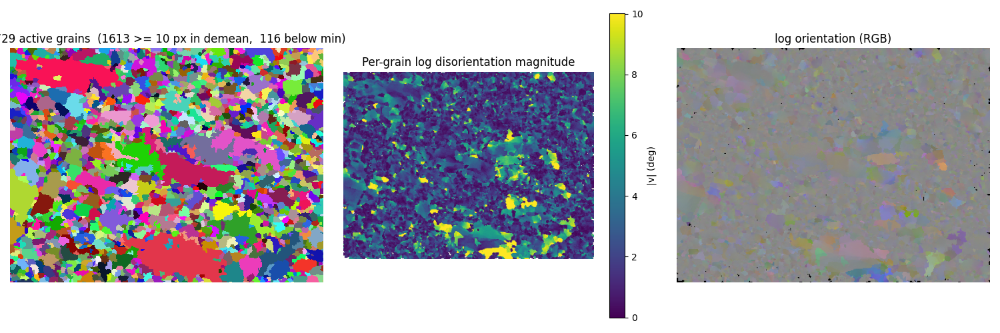

Grains flagged near FZ boundary: 0/1613


In [142]:
# ===== Visualize grains and per-grain log-orientation field =====
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Grain map (distinct colors, background dark)
rng = np.random.default_rng(0)
colors = np.vstack([[0.1, 0.1, 0.1], rng.random((grain_id.max() + 1, 3))])
gmap = colors[grain_id]
ax = axes[0]
ax.imshow(gmap, interpolation='nearest')
_active_sizes = np.bincount(grain_id.ravel())
_n_active = int((_active_sizes[1:] > 0).sum())
_n_in_demean = len(grain_info)
_n_below_min = int(((_active_sizes[1:] > 0) & (_active_sizes[1:] < GRAIN_MIN_PIXELS)).sum())
ax.set_title(f'{_n_active} active grains  '
              f'({_n_in_demean} >= {GRAIN_MIN_PIXELS} px in demean,  '
              f'{_n_below_min} below min)')
ax.axis('off')

# (b) Log-orientation magnitude
mag = np.linalg.norm(combined_log, axis=2)
mag[~combined_mask] = np.nan
ax = axes[1]
im = ax.imshow(np.rad2deg(mag), cmap='viridis', vmin=0, vmax=np.nanpercentile(np.rad2deg(mag), 98))
plt.colorbar(im, ax=ax, label='|v| (deg)')
ax.set_title('Per-grain log disorientation magnitude')
ax.axis('off')

# (c) RGB coding of log vector direction
lv = combined_log.copy()
lv -= lv.min()
lv /= (lv.max() + 1e-9)
lv[~combined_mask] = 0
ax = axes[2]
ax.imshow(lv)
ax.set_title('log orientation (RGB)')
ax.axis('off')

plt.tight_layout()
plt.show()

# FZ-boundary-warning grains
n_warn = sum(1 for g in grain_info.values() if g['fz_warn'])
print(f'Grains flagged near FZ boundary: {n_warn}/{len(grain_info)}')


## Optional grain-boundary mask (fallback for global reference)

In [17]:
# ===== Grain-boundary mask (OPTIONAL — for per-phase / global-reference fallback) =====
# With per-grain demean, v(x) is continuous across GBs by construction, so this is
# not strictly needed.  Kept as a fallback when running with a global reference, or
# to compare spectra with/without boundary contributions.

# ---- options ----
USE_GB_MASK = False               # False = no GB filter (per-grain demean regime)
GB_THETA_DEG = GRAIN_THETA_DEG    # reuse grain threshold
GB_CHAIN_FRAC = 0.5               # drop chains with >= this fraction of pixels inside GB mask
# -----------------

from scipy.ndimage import binary_dilation

def build_gb_mask(grain_id):
    """Binary mask of GB pixels: pixels where at least one 4-neighbor has a different grain id (or 0)."""
    gid = grain_id
    ny, nx = gid.shape
    m = np.zeros((ny, nx), dtype=bool)
    # Right / down neighbor mismatch
    m[:, :-1] |= (gid[:, :-1] != gid[:, 1:])
    m[:,  1:] |= (gid[:, :-1] != gid[:, 1:])
    m[:-1, :] |= (gid[:-1, :] != gid[1:, :])
    m[ 1:, :] |= (gid[:-1, :] != gid[1:, :])
    return m

def gb_mask_at_scale(base_mask, scale_px):
    """Dilate base GB mask by wavelet support at given scale."""
    r = max(1, int(np.ceil(scale_px)))
    return binary_dilation(base_mask, iterations=r)

if USE_GB_MASK:
    gb_base = build_gb_mask(grain_id)
    print(f'GB base mask: {gb_base.sum()} pixels ({100.0*gb_base.sum()/gb_base.size:.1f}%)')
else:
    gb_base = None
    print('GB chain filter disabled (per-grain demean makes v continuous across GBs).')


GB chain filter disabled (per-grain demean makes v continuous across GBs).


## Distance-to-grain-boundary scalar field
Continuous map (in µm) of each interior pixel's distance to the nearest grain boundary, via `scipy.ndimage.distance_transform_edt` on the inverted GB mask from cell 18. Useful for (a) Hall–Petch / pile-up profile interpretation, (b) gradient-plasticity GND-near-GB tests, and (c) multifractal stratification (`near GB` vs `interior` sub-spectra of the dislocation field). Optionally registered as a WTMM input mode `dist_to_gb` in the next cell so all downstream PF / cumulant / spectrum / entropy cells pick it up automatically.

dist_to_gb support: 1075907/1146699 pixels
  median:        7.78 um
  95th pct:      47.24 um
  max:           113.06 um
  median grain effective radius: 5.00 um (dist_to_gb max should be of this order)


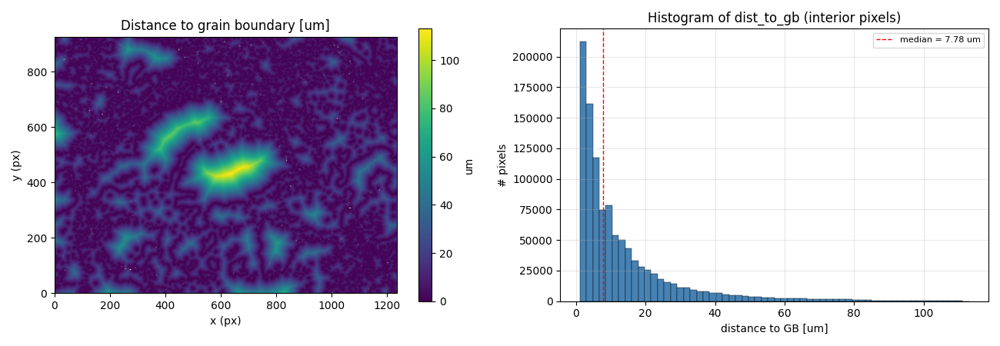

In [18]:
# ===== Distance-to-grain-boundary scalar field =====
# Continuous distance transform from each pixel to the nearest GB pixel, in um.
# Reuses build_gb_mask from cell 18 (was conditionally used; we always need it
# here regardless of USE_GB_MASK).

from scipy.ndimage import distance_transform_edt

# Resolve px_um locally so this cell can run right after cell 18,
# before cell 22 (tensor WTMM) defines `px_um` globally.
if 'px_um' not in globals():
    _meta = ebsd.get('meta', {}) if isinstance(ebsd, dict) else {}
    px_um = float(_meta.get('xstep', 1.0))

# Build the GB pixel set, restricted to boundaries between LARGE grains only
# (size >= GRAIN_MIN_PIXELS). This rejects Voronoi seams introduced by the
# cell-10 smart fill when between-grain small clusters were split, plus any
# tiny edge-protected truncations -- both manifest as scattered dead pixels
# in dist_to_gb otherwise.
DGB_LARGE_ONLY = True   # set False to use raw build_gb_mask(grain_id)

def _dgb_build_gb_mask_large_only(gid, min_size, was_filled=None):
    sizes = np.bincount(gid.ravel())
    is_large = (gid > 0) & (sizes[gid] >= min_size)
    if was_filled is not None:
        # Exclude Voronoi-seam boundaries: a pixel's grain_id only counts
        # toward the GB if the pixel was ORIGINALLY indexed (not filled).
        is_large = is_large & ~was_filled
    gb = np.zeros_like(gid, dtype=bool)
    rb = ((gid[:, :-1] != gid[:, 1:]) & is_large[:, :-1] & is_large[:, 1:])
    gb[:, :-1] |= rb; gb[:,  1:] |= rb
    db = ((gid[:-1, :] != gid[1:, :]) & is_large[:-1, :] & is_large[1:, :])
    gb[:-1, :] |= db; gb[ 1:, :] |= db
    return gb

if DGB_LARGE_ONLY:
    _dgb_was_filled = globals().get('was_filled')   # set by cell 10's smart fill
    _dgb_gb_mask = _dgb_build_gb_mask_large_only(
        grain_id, GRAIN_MIN_PIXELS, was_filled=_dgb_was_filled)
else:
    _dgb_gb_mask = build_gb_mask(grain_id)
# Treat unindexed pixels (grain_id == 0) as "boundary" too, so the distance
# transform doesn't reach into the noise field.
_dgb_invalid = _dgb_gb_mask | (grain_id == 0)

# distance_transform_edt(mask) returns, for each True pixel, the Euclidean
# distance to the nearest False pixel. We want distance from each interior
# pixel to the nearest invalid (GB or unindexed) pixel.
dist_to_gb_px = distance_transform_edt(~_dgb_invalid)
dist_to_gb_um = dist_to_gb_px * px_um

# Stats
_valid = dist_to_gb_um[combined_mask & ~_dgb_invalid]
print(f'dist_to_gb support: {_valid.size}/{combined_mask.size} pixels')
if _valid.size:
    print(f'  median:        {np.median(_valid):.2f} um')
    print(f'  95th pct:      {np.percentile(_valid, 95):.2f} um')
    print(f'  max:           {_valid.max():.2f} um')
    # Compare to per-grain effective radius
    sizes_px = np.bincount(grain_id.ravel())[1:]
    sizes_px = sizes_px[sizes_px >= GRAIN_MIN_PIXELS]
    if len(sizes_px):
        med_radius_um = float(np.sqrt(np.median(sizes_px) * px_um**2 / np.pi))
        print(f'  median grain effective radius: {med_radius_um:.2f} um '
              f'(dist_to_gb max should be of this order)')

# ---- Visualize ----
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
_disp = np.where(combined_mask, dist_to_gb_um, np.nan)
im = ax.imshow(_disp, cmap='viridis', origin='lower')
ax.set(title='Distance to grain boundary [um]', xlabel='x (px)', ylabel='y (px)')
plt.colorbar(im, ax=ax, label='um')

ax = axes[1]
if _valid.size:
    ax.hist(_valid, bins=60, color='steelblue', edgecolor='k', linewidth=0.3)
    ax.axvline(np.median(_valid), color='r', ls='--', lw=1, label=f'median = {np.median(_valid):.2f} um')
    ax.legend(fontsize=8)
ax.set(xlabel='distance to GB [um]', ylabel='# pixels',
       title='Histogram of dist_to_gb (interior pixels)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Tensor WTMM on per-grain log field

In [19]:
# ===== Pantleon-faithful tensor WTMM on per-grain-demeaned log field =====
# Per Pantleon 2008 (Eqs. 11 & 13): curvature kappa_ij = d g_i / d x_j at each
# wavelet scale maps to the 5 accessible Nye alpha components + (a11 - a22).
# Tensor WTMM = SVD of the 6x2 spatial Jacobian of the alpha-vector field.

from xsmurf_wrapper.anchor_chain import chain_and_extract
import xsmurf_wrapper as xsm

# ---- parameters ----
FRACINT_ALPHA       = 1
PAD                 = 32
WTMM_METHOD         = 'nms'
FOLLOW_VERSION      = 'v1'
WAVELET             = 'gaussian'
CHAIN_METHOD        = 'greedy'
THRESH              = 1e-2
A_MIN               = 1.832
N_OCT               = 4
N_VOX               = 11
SIMILITUDE          = 0.8
BORDER_PCT          = 1.0
DIST_FRAC           = 0.1
SMOOTH_CHAIN        = True   # chain spatial smoothing during chain_and_extract
# --- alpha-Jacobian computation mode ---
USE_WAVELET_HESSIAN = True    # True: cwt derivs='all' + Pantleon-linear alpha Jacobian
                              # False: np.gradient on alpha_cwt (original behavior)
WAVELET_HESSIAN     = 'gaussian'  # pure 2nd partials need gaussian; ignored if
                                  # USE_WAVELET_HESSIAN=False.  See proof PDF
                                  # `nye_spectrum_proof.pdf` for scaling discussion.
# --------------------

scales = compute_scales(n_oct=N_OCT, n_vox=N_VOX, a_min=A_MIN)
n_sc = len(scales)
ny, nx = combined_log.shape[:2]
px_um = ebsd.get('meta', {}).get('xstep', 1.0)

# CWT first derivatives of g -> kappa_ij(a) at each scale
work_field = combined_log
print('CWT (3 rotation components) -> kappa_ij(a)...')
derivs = [cwt_2d_f32(work_field[..., c], scales, pad=PAD, derivs='first',
                     wavelet=WAVELET, verbose=False) for c in range(3)]

# Optional second CWT pass: pure wavelet Hessian of g (needed for alpha-Jacobian
# when USE_WAVELET_HESSIAN=True).  Uses wavelet='gaussian' because mexican+all
# gives higher-order isotropic combinations, not pure dxx/dxy/dyy.
if USE_WAVELET_HESSIAN:
    print(f'CWT (3 rotation components) -> wavelet Hessian (derivs=all, {WAVELET_HESSIAN})...')
    derivs_hess = [cwt_2d_f32(work_field[..., c], scales, pad=PAD, derivs='all',
                              wavelet=WAVELET_HESSIAN, verbose=False)
                   for c in range(3)]

if FRACINT_ALPHA != 0:
    print(f'Pseudo-fractional integration eta={FRACINT_ALPHA}...')
    for c in range(3):
        for si, scale in enumerate(scales):
            f = np.float32(scale ** FRACINT_ALPHA)
            derivs[c]['dx'][si] *= f
            derivs[c]['dy'][si] *= f
            if USE_WAVELET_HESSIAN:
                derivs_hess[c]['dxx'][si] *= f
                derivs_hess[c]['dxy'][si] *= f
                derivs_hess[c]['dyy'][si] *= f

# Nye alpha scalar fields at each scale (Pantleon Eqs. 11 & 13)
_ALPHA_KEYS = ['a12', 'a13', 'a21', 'a23', 'a33', 'a11_a22']
alpha_fields = {k: np.zeros((n_sc, ny, nx), dtype=np.float32) for k in _ALPHA_KEYS}

# Legacy kappa-SVD diagnostics + new alpha-TWTMM fields
svd_fields = {
    'sigma_max':       np.zeros((n_sc, ny, nx), dtype=np.float32),
    'sigma_min':       np.zeros((n_sc, ny, nx), dtype=np.float32),
    'modL':            np.zeros((n_sc, ny, nx), dtype=np.float32),
    'modT':            np.zeros((n_sc, ny, nx), dtype=np.float32),
    'arg':             np.zeros((n_sc, ny, nx), dtype=np.float32),
    'alpha_sigma_max': np.zeros((n_sc, ny, nx), dtype=np.float32),
    'alpha_sigma_min': np.zeros((n_sc, ny, nx), dtype=np.float32),
    'alpha_arg':       np.zeros((n_sc, ny, nx), dtype=np.float32),
}

print('Building alpha fields + 6x2 Jacobian SVD per scale (Pantleon 2008)...')
for si in range(n_sc):
    # kappa_ij = d g_i / d x_j  (accessible 6 components)
    k11 = derivs[0]['dx'][si]; k12 = derivs[0]['dy'][si]
    k21 = derivs[1]['dx'][si]; k22 = derivs[1]['dy'][si]
    k31 = derivs[2]['dx'][si]; k32 = derivs[2]['dy'][si]

    # Pantleon alpha components (zero elastic strain assumption)
    a12_v = k21
    a13_v = k31
    a21_v = k12
    a23_v = k32
    a33_v = -(k11 + k22)
    adf_v = k11 - k22            # = a11 - a22
    for key, arr in [('a12', a12_v), ('a13', a13_v), ('a21', a21_v),
                     ('a23', a23_v), ('a33', a33_v), ('a11_a22', adf_v)]:
        alpha_fields[key][si] = arr

    # Legacy kappa-SVD diagnostics (3x2 Jacobian of g)
    smax, smin, karg = tensor_svd_3x2(k11, k12, k21, k22, k31, k32)
    svd_fields['sigma_max'][si] = smax
    svd_fields['sigma_min'][si] = smin
    svd_fields['arg'][si]       = karg
    svd_fields['modL'][si] = np.sqrt(
        k11**2 + k22**2 + 0.25 * (k21 + k12) ** 2 + k31**2 + k32**2
    ).astype(np.float32)
    svd_fields['modT'][si] = (0.5 * np.abs(k21 - k12)).astype(np.float32)

    # Spatial gradient of each alpha component -> 6x2 Jacobian of the alpha field.
    # Two modes:
    #   USE_WAVELET_HESSIAN=True  -> exact Fourier via cwt_2d_f32(derivs='all') +
    #                                 Pantleon chain-rule linear combinations:
    #      d(alpha_12)/dx = d2g2/dx2 = g2_xx    d(alpha_12)/dy = g2_xy
    #      d(alpha_13)/dx = g3_xx                d(alpha_13)/dy = g3_xy
    #      d(alpha_21)/dx = g1_xy                d(alpha_21)/dy = g1_yy
    #      d(alpha_23)/dx = g3_xy                d(alpha_23)/dy = g3_yy
    #      d(alpha_33)/dx = -(g1_xx + g2_xy)     d(alpha_33)/dy = -(g1_xy + g2_yy)
    #      d(a11-a22)/dx  = g1_xx - g2_xy        d(a11-a22)/dy  = g1_xy - g2_yy
    #   USE_WAVELET_HESSIAN=False -> old behavior: pixel-level np.gradient(alpha).
    A_sum = np.zeros_like(a12_v); B_sum = np.zeros_like(a12_v); C_sum = np.zeros_like(a12_v)
    if USE_WAVELET_HESSIAN:
        g1_xx = derivs_hess[0]['dxx'][si]; g1_xy = derivs_hess[0]['dxy'][si]; g1_yy = derivs_hess[0]['dyy'][si]
        g2_xx = derivs_hess[1]['dxx'][si]; g2_xy = derivs_hess[1]['dxy'][si]; g2_yy = derivs_hess[1]['dyy'][si]
        g3_xx = derivs_hess[2]['dxx'][si]; g3_xy = derivs_hess[2]['dxy'][si]; g3_yy = derivs_hess[2]['dyy'][si]
        da_x_list = [g2_xx, g3_xx, g1_xy, g3_xy, -(g1_xx + g2_xy), (g1_xx - g2_xy)]
        da_y_list = [g2_xy, g3_xy, g1_yy, g3_yy, -(g1_xy + g2_yy), (g1_xy - g2_yy)]
        for da_x, da_y in zip(da_x_list, da_y_list):
            A_sum += (da_x * da_x).astype(np.float32)
            B_sum += (da_x * da_y).astype(np.float32)
            C_sum += (da_y * da_y).astype(np.float32)
    else:
        for arr in (a12_v, a13_v, a21_v, a23_v, a33_v, adf_v):
            da_x = np.gradient(arr, axis=1).astype(np.float32)
            da_y = np.gradient(arr, axis=0).astype(np.float32)
            A_sum += da_x * da_x
            B_sum += da_x * da_y
            C_sum += da_y * da_y

    # 2x2 eigendecomposition of J^T J (per pixel) for 6x2 J
    tr   = A_sum + C_sum
    df   = A_sum - C_sum
    disc = np.sqrt(df * df + 4.0 * B_sum * B_sum)
    lam_max = 0.5 * (tr + disc)
    lam_min = np.maximum(0.5 * (tr - disc), 0.0)
    svd_fields['alpha_sigma_max'][si] = np.sqrt(lam_max).astype(np.float32)
    svd_fields['alpha_sigma_min'][si] = np.sqrt(lam_min).astype(np.float32)
    svd_fields['alpha_arg'][si] = (0.5 * np.arctan2(2.0 * B_sum, df)).astype(np.float32)

# ---- Mode list ----
# Default: Pantleon-TWTMM modes (alpha_sigma_max / alpha_sigma_min).
# Append 'sigma_max','sigma_min','modL','modT' to also run legacy kappa-SVD modes.
SVD_MODES_RUN = ['alpha_sigma_max', 'alpha_sigma_min',
                 'sigma_max', 'sigma_min', 'modL', 'modT']
SVD_MODE_VIEW = 'alpha_sigma_max'

_ARG_FOR_MODE = {
    'sigma_max': 'arg', 'sigma_min': 'arg', 'modL': 'arg', 'modT': 'arg',
    'alpha_sigma_max': 'alpha_arg', 'alpha_sigma_min': 'alpha_arg',
}

svd_wtmm = {}
for mode in SVD_MODES_RUN:
    print(f'\n  WTMM on {mode}...')
    mod = svd_fields[mode]
    arg = svd_fields[_ARG_FOR_MODE[mode]]
    ext_images = []
    for si, scale in enumerate(scales):
        dx_r = (mod[si] * np.cos(arg[si])).astype(np.float32)
        dy_r = (mod[si] * np.sin(arg[si])).astype(np.float32)
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(dx_r),
            xsm.XImage.from_numpy(dy_r), scale, thresh=THRESH)
        ext_images.append(ext)

    chains = chain_and_extract(
        ext_images, scales, method=CHAIN_METHOD,
        a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
        similitude=SIMILITUDE, smooth=SMOOTH_CHAIN,
        border_percent=BORDER_PCT, dist_frac=DIST_FRAC)

    if USE_GB_MASK and gb_base is not None:
        n_pre = len(chains); kept = []
        scale_masks = {si: gb_mask_at_scale(gb_base, scales[si]) for si in range(n_sc)}
        for ch in chains:
            xs_ = np.asarray(ch['x'], dtype=int)
            ys_ = np.asarray(ch['y'], dtype=int)
            si_anchor = int(np.argmin(np.abs(np.log2(scales) - ch['log2_scales'][0])))
            m = scale_masks[si_anchor]
            xs_ = np.clip(xs_, 0, nx - 1); ys_ = np.clip(ys_, 0, ny - 1)
            frac = m[ys_, xs_].mean() if len(xs_) else 0.0
            if frac < GB_CHAIN_FRAC:
                kept.append(ch)
        chains = kept
        print(f'    GB chain filter: {n_pre} -> {len(chains)}')

    holders = xsm.compute_holder_exponents(chains)
    h_vals = [h['h'] for h in holders]
    chains_by_grain = {}
    for ch in chains:
        x0, y0 = int(ch['x'][0]), int(ch['y'][0])
        gid0 = int(grain_id[y0, x0]) if (0 <= y0 < ny and 0 <= x0 < nx) else 0
        chains_by_grain.setdefault(gid0, []).append(ch)

    svd_wtmm[mode] = {
        'chains': chains, 'holders': holders,
        'chains_by_grain': chains_by_grain, 'mod': mod,
        'ext_images': ext_images,
    }
    if h_vals:
        print(f'    {len(chains)} chains, h median = {np.median(h_vals):.3f}')

print('\nDone.')
print('USE_WAVELET_HESSIAN =', USE_WAVELET_HESSIAN)
if USE_WAVELET_HESSIAN:
    print('Reported h values are in the g-frame (h_g).  For Nye-tensor frame (h_alpha),')
    print('subtract 1 from reported h in downstream interpretation.  See proof PDF for details.')


CWT (3 rotation components) -> kappa_ij(a)...
CWT (3 rotation components) -> wavelet Hessian (derivs=all, gaussian)...
Pseudo-fractional integration eta=1...
Building alpha fields + 6x2 Jacobian SVD per scale (Pantleon 2008)...

  WTMM on alpha_sigma_max...
    9605 chains, h median = 0.703

  WTMM on alpha_sigma_min...
    12975 chains, h median = 0.731

  WTMM on sigma_max...
    5696 chains, h median = 0.715

  WTMM on sigma_min...
    8235 chains, h median = 0.737

  WTMM on modL...
    5331 chains, h median = 0.716

  WTMM on modT...
    5373 chains, h median = 0.406

Done.
USE_WAVELET_HESSIAN = True
Reported h values are in the g-frame (h_g).  For Nye-tensor frame (h_alpha),
subtract 1 from reported h in downstream interpretation.  See proof PDF for details.


### α-TWTMM rerun on shuffled field

Reuses the cell-18 parameters verbatim, so `_shuf` spectra are directly comparable
to the originals. Skipped if `RUN_SHUFFLE=False`. Each base κ/α SVD mode gets a
corresponding `_shuf` entry registered in `svd_wtmm` and appended to `SVD_MODES_RUN`.


In [15]:
# ===== Rerun α-TWTMM pipeline on shuffled field(s), register `_shuf` / `_shufall` modes =====
# Runs only for shuffles the previous cell built.  Uses the exact same cell-20
# parameters (FRACINT, USE_WAVELET_HESSIAN, WAVELET, THRESH, chain params) so
# spectra are directly comparable to the original.

def _rerun_alpha_twtmm_on(work_field, suffix):
    """Run the α-TWTMM pipeline on `work_field` and register fields / wtmm
    under `*_<suffix>` keys.  `suffix` should already contain its leading
    underscore (e.g. '_shuf', '_shufall')."""
    from xsmurf_wrapper.anchor_chain import chain_and_extract
    import xsmurf_wrapper as xsm

    _scales_sh = scales
    _n_sc_sh   = len(_scales_sh)
    _ny, _nx   = work_field.shape[:2]

    _derivs = [cwt_2d_f32(work_field[..., c], _scales_sh, pad=PAD,
                           derivs='first', wavelet=WAVELET, verbose=False)
                for c in range(3)]
    if USE_WAVELET_HESSIAN:
        _derivs_h = [cwt_2d_f32(work_field[..., c], _scales_sh, pad=PAD,
                                  derivs='all', wavelet=WAVELET_HESSIAN,
                                  verbose=False) for c in range(3)]
    if FRACINT_ALPHA != 0:
        for c in range(3):
            for si, sc in enumerate(_scales_sh):
                _f = np.float32(sc ** FRACINT_ALPHA)
                _derivs[c]['dx'][si] *= _f
                _derivs[c]['dy'][si] *= _f
                if USE_WAVELET_HESSIAN:
                    _derivs_h[c]['dxx'][si] *= _f
                    _derivs_h[c]['dxy'][si] *= _f
                    _derivs_h[c]['dyy'][si] *= _f

    _alpha_smax = np.zeros((_n_sc_sh, _ny, _nx), dtype=np.float32)
    _alpha_smin = np.zeros_like(_alpha_smax)
    _alpha_arg  = np.zeros_like(_alpha_smax)
    _sigma_max  = np.zeros_like(_alpha_smax)
    _sigma_min  = np.zeros_like(_alpha_smax)
    _karg       = np.zeros_like(_alpha_smax)
    _modL       = np.zeros_like(_alpha_smax)
    _modT       = np.zeros_like(_alpha_smax)

    for si in range(_n_sc_sh):
        k11 = _derivs[0]['dx'][si]; k12 = _derivs[0]['dy'][si]
        k21 = _derivs[1]['dx'][si]; k22 = _derivs[1]['dy'][si]
        k31 = _derivs[2]['dx'][si]; k32 = _derivs[2]['dy'][si]
        _smax_, _smin_, _karg_ = tensor_svd_3x2(k11, k12, k21, k22, k31, k32)
        _sigma_max[si] = _smax_; _sigma_min[si] = _smin_; _karg[si] = _karg_
        _modL[si] = np.sqrt(
            k11**2 + k22**2 + 0.25 * (k21 + k12) ** 2 + k31**2 + k32**2
        ).astype(np.float32)
        _modT[si] = (0.5 * np.abs(k21 - k12)).astype(np.float32)

        A = np.zeros_like(k11); B = np.zeros_like(k11); C = np.zeros_like(k11)
        if USE_WAVELET_HESSIAN:
            g1xx = _derivs_h[0]['dxx'][si]; g1xy = _derivs_h[0]['dxy'][si]; g1yy = _derivs_h[0]['dyy'][si]
            g2xx = _derivs_h[1]['dxx'][si]; g2xy = _derivs_h[1]['dxy'][si]; g2yy = _derivs_h[1]['dyy'][si]
            g3xx = _derivs_h[2]['dxx'][si]; g3xy = _derivs_h[2]['dxy'][si]; g3yy = _derivs_h[2]['dyy'][si]
            da_x = [g2xx, g3xx, g1xy, g3xy, -(g1xx + g2xy), (g1xx - g2xy)]
            da_y = [g2xy, g3xy, g1yy, g3yy, -(g1xy + g2yy), (g1xy - g2yy)]
        else:
            alphas = [k21, k31, k12, k32, -(k11 + k22), (k11 - k22)]
            da_x = [np.gradient(a, axis=1).astype(np.float32) for a in alphas]
            da_y = [np.gradient(a, axis=0).astype(np.float32) for a in alphas]
        for dx_, dy_ in zip(da_x, da_y):
            A += (dx_ * dx_).astype(np.float32)
            B += (dx_ * dy_).astype(np.float32)
            C += (dy_ * dy_).astype(np.float32)
        tr = A + C; df = A - C; disc = np.sqrt(df * df + 4.0 * B * B)
        lmax = np.maximum(0.5 * (tr + disc), 0.0)
        lmin = np.maximum(0.5 * (tr - disc), 0.0)
        _alpha_smax[si] = np.sqrt(lmax).astype(np.float32)
        _alpha_smin[si] = np.sqrt(lmin).astype(np.float32)
        _alpha_arg[si]  = (0.5 * np.arctan2(2.0 * B, df)).astype(np.float32)

    # register fields with suffix
    _fields = {
        f'alpha_sigma_max{suffix}': _alpha_smax,
        f'alpha_sigma_min{suffix}': _alpha_smin,
        f'alpha_arg{suffix}':       _alpha_arg,
        f'sigma_max{suffix}':       _sigma_max,
        f'sigma_min{suffix}':       _sigma_min,
        f'arg{suffix}':             _karg,
        f'modL{suffix}':            _modL,
        f'modT{suffix}':            _modT,
    }
    for _k, _v in _fields.items():
        svd_fields[_k] = _v
        if not _k.startswith(('alpha_arg', 'arg')) or _k not in (f'alpha_arg{suffix}',
                                                                   f'arg{suffix}'):
            _ARG_FOR_MODE[_k] = (f'alpha_arg{suffix}' if _k.startswith('alpha_')
                                  else f'arg{suffix}')

    _run_modes = [f'alpha_sigma_max{suffix}', f'alpha_sigma_min{suffix}',
                   f'sigma_max{suffix}',       f'sigma_min{suffix}',
                   f'modL{suffix}',            f'modT{suffix}']
    for _m in _run_modes:
        base = _m[:-len(suffix)] if suffix else _m
        if base not in SVD_MODES_RUN:
            continue   # only run suffixed modes for base modes that are enabled
        print(f'  WTMM on {_m}...')
        _mod = svd_fields[_m]; _arg = svd_fields[_ARG_FOR_MODE[_m]]
        _ext_images = []
        for si, sc in enumerate(_scales_sh):
            _dx = (_mod[si] * np.cos(_arg[si])).astype(np.float32)
            _dy = (_mod[si] * np.sin(_arg[si])).astype(np.float32)
            _ext, _, _ = xsm.wtmm2d(xsm.XImage.from_numpy(_dx),
                                     xsm.XImage.from_numpy(_dy), sc, thresh=THRESH)
            _ext_images.append(_ext)
        _chains = chain_and_extract(
            _ext_images, _scales_sh, method=CHAIN_METHOD,
            a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
            similitude=SIMILITUDE, smooth=SMOOTH_CHAIN,
            border_percent=BORDER_PCT, dist_frac=DIST_FRAC)
        if USE_GB_MASK and gb_base is not None:
            _scale_masks = {si: gb_mask_at_scale(gb_base, _scales_sh[si])
                            for si in range(_n_sc_sh)}
            _kept = []
            for _ch in _chains:
                _xs = np.clip(np.asarray(_ch['x'], dtype=int), 0, _nx - 1)
                _ys = np.clip(np.asarray(_ch['y'], dtype=int), 0, _ny - 1)
                _si0 = int(np.argmin(np.abs(np.log2(_scales_sh) - _ch['log2_scales'][0])))
                _frac = _scale_masks[_si0][_ys, _xs].mean() if len(_xs) else 0.0
                if _frac < GB_CHAIN_FRAC:
                    _kept.append(_ch)
            _chains = _kept
        _holders = xsm.compute_holder_exponents(_chains)
        _chains_by_grain = {}
        for _ch in _chains:
            _x0, _y0 = int(_ch['x'][0]), int(_ch['y'][0])
            _gid0 = int(grain_id[_y0, _x0]) if (0 <= _y0 < _ny and 0 <= _x0 < _nx) else 0
            _chains_by_grain.setdefault(_gid0, []).append(_ch)
        svd_wtmm[_m] = {'chains': _chains, 'holders': _holders,
                         'chains_by_grain': _chains_by_grain,
                         'mod': _mod, 'ext_images': _ext_images}
        if _holders:
            print(f'    {len(_chains)} chains')
        if _m not in SVD_MODES_RUN:
            SVD_MODES_RUN.append(_m)

if RUN_SHUFFLE and combined_log_shuf is not None:
    print('\n-- within-grain shuffled α-TWTMM --')
    _rerun_alpha_twtmm_on(combined_log_shuf, suffix='_shuf')
if RUN_SHUFFLE_ALL and combined_log_shufall is not None:
    print('\n-- globally shuffled α-TWTMM --')
    _rerun_alpha_twtmm_on(combined_log_shufall, suffix='_shufall')


NameError: name 'RUN_SHUFFLE' is not defined

## Slip-system GND resolution (Pantleon Eq. 19 via NNLS or LP)

Decomposes the pointwise Nye tensor $\alpha$ onto crystallographic slip systems
via `wtmm.slip_systems.resolve_gnd_per_pixel`.  Full slip tables: 72 systems for
quartz, 14 for olivine, 10 for feldspar.  Two solver options:

- `NNLS`: non-negative least squares (default, matches MTEX).
- `LP`: Pantleon 2008 minimum-line-energy linear programming.

Operates on the **pointwise** Nye tensor (pixel-level $\kappa = $np.gradient$(g)$,
no wavelet smoothing).  Outputs $\rho_t(x, y)$ per slip system.


Building pointwise kappa (pixel-level np.gradient of combined_log)...
  kappa shape: (927, 1237, 2, 3)   alpha shape: (927, 1237, 3, 3)
  phase map uniques: [1]
  _phases_meta type: dict, value: {1: ['4.91300010681152;4.91300010681152;5.50400018692017', '90;90;120', 'Quartz-new', '7', '152']}
  resolved names: [(1, 'Quartz')]
P7: Resolving Nye tensor (solver=lp, line_energy=character)...
  phase 1 (Quartz): 1146699 pixels, 96 systems, solver=lp, n_jobs=-1  (prep 0.6s, solve 154.3s)
  39 / 96 systems carry non-negligible density.
Dauphine-merge: 11 -> 7 families (positive/negative rhomb collapsed to total)
  rho units: m^-2  (px = 1.100 um);  median active-family rho = 5.200e+12 m^-2

  Per-family totals:
    (1, basal_a             ): total = 1.216e+19   max = 7.244e+14  [m^-2]
    (1, prism_a             ): total = 3.252e+18   max = 3.366e+14  [m^-2]
    (1, rhomb_a             ): total = 1.292e+19   max = 7.304e+14  [m^-2]
    (1, rhomb_ac            ): total = 1.677e+19   max = 9.22

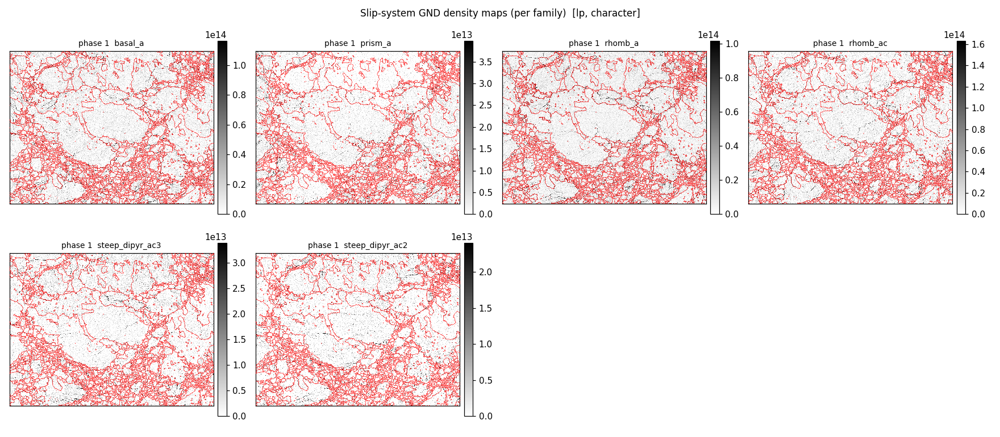

In [20]:
# ===== Slip-system GND resolution on the pointwise Nye tensor =====
# Uses wtmm.slip_systems.  Run AFTER cell 12 (demeaning) -- doesn't need the
# WTMM pipeline output; uses combined_log directly.
from wtmm.slip_systems import (SLIP_SYSTEMS_DB, BURGERS_MAGNITUDE_M,
                                resolve_gnd_per_pixel, aggregate_by_family)

# Convert dislocation density from raw [rad / pixel] (NNLS native units, since
# slip_systems.py uses unit Burgers vectors and np.gradient(spacing=1)) to
# literature-standard [m^-2] via:  rho_si = rho_raw / (px_size_m * |b|_m).
# Per-family |b| from BURGERS_MAGNITUDE_M (slip_systems.py).
UNIT_M_INV2 = True

# ---- solver configuration ----
GND_SOLVER       = 'lp'      # 'nnls' | 'lp'
GND_LINE_ENERGY  = 'character'   # 'uniform' | 'character' | 'anisotropic'
GND_POISSON      = 0.08

# ---- Build 2D-accessible Nye tensor from pointwise FD of combined_log ----
# kappa_ij = d g_i / d x_j ; accessible: i=1,2,3, j=1,2 (2D EBSD)
# Stored as nye_2x3[iy, ix, row, col] where row: (d/dx, d/dy), col: (g1, g2, g3).
# Pantleon Eq. 11 & 13 mapping is handled internally by resolve_gnd_per_pixel's
# Nye 1953 formula (alpha = sum_t b l rho).
print('Building pointwise kappa (pixel-level np.gradient of combined_log)...')
_ny, _nx = combined_log.shape[:2]
_kappa_2x3 = np.zeros((_ny, _nx, 2, 3), dtype=np.float64)
for _ci in range(3):
    _kappa_2x3[..., 0, _ci] = np.gradient(combined_log[..., _ci], axis=1)  # d/dx
    _kappa_2x3[..., 1, _ci] = np.gradient(combined_log[..., _ci], axis=0)  # d/dy

# Under zero-elastic-strain (Pantleon Eq. 6):  alpha_ik = kappa_ki - delta_ki kappa_mm
# resolve_gnd_per_pixel accepts the 2D-accessible Nye tensor directly.  For the
# "column" convention that lines up with Pantleon's Eq. 11 mapping, we need
# alpha (not kappa).  Build it:
_alpha_2x3 = np.zeros_like(_kappa_2x3)
# alpha rows (iy, ix, row, col) where row j in {1, 2} (i.e., spatial dir),
# col i in {1, 2, 3} (rotation component).  Using Pantleon's numeric identities:
#   alpha_12 = kappa_21,   alpha_13 = kappa_31,    alpha_21 = kappa_12,
#   alpha_23 = kappa_32,   alpha_33 = -(kappa_11 + kappa_22)
#   alpha_11 = -kappa_22 - kappa_33  (kappa_33 unmeasured -> approximate 0)
#   alpha_22 = -kappa_11 - kappa_33  (likewise)
# We rebuild the Nye tensor alpha_ij in the sample frame; unmeasured components
# are zeroed (kappa_i3 = 0 assumption from Pantleon 2008 Sec 3).
def _assemble_alpha_ij(kappa_2x3):
    """Given kappa[..., j(0,1), i(0,1,2)] = d g_i / d x_j (Pantleon indexing),
    return alpha[..., i, j] for i in {0,1,2}, j in {0,1,2} as (ny, nx, 3, 3).
    The third spatial column (j=2 i.e., d/dz) is zero."""
    ny, nx = kappa_2x3.shape[:2]
    # kappa[iy, ix, j(0=x, 1=y), i(0=g1, 1=g2, 2=g3)]
    k = kappa_2x3
    alpha = np.zeros((ny, nx, 3, 3), dtype=np.float64)
    # alpha_ik = kappa_ki - delta_ki * trace(kappa)  [trace from measured 2 rows]
    # measured kappa has only k_{j i} with j in {0,1}; k_{i3} assumed 0.
    # trace = kappa_11 + kappa_22 + kappa_33  -- with kappa_33 = 0 this is k[0,0] + k[1,1]
    # (indices: j=0 is x, i=0 is g1 --> k_{11} in Pantleon; j=1 is y, i=1 is g2 --> k_{22})
    trace = k[..., 0, 0] + k[..., 1, 1]   # kappa_11 + kappa_22
    # alpha[i, k] where i is "rotation index" (0..2) and k is "spatial index" (0..2)
    # Pantleon index convention: alpha_ij = kappa_ji - delta_ij trace(kappa)
    # (note the swap of indices).  We'll use alpha[i, k] such that
    # alpha[0, 0] = kappa[j=0, i=0] - trace ... actually simpler:
    # alpha_{i k} = kappa_{k i} - delta_{i k} trace_kappa
    # For our array k[j, i] where j=spatial, i=rotation, kappa_{k i}=k[k, i].
    for i_ in range(3):
        for kk in range(3):
            delta = 1.0 if i_ == kk else 0.0
            if kk < 2:   # measurable spatial index
                alpha[..., i_, kk] = k[..., kk, i_] - delta * trace
            else:
                # alpha_{i, 2}: kappa_{2, i} unmeasured (zero)
                alpha[..., i_, kk] = 0.0 - delta * trace
    return alpha

_alpha_3x3 = _assemble_alpha_ij(_kappa_2x3)
print(f'  kappa shape: {_kappa_2x3.shape}   alpha shape: {_alpha_3x3.shape}')

# ---- Phase lookup: for per-grain notebook we have a single primary phase ----
# Use phase map from the loaded ebsd dict if available, else fabricate single-phase.
if 'phase' in ebsd and ebsd['phase'] is not None:
    _phase_map = np.asarray(ebsd['phase'], dtype=int)
else:
    _phase_map = np.ones((_ny, _nx), dtype=int)
# Name lookup: from ebsd meta (if available) or hard-code
_phases_meta = ebsd.get('meta', {}).get('phases', None) if isinstance(ebsd, dict) else None

# Canonicalize phase names so the CTF header (e.g. 'Low albite', 'Quartz Alpha',
# 'Forsterite (Mg2SiO4)') matches the keys in SLIP_SYSTEMS_DB / BURGERS_MAGNITUDE_M.
_PHASE_NAME_ALIASES = {
    'low albite': 'Albite', 'high albite': 'Albite', 'albite': 'Albite',
    'oligoclase': 'Plagioclase', 'andesine': 'Plagioclase',
    'labradorite': 'Plagioclase', 'bytownite': 'Plagioclase',
    'anorthite': 'Anorthite',
    'orthoclase': 'Orthoclase', 'sanidine': 'Sanidine',
    'microcline': 'Microcline', 'k-feldspar': 'K-Feldspar',
    'k feldspar': 'K-Feldspar', 'kspar': 'K-Feldspar',
    'quartz': 'Quartz', 'quartz low': 'Quartz', 'quartz alpha': 'Quartz',
    'quartz-alpha': 'Quartz', 'alpha-quartz': 'Quartz', 'alpha quartz': 'Quartz',
    'quartz-new': 'Quartz', 'low quartz': 'Quartz',
    'olivine': 'Forsterite', 'forsterite': 'Forsterite',
    'fayalite': 'Forsterite',
    'enstatite': 'Enstatite', 'orthopyroxene': 'Orthopyroxene',
    'biotite': 'Biotite', 'muscovite': 'Muscovite', 'phlogopite': 'Phlogopite',
    'chlorite': 'Chlorite', 'talc': 'Talc', 'sericite': 'Sericite',
    'paragonite': 'Paragonite', 'illite': 'Illite',
}
def _canonicalize_phase_name(raw):
    if not raw: return None
    s = str(raw).strip()
    # strip parenthetical formula suffix:  "Forsterite (Mg2SiO4)" -> "Forsterite"
    s = s.split('(', 1)[0].strip()
    s_lc = s.lower()
    if s_lc in _PHASE_NAME_ALIASES:
        return _PHASE_NAME_ALIASES[s_lc]
    # case-insensitive direct match against the DB keys
    for k in SLIP_SYSTEMS_DB.keys():
        if k.lower() == s_lc:
            return k
    return s   # last resort: pass through, solver will warn

def _phase_name_lookup(pid):
    pid = int(pid)
    if pid <= 0:
        return None  # not-indexed / background
    name = None
    if _phases_meta is not None:
        try:
            entry = (_phases_meta[pid - 1]
                     if isinstance(_phases_meta, (list, tuple))
                     else _phases_meta[pid])
            # Common shapes:
            #   dict with 'name'/'Name'/'phase_name'
            #   list/tuple from CTF header — name is element index 2
            #   plain string
            if hasattr(entry, 'get'):
                name = entry.get('name') or entry.get('phase_name') or entry.get('Name')
            elif isinstance(entry, (list, tuple)):
                # CTF-style: ['cell_lengths', 'cell_angles', 'phase_name', ...]
                if len(entry) > 2 and isinstance(entry[2], str):
                    name = entry[2]
                else:
                    # search for first string that looks like a phase name (not a triple of numbers)
                    for el in entry:
                        if isinstance(el, str) and ';' not in el and not el.startswith('['):
                            try: float(el); continue   # skip numeric-looking strings
                            except ValueError: pass
                            name = el; break
            elif isinstance(entry, str):
                name = entry
        except (IndexError, KeyError, AttributeError):
            pass
    return _canonicalize_phase_name(name)

# Debug: show what keys the meta entries actually have
print(f'  phase map uniques: {np.unique(_phase_map).tolist()}')
print(f'  _phases_meta type: {type(_phases_meta).__name__}, value: {_phases_meta!r}')
print(f'  resolved names: '
      f'{[(int(p), _phase_name_lookup(int(p))) for p in np.unique(_phase_map)]}')

# ---- Resolve ----
print(f'P7: Resolving Nye tensor (solver={GND_SOLVER}, line_energy={GND_LINE_ENERGY})...')
GND_N_JOBS = -1   # use all cores; set to 1 for serial / debugging
gnd_per_system, gnd_meta = resolve_gnd_per_pixel(
    _alpha_3x3,   # (ny, nx, 3, 3) -- full accessible Nye tensor (col 3 zero)
    ebsd['euler1'], ebsd['euler2'], ebsd['euler3'],
    _phase_map,
    phase_name_lookup=_phase_name_lookup,
    slip_db=SLIP_SYSTEMS_DB,
    solver=GND_SOLVER,
    line_energy=GND_LINE_ENERGY,
    poisson_ratio=GND_POISSON,
    progress=True,
    n_jobs=GND_N_JOBS,
)

# ---- Active/inactive summary ----
n_active = sum(1 for (pid, sn), rho in gnd_per_system.items() if rho.max() > 1e-10)
n_total = len(gnd_per_system)
print(f'  {n_active} / {n_total} systems carry non-negligible density.')

# ---- Aggregate by family ----
gnd_per_family = aggregate_by_family(gnd_per_system, slip_db=SLIP_SYSTEMS_DB,
                                     phase_name_lookup=_phase_name_lookup,
                                     meta=gnd_meta)

# ---- Dauphine-merge: sum {pos,neg} rhomb / steep_dipyr family pairs ----
# Slip family labels 'rhomb_pos_*' and 'rhomb_neg_*' are NOT Dauphine-invariant:
# the per-pixel Pantleon resolver correctly assigns slip into each pixel's local
# crystal frame, but a Dauphine-twin pair has its +r/-r labels swapped (the
# crystallographic +r pole points in opposite physical directions in the two
# twins). For multifractal of per-family density maps this introduces spurious
# discontinuities at twin boundaries. Sum the pairs into a Dauphine-invariant
# total. Disable if you specifically need to study positive vs negative rhomb
# asymmetry (then you must also handle twin labelling explicitly).
DAUPHINE_MERGE_RHOMB = True

def _merge_dauphine_pairs(per_family):
    pairs = [('rhomb_pos_a', 'rhomb_neg_a', 'rhomb_a'),
             ('rhomb_pos_ac', 'rhomb_neg_ac', 'rhomb_ac')]
    # Steep dipyramid families come with a {pos,neg} x {ac1, ac2, ac3} grid;
    # discover them dynamically.
    keys = {fam for (_pid, fam) in per_family.keys()}
    for fam in list(keys):
        if fam.startswith('steep_dipyr_pos_'):
            tag = fam[len('steep_dipyr_pos_'):]
            neg_fam = f'steep_dipyr_neg_{tag}'
            if neg_fam in keys:
                pairs.append((fam, neg_fam, f'steep_dipyr_{tag}'))
    out = {}
    consumed = set()
    for (pid, fam), rho in per_family.items():
        out[(pid, fam)] = rho
    for pos, neg, total in pairs:
        for (pid, fam), rho in list(out.items()):
            if fam == pos and (pid, neg) in out:
                out[(pid, total)] = rho + out[(pid, neg)]
                consumed.add((pid, pos))
                consumed.add((pid, neg))
    for k in consumed:
        out.pop(k, None)
    return out

if DAUPHINE_MERGE_RHOMB:
    n_before = len(gnd_per_family)
    gnd_per_family = _merge_dauphine_pairs(gnd_per_family)
    print(f'Dauphine-merge: {n_before} -> {len(gnd_per_family)} families '
          f'(positive/negative rhomb collapsed to total)')

# ---- Convert raw rho [rad/pixel] -> [m^-2] using per-family Burgers magnitude.
# Skip families with no Burgers entry (warn once) so unknown phases don't crash.
if UNIT_M_INV2:
    px_m = float(px_um) * 1e-6
    _missing_b = set()

    # gnd_per_family: keys are family names (basal_a, prism_a, ...) -- direct lookup.
    for key in list(gnd_per_family.keys()):
        pid, fam = key
        phase_nm = _phase_name_lookup(int(pid))
        phase_bmag = BURGERS_MAGNITUDE_M.get(phase_nm)
        if phase_bmag is None:
            _missing_b.add((phase_nm, '*')); continue
        b_mag = phase_bmag.get(fam)
        if b_mag is None:
            _missing_b.add((phase_nm, fam)); continue
        gnd_per_family[key] = gnd_per_family[key] / (px_m * b_mag)

    # gnd_per_system: keys are slip-system names ('(0001)[100] edge', ...).
    # Reverse-lookup the family from SLIP_SYSTEMS_DB[phase_nm] and use its
    # Burgers magnitude.  Without this reverse lookup, the conversion is
    # silently skipped (BURGERS_MAGNITUDE_M is keyed by family name only) and
    # gnd_per_system stays in raw [rad/pixel] -- which propagates to
    # rho_tot = Sum gnd_per_system in cell 39 and gives gnd_total a value
    # ~1e15x too small.
    def _family_for_system(phase_nm, sys_name):
        if phase_nm not in SLIP_SYSTEMS_DB:
            return None
        for ss in SLIP_SYSTEMS_DB[phase_nm]:
            if ss['name'] == sys_name:
                return ss.get('family')
        return None

    for key in list(gnd_per_system.keys()):
        pid, sys_name = key
        phase_nm = _phase_name_lookup(int(pid))
        phase_bmag = BURGERS_MAGNITUDE_M.get(phase_nm)
        if phase_bmag is None:
            _missing_b.add((phase_nm, '*')); continue
        fam = _family_for_system(phase_nm, sys_name)
        if fam is None:
            _missing_b.add((phase_nm, f'{sys_name} (family unknown)')); continue
        b_mag = phase_bmag.get(fam)
        if b_mag is None:
            _missing_b.add((phase_nm, fam)); continue
        gnd_per_system[key] = gnd_per_system[key] / (px_m * b_mag)

    if _missing_b:
        print(f'  WARNING: missing Burgers magnitudes for {sorted(_missing_b)} '
              f'-- those entries left in raw [rad/pixel].')

    # Cross-check: Sum gnd_per_system must equal Sum gnd_per_family in m^-2.
    # If they diverge by >1% relative, the unit pipeline failed silently
    # somewhere.
    _sum_sys = sum(float(v.sum()) for v in gnd_per_system.values())
    _sum_fam = sum(float(v.sum()) for v in gnd_per_family.values())
    _ref     = max(abs(_sum_sys), abs(_sum_fam), 1e-30)
    if abs(_sum_sys - _sum_fam) / _ref > 1e-2:
        print(f'  ERROR: Sum(gnd_per_system) = {_sum_sys:.3e} != '
              f'Sum(gnd_per_family) = {_sum_fam:.3e} (rel diff '
              f'{abs(_sum_sys - _sum_fam) / _ref * 100:.2f}%).  '
              f'Unit conversion is inconsistent between dicts.')
    # Sanity: median active-family rho should land in [1e10, 1e17] m^-2 for
    # typical deformed crystals.
    _fam_meds = []
    for (pid, fam), rho in gnd_per_family.items():
        m = float(np.median(rho[rho > 0])) if (rho > 0).any() else 0.0
        if m > 0:
            _fam_meds.append((pid, fam, m))
    if _fam_meds:
        med_overall = float(np.median([m for _, _, m in _fam_meds]))
        out_of_range = not (1e10 <= med_overall <= 1e17)
        flag = '  [WARN: outside 1e10-1e17 m^-2 -- check unit pipeline]' if out_of_range else ''
        print(f'  rho units: m^-2  (px = {px_m*1e6:.3f} um);  '
              f'median active-family rho = {med_overall:.3e} m^-2{flag}')

print(f'\n  Per-family totals:')
_unit_label = 'm^-2' if UNIT_M_INV2 else 'rad/pixel'
for (pid, fam), rho in sorted(gnd_per_family.items()):
    tot = float(rho.sum())
    if tot > 1e-10:
        print(f'    ({pid}, {fam:20s}): total = {tot:.3e}   max = {rho.max():.3e}  [{_unit_label}]')

# ---- Visualize family-level density maps with interactive GB overlay ----
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import ipywidgets as widgets
from scipy.ndimage import binary_dilation

_fam_maps = [(k, v) for k, v in gnd_per_family.items() if v.max() > 1e-10]
if _fam_maps:
    # Base GB mask -- 4-connected mismatch on grain_id (reuses cell-18 helper)
    _gb_base_for_fam = build_gb_mask(grain_id)

    def _gb_overlay_rgba(base_mask, thickness_px, color_name, alpha):
        if thickness_px > 0:
            mask = binary_dilation(base_mask, iterations=int(thickness_px))
        else:
            mask = base_mask
        rgba = np.zeros(mask.shape + (4,), dtype=np.float32)
        r, g, b = mcolors.to_rgb(color_name)
        rgba[mask, 0] = r
        rgba[mask, 1] = g
        rgba[mask, 2] = b
        rgba[mask, 3] = alpha
        return rgba

    # Widgets
    gb_color_dd     = widgets.Dropdown(
        options=['red', 'magenta', 'yellow', 'lime', 'cyan', 'orange',
                 'white', 'black'],
        value='red', description='GB color:',
        layout=widgets.Layout(width='180px'))
    gb_thickness_sl = widgets.IntSlider(
        value=1, min=0, max=5, step=1, description='Thickness:',
        continuous_update=False, layout=widgets.Layout(width='280px'))
    gb_alpha_sl     = widgets.FloatSlider(
        value=0.6, min=0.0, max=1.0, step=0.05, description='Alpha:',
        continuous_update=False, layout=widgets.Layout(width='280px'))
    gb_visible_cb   = widgets.Checkbox(value=True, description='Show GBs',
        layout=widgets.Layout(width='130px'))

    ncols = min(4, len(_fam_maps))
    nrows = (len(_fam_maps) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows),
                              squeeze=False, dpi=110)

    _gb_overlays = []  # list of imshow objects, one per panel
    for idx, ((pid, fam), rho) in enumerate(_fam_maps):
        ax = axes[idx // ncols, idx % ncols]
        rho_disp = np.where(combined_mask, rho, np.nan)
        vmax = (float(np.nanpercentile(rho_disp, 99))
                if np.any(np.isfinite(rho_disp)) else 1e-30)
        im = ax.imshow(rho_disp, cmap='gist_yarg', interpolation='nearest',
                        vmin=0, vmax=max(vmax, 1e-30),
                        origin='upper', aspect='equal')
        # GB overlay on top
        rgba0 = _gb_overlay_rgba(_gb_base_for_fam,
                                  gb_thickness_sl.value,
                                  gb_color_dd.value,
                                  gb_alpha_sl.value)
        ovl = ax.imshow(rgba0, origin='upper', aspect='equal',
                        interpolation='nearest', zorder=5)
        ovl.set_visible(gb_visible_cb.value)
        _gb_overlays.append(ovl)

        ax.set_title(f'phase {pid}  {fam}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    for idx in range(len(_fam_maps), nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)
    fig.suptitle(f'Slip-system GND density maps (per family)  '
                 f'[{GND_SOLVER}, {GND_LINE_ENERGY}]', fontsize=11)
    fig.tight_layout()

    def _refresh_gb_overlay(*_):
        if not gb_visible_cb.value:
            for ovl in _gb_overlays:
                ovl.set_visible(False)
        else:
            rgba = _gb_overlay_rgba(_gb_base_for_fam,
                                    gb_thickness_sl.value,
                                    gb_color_dd.value,
                                    gb_alpha_sl.value)
            for ovl in _gb_overlays:
                ovl.set_data(rgba)
                ovl.set_visible(True)
        fig.canvas.draw_idle()

    for _w in (gb_color_dd, gb_thickness_sl, gb_alpha_sl, gb_visible_cb):
        _w.observe(_refresh_gb_overlay, names='value')

    display(widgets.HBox([gb_visible_cb, gb_color_dd,
                          gb_thickness_sl, gb_alpha_sl]))
    plt.show()


## Bundle scalar fields for RQA

Collects all 2D scalar fields produced by the prepro pipeline into a single `rqa_fields` dict. Includes shuffled (`_shuf`, `_shufall`) companions for fields whose shuffle was built. The RP cells below auto-discover from this dict.


In [21]:
# ===== Bundle 2D scalar fields for recurrence analysis =====
import numpy as np

rqa_fields = {}

# 1. LP/NNLS-resolved total GND density -- summed over slip systems.
# Always rebuild from the current `gnd_per_system` so switching dataset
# (e.g. quartz -> feldspar) doesn't leave a stale `rho_tot` in globals.
if 'gnd_per_system' in globals() and gnd_per_system:
    _r = None
    for (_pid, _sn), _rho in gnd_per_system.items():
        _r = (_rho.astype(np.float32).copy() if _r is None
               else _r + _rho.astype(np.float32))
    rho_tot = _r        # overwrite any stale value from a prior dataset
    rqa_fields['gnd_total'] = rho_tot.astype(np.float32)
    print(f'  rho_tot rebuilt from {len(gnd_per_system)} (grain, slip-system) entries '
          f'across phases {sorted({_pid for (_pid, _) in gnd_per_system.keys()})}')
else:
    if 'rho_tot' in globals(): del rho_tot   # don't reuse stale
    print('  WARN: gnd_total not built (run cell 26 NNLS/LP first)')

# 2. Tensor WTMM SVD modes (finest scale = closest to raw per-pixel SVD)
for _name in ('alpha_sigma_max', 'alpha_sigma_min', 'sigma_max', 'sigma_min',
               'modL', 'modT'):
    if _name in svd_fields and svd_fields[_name].ndim == 3:
        rqa_fields[_name] = svd_fields[_name][0].astype(np.float32)
        # Shuffled companions
        for sfx in ('_shuf', '_shufall'):
            sn = _name + sfx
            if sn in svd_fields and svd_fields[sn].ndim == 3:
                rqa_fields[sn] = svd_fields[sn][0].astype(np.float32)

# 3. combined_log Euclidean norm (vector magnitude)
def _vec_norm(field_3d):
    if field_3d is None:
        return None
    return np.linalg.norm(field_3d, axis=-1).astype(np.float32)

rqa_fields['combined_log_norm'] = _vec_norm(combined_log)
if 'combined_log_shuf' in globals() and combined_log_shuf is not None:
    rqa_fields['combined_log_norm_shuf'] = _vec_norm(combined_log_shuf)
if 'combined_log_shufall' in globals() and combined_log_shufall is not None:
    rqa_fields['combined_log_norm_shufall'] = _vec_norm(combined_log_shufall)

# 4. kappa_frob: Frobenius norm of the orientation gradient tensor of combined_log
def _kappa_frob(field_3d):
    if field_3d is None:
        return None
    f2 = np.zeros(field_3d.shape[:-1], dtype=np.float64)
    for ci in range(field_3d.shape[-1]):
        f2 += np.gradient(field_3d[..., ci], axis=1) ** 2  # d/dx
        f2 += np.gradient(field_3d[..., ci], axis=0) ** 2  # d/dy
    return np.sqrt(f2).astype(np.float32)

rqa_fields['kappa_frob'] = _kappa_frob(combined_log)
if 'combined_log_shuf' in globals() and combined_log_shuf is not None:
    rqa_fields['kappa_frob_shuf'] = _kappa_frob(combined_log_shuf)
if 'combined_log_shufall' in globals() and combined_log_shufall is not None:
    rqa_fields['kappa_frob_shufall'] = _kappa_frob(combined_log_shufall)

# 5. alpha_frob: Frobenius norm of the Nye tensor.
# Direct from kappa = grad(combined_log), no NNLS. Cheap to compute for
# all three variants (original, _shuf, _shufall) since cell 26 only ran NNLS
# on the original.
def _alpha_frob_from_log(field_3d):
    if field_3d is None: return None
    ny, nx = field_3d.shape[:2]
    k = np.zeros((ny, nx, 2, 3), dtype=np.float64)
    for ci in range(field_3d.shape[-1]):
        k[..., 0, ci] = np.gradient(field_3d[..., ci], axis=1)
        k[..., 1, ci] = np.gradient(field_3d[..., ci], axis=0)
    # Pantleon Eq. 6 (kappa_i3 = 0 unmeasured).
    # alpha_ij = kappa_ji - delta_ij * trace(kappa_measured).
    trace = k[..., 0, 0] + k[..., 1, 1]
    alpha = np.zeros((ny, nx, 3, 3), dtype=np.float64)
    for i in range(3):
        for kk in range(2):  # kk=2 column unmeasured
            alpha[..., i, kk] = k[..., kk, i]
            if i == kk:
                alpha[..., i, kk] -= trace
    return np.sqrt((alpha ** 2).sum(axis=(-2, -1))).astype(np.float32)

rqa_fields['alpha_frob'] = _alpha_frob_from_log(combined_log)
if 'combined_log_shuf' in globals() and combined_log_shuf is not None:
    rqa_fields['alpha_frob_shuf'] = _alpha_frob_from_log(combined_log_shuf)
if 'combined_log_shufall' in globals() and combined_log_shufall is not None:
    rqa_fields['alpha_frob_shufall'] = _alpha_frob_from_log(combined_log_shufall)

# 6. Distance to grain boundary (geometry-only, no shuffle)
if 'dist_to_gb_um' in globals():
    rqa_fields['dist_to_gb_um'] = dist_to_gb_um.astype(np.float32)

# 7. KAM
if 'kam' in globals():
    rqa_fields['kam'] = kam.astype(np.float32)

# Print summary
print(f'Registered {len(rqa_fields)} scalar fields for RQA:')
for _name, _arr in rqa_fields.items():
    finite = _arr[np.isfinite(_arr)]
    rng = (float(finite.min()), float(finite.max())) if finite.size else (np.nan, np.nan)
    print(f'  {_name:30s}  shape={_arr.shape}  range=[{rng[0]:.3e}, {rng[1]:.3e}]')


  rho_tot rebuilt from 96 (grain, slip-system) entries across phases [1]
Registered 12 scalar fields for RQA:
  gnd_total                       shape=(927, 1237)  range=[0.000e+00, 1.133e+15]
  alpha_sigma_max                 shape=(927, 1237)  range=[1.732e-03, 1.218e+00]
  alpha_sigma_min                 shape=(927, 1237)  range=[3.105e-04, 7.389e-01]
  sigma_max                       shape=(927, 1237)  range=[1.151e-07, 1.539e+00]
  sigma_min                       shape=(927, 1237)  range=[0.000e+00, 6.216e-01]
  modL                            shape=(927, 1237)  range=[7.013e-08, 1.441e+00]
  modT                            shape=(927, 1237)  range=[4.366e-09, 5.442e-01]
  combined_log_norm               shape=(927, 1237)  range=[0.000e+00, 5.482e-01]
  kappa_frob                      shape=(927, 1237)  range=[0.000e+00, 3.921e-01]
  alpha_frob                      shape=(927, 1237)  range=[0.000e+00, 3.921e-01]
  dist_to_gb_um                   shape=(927, 1237)  range=[0.000e+00,

## Delay-embedding + Recurrence Plots (binary + multi-threshold)

Pick a field from `rqa_fields`, sample H/V transects, embed via Takens, compute RP. Multi-threshold (`rainbow`) mode bins by 10/20/30/40/50 % of d_max. RQA metrics (with Theiler corrector) overlaid on the RP panel.


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_8183/477709387.py:54: RuntimeWarning: invalid value encountered in multiply
  mi = float(np.nansum(np.where(p_ab > 0, p_ab * lr, 0.0)))


tau (H rows): mean=6.30, std=1.00  (V cols): mean=6.40, std=2.29


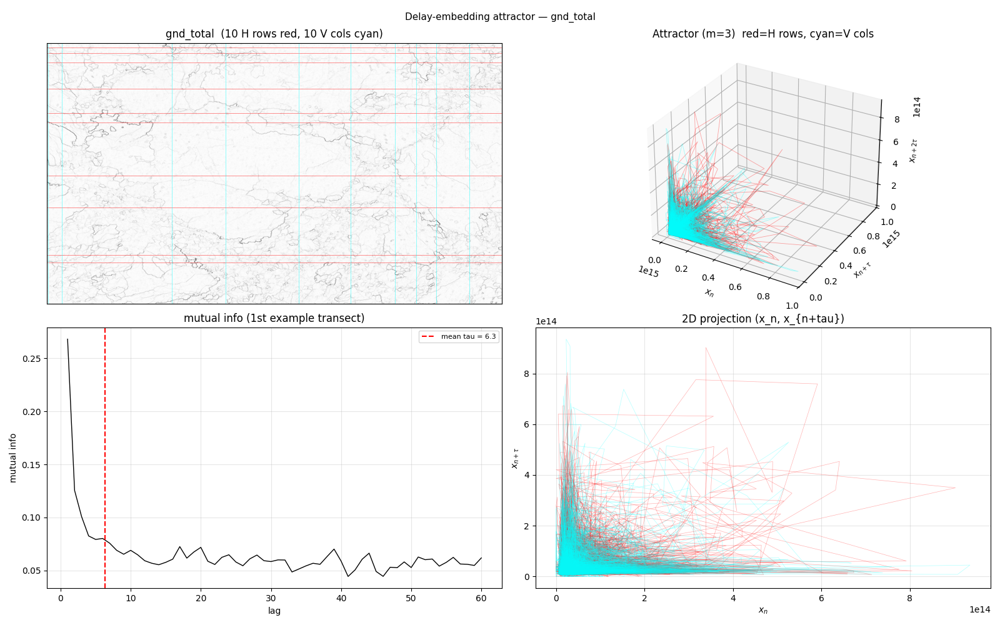

In [23]:
# ===== Takens delay-embedding attractor on random transects =====
# Auto-discovers 2D scalar fields, samples N random rows + N random cols,
# embeds each in m dimensions with delay tau, plots all attractors overlaid.

%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as widgets
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---- Auto-discover candidate 2D scalar fields in current globals ----
def _candidate_fields():
    g = globals()
    out = {}
    # Prefer the bundled rqa_fields dict (cell 28). Includes shuffles,
    # alpha_frob, kappa_frob, gnd_total, etc. -- everything in one place.
    rf = g.get('rqa_fields')
    if isinstance(rf, dict) and rf:
        for k, v in rf.items():
            if isinstance(v, np.ndarray) and v.ndim == 2:
                out[k] = v
        return out
    # Fallback: legacy auto-discovery (used only if rqa_fields not in scope)
    for name in ('dist_to_gb_um', 'rho_tot', 'kam_deg', 'kam'):
        v = g.get(name)
        if isinstance(v, np.ndarray) and v.ndim == 2:
            out[name] = v
    cl = g.get('combined_log')
    if isinstance(cl, np.ndarray) and cl.ndim == 3 and cl.shape[-1] == 3:
        out['|combined_log|'] = np.linalg.norm(cl, axis=-1)
    gpf = g.get('gnd_per_family')
    if isinstance(gpf, dict):
        for (pid, fam), arr in gpf.items():
            if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.max() > 0:
                out[f'gnd_{fam} (phase {pid})'] = arr
    return out

_fields = _candidate_fields()
if not _fields:
    print('No 2D scalar fields found. Run earlier cells (12, 20, 26) first.')
else:
    # ---- Helpers ----
    def _mi_curve(x, max_lag, bins=24):
        """Mutual information I(X_n ; X_{n+lag}) vs lag, histogram-based."""
        n = len(x)
        out = np.full(max_lag + 1, np.nan)
        for lag in range(1, min(max_lag + 1, n)):
            a = x[:-lag]; b = x[lag:]
            h_ab, _, _ = np.histogram2d(a, b, bins=bins)
            p_ab = h_ab / h_ab.sum() if h_ab.sum() > 0 else h_ab
            p_a  = p_ab.sum(axis=1)
            p_b  = p_ab.sum(axis=0)
            with np.errstate(divide='ignore', invalid='ignore'):
                lr = np.log(p_ab / np.outer(p_a, p_b))
            mi = float(np.nansum(np.where(p_ab > 0, p_ab * lr, 0.0)))
            out[lag] = mi
        return out

    def _mi_first_min(x, max_lag, bins=24):
        c = _mi_curve(x, max_lag, bins=bins)
        for i in range(1, len(c) - 1):
            if np.isfinite(c[i]) and np.isfinite(c[i+1]) and np.isfinite(c[i-1]):
                if c[i] < c[i-1] and c[i] < c[i+1]:
                    return i, c
        # fallback: argmin
        finite = np.isfinite(c)
        return int(np.nanargmin(c[finite])) + 1 if finite.any() else 1, c

    def _autocorr_first_zero(x, max_lag):
        x = x - x.mean()
        var = x.var()
        if var <= 0:
            return 1, np.array([np.nan] * (max_lag + 1))
        ac = np.array([1.0] + [float((x[:-k] * x[k:]).mean() / var)
                                for k in range(1, max_lag + 1)])
        for i in range(1, len(ac)):
            if ac[i] <= 0:
                return i, ac
        return max_lag, ac

    def _embed(x, tau, m):
        n = len(x) - (m - 1) * tau
        if n <= 0:
            return None
        return np.column_stack([x[i*tau : i*tau + n] for i in range(m)])

    def _fnn_curve(x, tau, max_m=12, R_tol=15.0, A_tol=2.0):
        """Kennel-Brown-Abarbanel 1992 false-nearest-neighbours fraction
        vs embedding dimension m, for m = 1..max_m.

        At each m we build the m-dim embedding y_i = (x_i, x_{i+tau}, ...,
        x_{i+(m-1)*tau}) for i in 0..n_check-1 (truncated so x_{i+m*tau}
        exists for the (m+1)-dim check), find each point's nearest neighbour
        in m-dim, then test:
            crit-R: |delta_next| / d_m > R_tol  (neighbour separates in m+1)
            crit-A: d_{m+1} / std(x) > A_tol    (absolute-noise guard)
        FNN fraction = fraction of points failing either criterion.
        Optimal m is the smallest m at which FNN drops to ~ 0 (~< 5 %).
        """
        from scipy.spatial import KDTree
        n = len(x)
        R_A = float(np.std(x))
        if R_A < 1e-12 or n < 50:
            return np.full(max_m, np.nan)
        fnn = np.full(max_m, np.nan)
        for m in range(1, max_m + 1):
            n_check = n - m * tau
            if n_check < 20:
                break
            Y = np.column_stack([x[k*tau : k*tau + n_check]
                                  for k in range(m)])
            try:
                tree = KDTree(Y)
                dists, idx = tree.query(Y, k=2)
            except (ValueError, MemoryError):
                break
            d_m = dists[:, 1]
            nn_idx = idx[:, 1]
            nxt = x[m*tau : m*tau + n_check]
            delta = nxt - nxt[nn_idx]
            d_m1  = np.sqrt(d_m * d_m + delta * delta)
            eps = 1e-12
            ok = d_m > eps
            cr1 = np.zeros_like(d_m, dtype=bool)
            cr1[ok] = np.abs(delta[ok]) / d_m[ok] > R_tol
            cr2 = d_m1 / R_A > A_tol
            fnn[m - 1] = float((cr1 | cr2).mean())
        return fnn

    # px_um in current scope (cell 22 sets it; fall back to ebsd meta)
    _px_um = globals().get('px_um')
    if _px_um is None:
        _meta = ebsd.get('meta', {}) if isinstance(ebsd, dict) else {}
        _px_um = float(_meta.get('xstep', 1.0))

    def _smooth(x, method, param, order=4, ripple_db=1.0):
        """Apply smoothing to a 1D transect before embedding / RP.

        method options:
          'none', 'gaussian', 'moving_avg', 'savgol' (existing real-space)
          'butterworth_lp', 'chebyshev1_lp', 'chebyshev2_lp' (zero-phase via
            scipy.signal.filtfilt; param = cutoff wavelength in PIXELS).

        param: sigma (gaussian) | window length (moving/savgol) | lowpass
               cutoff wavelength in pixels (butterworth/chebyshev1/2).
        order: filter order (butter/cheby only).
        ripple_db: passband ripple (cheby1) or stopband attenuation (cheby2).
        """
        if method == 'none' or param <= 0:
            return x
        if method == 'gaussian':
            from scipy.ndimage import gaussian_filter1d
            return gaussian_filter1d(x, sigma=float(param), mode='reflect')
        if method in ('moving_avg', 'savgol'):
            w = int(max(3, round(param)))
            if w % 2 == 0:
                w += 1
            if w >= len(x):
                return x
            if method == 'moving_avg':
                kern = np.ones(w) / w
                return np.convolve(x, kern, mode='same')
            from scipy.signal import savgol_filter
            return savgol_filter(x, window_length=w, polyorder=min(3, w - 1))
        # Frequency-domain lowpass via filtfilt (zero-phase, no group delay)
        if method in ('butterworth_lp', 'chebyshev1_lp', 'chebyshev2_lp'):
            from scipy.signal import butter, cheby1, cheby2, filtfilt
            lam_c = max(float(param), 2.5)            # avoid Nyquist
            Wn = min(2.0 / lam_c, 0.99)               # normalized to Nyquist=1
            if method == 'butterworth_lp':
                b, a = butter(int(order), Wn, btype='lowpass')
            elif method == 'chebyshev1_lp':
                b, a = cheby1(int(order), float(ripple_db), Wn, btype='lowpass')
            else:  # chebyshev2_lp
                b, a = cheby2(int(order), float(ripple_db), Wn, btype='lowpass')
            min_len = 3 * max(len(a), len(b))
            if len(x) < min_len + 1:
                return x  # series too short for filtfilt
            return filtfilt(b, a, x,
                            padlen=min(min_len, len(x) - 1))
        return x

    def _recurrence_matrix(emb, eps_pct=10.0, max_n=500):
        """Binary recurrence plot: R[i,j] = 1 iff ||y_i - y_j||_2 <= epsilon, else 0.
        epsilon = eps_pct percentile of all pairwise distances.
        Subsample to max_n points if longer (memory).
        Returns (R, eps_value, indices_used).
        """
        n = len(emb)
        if n > max_n:
            idx = np.linspace(0, n - 1, max_n).astype(int)
            y = emb[idx]
        else:
            idx = np.arange(n)
            y = emb
        diff = y[:, None, :] - y[None, :, :]
        dist = np.sqrt((diff ** 2).sum(axis=-1))
        eps = float(np.percentile(dist[dist > 0], eps_pct)) if (dist > 0).any() else 0.0
        R = (dist <= eps).astype(np.uint8)
        return R, eps, idx

    def _multi_threshold_recurrence(emb, dmax_pct=99.0, max_n=500):
        """5-tier recurrence plot stratified by 10/20/30/40/50 % of d_max.
        d_max = dmax_pct-th percentile of pairwise distances (default 99 -- robust
        to outlier pairs). Returns (label_image, dmax, indices_used) with
        L[i,j] in {0..5}: 0 = <=10 %, 1 = 10-20 %, 2 = 20-30 %, 3 = 30-40 %,
        4 = 40-50 %, 5 = above 50 % (white).
        """
        n = len(emb)
        if n > max_n:
            idx = np.linspace(0, n - 1, max_n).astype(int)
            y = emb[idx]
        else:
            idx = np.arange(n)
            y = emb
        diff = y[:, None, :] - y[None, :, :]
        dist = np.sqrt((diff ** 2).sum(axis=-1))
        nz = dist[dist > 0]
        dmax = float(np.percentile(nz, dmax_pct)) if nz.size else 1.0
        if dmax <= 0:
            dmax = 1.0
        thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]) * dmax
        L = np.full(dist.shape, 5, dtype=np.uint8)
        for k, th in enumerate(thresholds):
            mask = (dist <= th) & (L == 5)
            L[mask] = k
        return L, dmax, idx

    # ---- RQA helpers ----
    def _rqa_runs_of_ones(arr):
        a = np.asarray(arr, dtype=bool)
        if a.size == 0: return np.empty(0, dtype=int)
        pad = np.concatenate(([False], a, [False]))
        diff = np.diff(pad.astype(np.int8))
        starts = np.where(diff == 1)[0]
        ends   = np.where(diff == -1)[0]
        return ends - starts

    def _rqa_metrics(R, l_min=2, v_min=2, theiler=1):
        """Marwan-2007 RQA on a binary recurrence matrix R, with Theiler
        corrector. theiler: half-width of the line-of-identity exclusion band
        in pixels. Pairs (i,j) with |i-j| <= theiler are removed from all
        statistics. theiler=1 excludes only the LOI; raise to ~ embedding
        delay tau (or a few times the autocorrelation time) to suppress
        tangential-motion bias. For CRP/JRP between independent systems use
        theiler=0. Returns dict with RR, DET, L_avg, L_max, DIV, ENTR, LAM,
        TT, V_max, V_ENTR, TREND, N_rec, theiler."""
        R = np.asarray(R, dtype=bool).copy()
        N, M = R.shape
        if theiler > 0:
            ii, jj = np.indices((N, M))
            R &= (np.abs(ii - jj) > theiler)
        n_rec = int(R.sum())
        RR = float(n_rec) / max(N * M, 1)
        # Diagonals (Theiler-band offsets skipped because they're zeroed already,
        # but skipping the offsets themselves is also correct and slightly faster).
        diag_runs = []
        for offset in range(-(N - 1), M):
            if abs(offset) <= theiler: continue
            diag_runs.append(_rqa_runs_of_ones(R.diagonal(offset=offset)))
        d = np.concatenate(diag_runs) if diag_runs else np.empty(0, dtype=int)
        d_kept = d[d >= l_min]
        if d_kept.size:
            DET = float(d_kept.sum()) / max(n_rec, 1)
            L_avg = float(d_kept.mean()); L_max = int(d_kept.max())
            DIV = 1.0 / L_max if L_max > 0 else 0.0
            _, c = np.unique(d_kept, return_counts=True)
            p = c / c.sum()
            ENTR = float(-(p * np.log(p + 1e-30)).sum())
        else:
            DET = L_avg = DIV = ENTR = 0.0; L_max = 0
        vert_runs = []
        for col in range(M):
            vert_runs.append(_rqa_runs_of_ones(R[:, col]))
        v = np.concatenate(vert_runs) if vert_runs else np.empty(0, dtype=int)
        v_kept = v[v >= v_min]
        if v_kept.size:
            LAM = float(v_kept.sum()) / max(n_rec, 1)
            TT = float(v_kept.mean()); V_max = int(v_kept.max())
            _, c = np.unique(v_kept, return_counts=True)
            p = c / c.sum()
            V_ENTR = float(-(p * np.log(p + 1e-30)).sum())
        else:
            LAM = TT = V_ENTR = 0.0; V_max = 0
        # TREND: regression slope of RR(tau) along diagonals, EXCLUDING the
        # Theiler band (Marwan-2007 Eq. 5). Zero-padding the band, as a prior
        # version did, biases the slope toward zero.  Restrict tau to
        # [theiler+1, K] and run polyfit only over that range.  Many references
        # also cap tau at ~0.9*K to avoid finite-size edge effects on the
        # rightmost diagonals; we apply a conservative 90% cap.
        K = min(N, M) - 1
        tau_min = int(theiler) + 1
        tau_max = max(tau_min, int(0.9 * K))
        taus = np.arange(tau_min, tau_max + 1)
        if taus.size >= 5:
            rr_tau = np.array([R.diagonal(offset=int(t)).mean() for t in taus])
            if rr_tau.std() > 0:
                slope, _ = np.polyfit(taus, rr_tau, 1)
                TREND = float(slope * 1000.0)
            else: TREND = 0.0
        else: TREND = 0.0
        return {'RR': RR, 'DET': DET, 'L_avg': L_avg, 'L_max': L_max, 'DIV': DIV,
                'ENTR': ENTR, 'LAM': LAM, 'TT': TT, 'V_max': V_max,
                'V_ENTR': V_ENTR, 'TREND': TREND, 'N_rec': n_rec, 'theiler': int(theiler)}

    def _rqa_per_tier_table(L_label, n_tiers=5, theiler=1):
        rows = []
        tier_lbls = ['<=10%', '<=20%', '<=30%', '<=40%', '<=50%']
        for k in range(min(n_tiers, len(tier_lbls))):
            Rk = (L_label <= k)
            rows.append((tier_lbls[k], _rqa_metrics(Rk, theiler=theiler)))
        return rows

    def _rqa_format_table(rows, header='Tier'):
        cols = ['RR', 'DET', 'L_avg', 'L_max', 'DIV', 'ENTR',
                'LAM', 'TT', 'V_max', 'V_ENTR', 'TREND']
        out = [f'{header:<8s} ' + ' '.join(f'{c:>7s}' for c in cols)]
        for lbl, m in rows:
            vals = []
            for c in cols:
                v = m[c]
                if c in ('L_max', 'V_max'):
                    vals.append(f'{int(v):>7d}')
                else:
                    vals.append(f'{v:>7.3f}')
            out.append(f'{lbl:<8s} ' + ' '.join(vals))
        return '\n'.join(out)

    # ---- Widgets ----
    field_dd  = widgets.Dropdown(options=list(_fields.keys()),
                                  description='Field:',
                                  layout=widgets.Layout(width='320px'))
    nT_w      = widgets.IntSlider(value=10, min=1, max=30, step=1,
                                   description='# transects:',
                                   layout=widgets.Layout(width='280px'))
    seed_w    = widgets.IntText(value=0, description='Seed:',
                                 layout=widgets.Layout(width='150px'))
    tau_meth  = widgets.Dropdown(options=['mutual_info', 'autocorr_zero', 'manual'],
                                  value='mutual_info', description='tau:',
                                  layout=widgets.Layout(width='220px'))
    tau_man   = widgets.IntSlider(value=3, min=1, max=50, step=1,
                                   description='manual tau:',
                                   layout=widgets.Layout(width='260px'))
    m_w       = widgets.IntSlider(value=3, min=2, max=5, step=1,
                                   description='embed dim:',
                                   layout=widgets.Layout(width='240px'))
    show_2d   = widgets.Checkbox(value=True, description='Show (x_n, x_n+tau)',
                                  layout=widgets.Layout(width='220px'))
    fnn_show  = widgets.Checkbox(value=False, description='FNN(m) vs m',
                                  tooltip='Replace tau-curve panel with FNN '
                                          'fraction vs embedding dim (Kennel '
                                          'et al. 1992).',
                                  layout=widgets.Layout(width='180px'))
    fnn_max_m = widgets.IntSlider(value=10, min=2, max=20, step=1,
                                   description='FNN max m:',
                                   continuous_update=False,
                                   layout=widgets.Layout(width='240px'))
    smooth_dd = widgets.Dropdown(
        options=['none', 'gaussian', 'moving_avg', 'savgol',
                 'butterworth_lp', 'chebyshev1_lp', 'chebyshev2_lp'],
        value='none', description='Smoothing:',
        layout=widgets.Layout(width='240px'))
    smooth_p  = widgets.FloatSlider(value=2.0, min=0.0, max=80.0, step=0.5,
                                     description='param:',
                                     tooltip='sigma (gaussian) | window (moving/savgol) | '
                                             'cutoff wavelength in pixels (butter/cheby).',
                                     continuous_update=False,
                                     layout=widgets.Layout(width='280px'))
    smooth_ord = widgets.IntSlider(value=4, min=1, max=12, step=1,
                                    description='filt ord:',
                                    tooltip='Filter order (butter/cheby only).',
                                    continuous_update=False,
                                    layout=widgets.Layout(width='200px'))
    smooth_rip = widgets.FloatSlider(value=1.0, min=0.1, max=10.0, step=0.1,
                                      description='ripple [dB]:',
                                      tooltip='Passband ripple (cheby1) or stopband '
                                              'attenuation (cheby2).',
                                      readout_format='.1f',
                                      continuous_update=False,
                                      layout=widgets.Layout(width='240px'))
    rp_show   = widgets.Checkbox(value=False, description='Recurrence plot',
                                  layout=widgets.Layout(width='180px'))
    rp_eps    = widgets.FloatSlider(value=10.0, min=1.0, max=40.0, step=1.0,
                                     description='RP eps %:',
                                     continuous_update=False,
                                     layout=widgets.Layout(width='260px'))
    rp_idx    = widgets.IntSlider(value=0, min=0, max=20, step=1,
                                   description='RP transect:',
                                   continuous_update=False,
                                   layout=widgets.Layout(width='260px'))
    rp_multi  = widgets.Checkbox(value=False, description='Multi-threshold RP',
                                  tooltip='5-tier coloring at 10/20/30/40/50 % '
                                          'of d_max (overrides binary RP).',
                                  layout=widgets.Layout(width='220px'))
    rp_dmax_p = widgets.FloatSlider(value=99.0, min=80.0, max=100.0, step=1.0,
                                     description='d_max %ile:',
                                     continuous_update=False,
                                     layout=widgets.Layout(width='240px'))
    rp_max_n  = widgets.IntSlider(value=1500, min=200, max=4000, step=100,
                                   description='RP max_n:',
                                   tooltip='Cap on transect points before computing RP. '
                                           'Subsampling is uniform along the transect; '
                                           'no cap applied if transect length <= max_n.',
                                   continuous_update=False,
                                   layout=widgets.Layout(width='280px'))

    fig = plt.figure(figsize=(16, 10))
    ax_field   = fig.add_subplot(2, 2, 1)
    ax_attract = fig.add_subplot(2, 2, 2, projection='3d')
    ax_taucurve = fig.add_subplot(2, 2, 3)
    ax_proj    = fig.add_subplot(2, 2, 4)

    def _draw(*_):
        field_name = field_dd.value
        F = _fields[field_name]
        ny, nx = F.shape
        rng = np.random.default_rng(seed_w.value)
        nT = nT_w.value
        rows = rng.choice(ny, size=min(nT, ny), replace=False)
        cols = rng.choice(nx, size=min(nT, nx), replace=False)

        for ax in (ax_field, ax_attract, ax_taucurve, ax_proj):
            ax.cla()

        # Panel 1: field with transects overlaid
        Fdisp = F.copy()
        ax_field.imshow(Fdisp, cmap='gist_yarg', origin='upper', aspect='auto')
        for r in rows: ax_field.axhline(r, color='red',  alpha=0.5, lw=0.6)
        for c in cols: ax_field.axvline(c, color='cyan', alpha=0.5, lw=0.6)
        ax_field.set(title=f'{field_name}  ({nT} H rows red, {nT} V cols cyan)',
                      xticks=[], yticks=[])

        # Series + per-transect tau (carry index so we can label transects)
        H_series = [(F[r, :], 'H', int(r)) for r in rows]
        V_series = [(F[:, c], 'V', int(c)) for c in cols]
        all_series = H_series + V_series

        max_lag = max(5, min(60, min(F.shape) // 4))
        m = m_w.value
        taus = []
        attractors = []
        _fnn_inputs = []
        sample_curve = None  # (lags, mi/ac, label) for first valid series

        for ser, kind, idx_in_field in all_series:
            s = ser[np.isfinite(ser)]
            if len(s) < 30:
                continue
            s = _smooth(s, smooth_dd.value, smooth_p.value, order=smooth_ord.value, ripple_db=smooth_rip.value)
            if tau_meth.value == 'mutual_info':
                tau, c = _mi_first_min(s, max_lag)
                if sample_curve is None:
                    sample_curve = (np.arange(len(c)), c, 'mutual info')
            elif tau_meth.value == 'autocorr_zero':
                tau, c = _autocorr_first_zero(s, max_lag)
                if sample_curve is None:
                    sample_curve = (np.arange(len(c)), c, 'autocorrelation')
            else:
                tau = tau_man.value
            tau = max(1, int(tau))
            taus.append((kind, tau))
            _fnn_inputs.append((s, tau))
            emb = _embed(s, tau, m)
            if emb is None or len(emb) < 10:
                continue
            attractors.append((kind, idx_in_field, tau, emb))

        # Panel 2: 3D attractor overlay (or 2D if m==2)
        for kind, _idx_f, _tau_e, emb in attractors:
            col = 'red' if kind == 'H' else 'cyan'
            if emb.shape[1] >= 3:
                ax_attract.plot(emb[:, 0], emb[:, 1], emb[:, 2], '-',
                                 color=col, alpha=0.35, lw=0.6)
            else:
                ax_attract.plot(emb[:, 0], emb[:, 1], np.zeros(len(emb)),
                                 '-', color=col, alpha=0.35, lw=0.6)
        ax_attract.set_xlabel('$x_n$'); ax_attract.set_ylabel(r'$x_{n+\tau}$')
        if m >= 3:
            ax_attract.set_zlabel(r'$x_{n+2\tau}$')
        ax_attract.set_title(f'Attractor (m={m})  red=H rows, cyan=V cols')

        # Panel 3: FNN(m) vs m if toggled, otherwise tau-determining curve.
        if fnn_show.value and _fnn_inputs:
            max_m_fnn = int(fnn_max_m.value)
            F_curves = []
            for s_used, tau_used in _fnn_inputs:
                f = _fnn_curve(s_used, tau_used, max_m=max_m_fnn)
                if not np.all(np.isnan(f)):
                    F_curves.append(f)
            if F_curves:
                F_arr = np.vstack(F_curves)
                m_axis = np.arange(1, max_m_fnn + 1)
                mean_f = np.nanmean(F_arr, axis=0)
                std_f  = np.nanstd(F_arr, axis=0)
                ax_taucurve.plot(m_axis, mean_f, 'ko-', lw=1.2,
                                  label=f'mean over {len(F_curves)} transects')
                ax_taucurve.fill_between(m_axis, mean_f - std_f, mean_f + std_f,
                                          color='k', alpha=0.18,
                                          label='+/- 1 std')
                ax_taucurve.axhline(0.05, color='gray', ls=':', lw=0.8,
                                     label='5 % threshold')
                ax_taucurve.axvline(m_w.value, color='red', ls='--',
                                     label=f'current m = {m_w.value}')
                ax_taucurve.set(xlabel='embedding dimension m',
                                 ylabel='FNN fraction',
                                 title='False nearest neighbours (Kennel et al. 1992)',
                                 xticks=m_axis)
                ax_taucurve.set_ylim(-0.02, 1.02)
                ax_taucurve.grid(True, alpha=0.3)
                ax_taucurve.legend(fontsize=7)
            else:
                ax_taucurve.text(0.5, 0.5, 'FNN: no usable transects',
                                  ha='center', va='center',
                                  transform=ax_taucurve.transAxes,
                                  color='red')
                ax_taucurve.set_axis_off()
        elif sample_curve is not None:
            lags, vals, lbl = sample_curve
            ax_taucurve.plot(lags, vals, 'k-', lw=1)
            mean_tau = float(np.mean([t for _, t in taus])) if taus else float('nan')
            ax_taucurve.axvline(mean_tau, color='red', ls='--',
                                 label=f'mean tau = {mean_tau:.1f}')
            ax_taucurve.set(xlabel='lag', ylabel=lbl,
                             title=f'{lbl} (1st example transect)')
            ax_taucurve.grid(True, alpha=0.3); ax_taucurve.legend(fontsize=8)
        elif tau_meth.value == 'manual':
            ax_taucurve.text(0.5, 0.5, f'manual tau = {tau_man.value}',
                              ha='center', va='center',
                              transform=ax_taucurve.transAxes)
            ax_taucurve.set_axis_off()

        # Panel 4: recurrence plot (if toggled) or 2D projection
        if rp_show.value and attractors:
            rp_idx.max = max(0, len(attractors) - 1)
            ridx = min(rp_idx.value, rp_idx.max)
            kind, _idx_rp, _tau_rp, emb = attractors[ridx]
            if rp_multi.value:
                L, dmax_val, used_idx = _multi_threshold_recurrence(
                    emb, dmax_pct=rp_dmax_p.value, max_n=rp_max_n.value)
                from matplotlib.colors import ListedColormap, BoundaryNorm
                from matplotlib.patches import Patch
                _tier_colors = ['#e41a1c', '#ffd700', '#7fff00',
                                '#1f77b4', '#87ceeb', '#ffffff']
                _cmap = ListedColormap(_tier_colors)
                _norm = BoundaryNorm(np.arange(7) - 0.5, _cmap.N)
                _n_emb = emb.shape[0]
                _ext_um = float(_n_emb * _px_um)
                ax_proj.imshow(L, cmap=_cmap, norm=_norm,
                                interpolation='nearest', origin='lower',
                                aspect='equal',
                                extent=[0.0, _ext_um, 0.0, _ext_um])
                _labels = ['<=10%', '10-20%', '20-30%', '30-40%',
                           '40-50%', '>50%']
                _handles = [Patch(facecolor=_tier_colors[k], edgecolor='k',
                                   linewidth=0.3, label=_labels[k])
                            for k in range(6)]
                ax_proj.legend(handles=_handles, loc='upper right',
                                fontsize=6, framealpha=0.85, ncol=2)
                ax_proj.set(xlabel='i along transect [µm]',
                             ylabel='j along transect [µm]',
                             title=(f'Multi-threshold RP -- transect {ridx} '
                                    f'({kind}), $d_{{max}}$={dmax_val:.3g} '
                                    f'({rp_dmax_p.value:.0f}th pct), '
                                    f'span = {_ext_um:.1f} µm'))
                # Per-tier RQA + Theiler corrector (overlay table on RP panel)
                _rqa_rows = _rqa_per_tier_table(L, theiler=1)
                _rqa_txt = _rqa_format_table(_rqa_rows, header="Tier")
                ax_proj.text(0.02, 0.02, _rqa_txt,
                              transform=ax_proj.transAxes,
                              fontsize=6, family="monospace",
                              va="bottom", ha="left",
                              bbox=dict(facecolor="white", alpha=0.85,
                                        edgecolor="black", linewidth=0.3,
                                        pad=2))
                print(f"\nRQA per tier (transect {ridx}, {kind}):")
                print(_rqa_txt)
            else:
                R, eps_val, used_idx = _recurrence_matrix(
                    emb, eps_pct=rp_eps.value, max_n=rp_max_n.value)
                _n_emb = emb.shape[0]
                _ext_um = float(_n_emb * _px_um)
                ax_proj.imshow(R, cmap='Greys', interpolation='nearest',
                                origin='lower', aspect='equal',
                                extent=[0.0, _ext_um, 0.0, _ext_um])
                ax_proj.set(xlabel='i along transect [µm]',
                             ylabel='j along transect [µm]',
                             title=(f'Recurrence plot -- transect {ridx} ({kind}), '
                                    f'$\\epsilon$={eps_val:.3g} '
                                    f'({rp_eps.value:.0f}th pct), '
                                    f'span = {_ext_um:.1f} µm'))
                # Single-RP RQA + Theiler corrector (overlay on RP panel)
                _rqa_m = _rqa_metrics(R.astype(bool), theiler=1)
                _rqa_txt = _rqa_format_table([("RP", _rqa_m)], header="RP")
                ax_proj.text(0.02, 0.02, _rqa_txt,
                              transform=ax_proj.transAxes,
                              fontsize=6, family="monospace",
                              va="bottom", ha="left",
                              bbox=dict(facecolor="white", alpha=0.85,
                                        edgecolor="black", linewidth=0.3,
                                        pad=2))
                print(f"\nRQA (transect {ridx}, {kind}, eps={eps_val:.3g}):")
                print(_rqa_txt)
        elif show_2d.value:
            for kind, _idx_f, _tau_e, emb in attractors:
                col = 'red' if kind == 'H' else 'cyan'
                ax_proj.plot(emb[:, 0], emb[:, 1], '-',
                              color=col, alpha=0.3, lw=0.5)
            ax_proj.set_xlabel('$x_n$'); ax_proj.set_ylabel(r'$x_{n+\tau}$')
            ax_proj.set_title('2D projection (x_n, x_{n+tau})')
            ax_proj.grid(True, alpha=0.3)
        else:
            ax_proj.set_axis_off()

        # Summary
        if taus:
            tau_h = [t for k, t in taus if k == 'H']
            tau_v = [t for k, t in taus if k == 'V']
            print(f'tau (H rows): mean={np.mean(tau_h):.2f}, '
                  f'std={np.std(tau_h):.2f}  '
                  f'(V cols): mean={np.mean(tau_v):.2f}, '
                  f'std={np.std(tau_v):.2f}')

        # Stash for the joint/cross-RP cell to consume
        global _attractors_cache, _attractors_field, _attractors_meta
        _attractors_cache = list(attractors)
        _attractors_field = field_name
        _attractors_meta = {
            'smooth': (smooth_dd.value, smooth_p.value),
            'smooth_order': smooth_ord.value,
            'smooth_ripple': smooth_rip.value,
            'tau_method': tau_meth.value,
            'manual_tau': tau_man.value,
            'm': m_w.value,
            'rp_max_n': rp_max_n.value,
        }
        global _attractors_field_array
        _attractors_field_array = F

        fig.suptitle(f'Delay-embedding attractor — {field_name}', fontsize=11)
        fig.tight_layout(); fig.canvas.draw_idle()

    for w in (field_dd, nT_w, seed_w, tau_meth, tau_man, m_w, show_2d,
              smooth_dd, smooth_p, smooth_ord, smooth_rip,
              rp_show, rp_eps, rp_idx, rp_multi,
              rp_dmax_p, rp_max_n, fnn_show, fnn_max_m):
        w.observe(_draw, names='value')

    display(widgets.VBox([
        widgets.HBox([field_dd, nT_w, seed_w]),
        widgets.HBox([tau_meth, tau_man, m_w, show_2d, fnn_show, fnn_max_m]),
        widgets.HBox([smooth_dd, smooth_p, smooth_ord, smooth_rip]),
        widgets.HBox([rp_show, rp_eps, rp_idx]),
        widgets.HBox([rp_multi, rp_dmax_p, rp_max_n]),
    ]))
    _draw()


## Cross and Joint Recurrence Plots

CRQA and JRQA on transects from the cell above. Per-tier RQA tables shown in the right-hand metadata panel.



CRQA (binary, H780 vs H753):
RP            RR     DET   L_avg   L_max     DIV    ENTR     LAM      TT   V_max  V_ENTR   TREND
CRP        0.100   0.989   9.160     111   0.009   2.853   0.995  11.041     108   3.179  -0.006


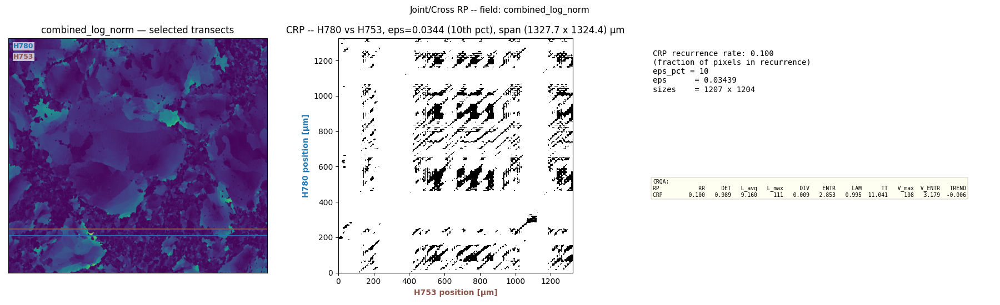

In [24]:
# ===== Joint and cross recurrence plots =====
# Consumes _attractors_cache from the delay-embedding cell above. Run that cell
# first; this one reuses its hyperparameters (field, smoothing, tau, m).

%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as widgets

if '_attractors_cache' not in globals() or not _attractors_cache:
    print('Run the delay-embedding cell first to populate _attractors_cache.')
else:
    # Pixel size for physical-unit axes
    _px_um = globals().get('px_um')
    if _px_um is None:
        _meta = ebsd.get('meta', {}) if isinstance(ebsd, dict) else {}
        _px_um = float(_meta.get('xstep', 1.0))
    _ATTR_LIST = _attractors_cache
    _FIELD_NM  = _attractors_field

    # ---- Local copies of cell-76 helpers so we can compute custom transects
    # without depending on cell-76 internals being in scope.
    def _l_smooth(x, method, param, order=4, ripple_db=1.0):
        if method == 'none' or param <= 0:
            return x
        if method == 'gaussian':
            from scipy.ndimage import gaussian_filter1d
            return gaussian_filter1d(x, sigma=float(param), mode='reflect')
        if method in ('moving_avg', 'savgol'):
            w = int(max(3, round(param)))
            if w % 2 == 0: w += 1
            if w >= len(x): return x
            if method == 'moving_avg':
                return np.convolve(x, np.ones(w) / w, mode='same')
            from scipy.signal import savgol_filter
            return savgol_filter(x, window_length=w, polyorder=min(3, w - 1))
        if method in ('butterworth_lp', 'chebyshev1_lp', 'chebyshev2_lp'):
            from scipy.signal import butter, cheby1, cheby2, filtfilt
            lam_c = max(float(param), 2.5)
            Wn = min(2.0 / lam_c, 0.99)
            if method == 'butterworth_lp':
                b, a = butter(int(order), Wn, btype='lowpass')
            elif method == 'chebyshev1_lp':
                b, a = cheby1(int(order), float(ripple_db), Wn, btype='lowpass')
            else:
                b, a = cheby2(int(order), float(ripple_db), Wn, btype='lowpass')
            min_len = 3 * max(len(a), len(b))
            if len(x) < min_len + 1:
                return x
            return filtfilt(b, a, x, padlen=min(min_len, len(x) - 1))
        return x

    def _l_mi_first_min(x, max_lag, bins=24):
        n = len(x)
        out = np.full(max_lag + 1, np.nan)
        for lag in range(1, min(max_lag + 1, n)):
            a, b = x[:-lag], x[lag:]
            h, _, _ = np.histogram2d(a, b, bins=bins)
            p_ab = h / h.sum() if h.sum() > 0 else h
            p_a = p_ab.sum(axis=1); p_b = p_ab.sum(axis=0)
            with np.errstate(divide='ignore', invalid='ignore'):
                lr = np.log(p_ab / np.outer(p_a, p_b))
            out[lag] = float(np.nansum(np.where(p_ab > 0, p_ab * lr, 0.0)))
        for i in range(1, len(out) - 1):
            if np.isfinite(out[i]) and np.isfinite(out[i + 1]) and np.isfinite(out[i - 1]):
                if out[i] < out[i - 1] and out[i] < out[i + 1]:
                    return i
        finite = np.isfinite(out)
        return int(np.nanargmin(out[finite])) + 1 if finite.any() else 1

    def _l_autocorr_first_zero(x, max_lag):
        x = x - x.mean()
        var = x.var()
        if var <= 0: return 1
        for k in range(1, max_lag + 1):
            ac = float((x[:-k] * x[k:]).mean() / var)
            if ac <= 0:
                return k
        return max_lag

    def _l_embed(x, tau, m):
        n = len(x) - (m - 1) * tau
        if n <= 0: return None
        return np.column_stack([x[i * tau : i * tau + n] for i in range(m)])

    def _build_custom_attractor(kind, idx_in_field):
        """Build a (kind, idx, tau, embedding) tuple from a row/col index, using
        cell-76 hyperparameters from _attractors_meta. Returns None if too short."""
        if '_attractors_field_array' not in globals():
            return None
        F = _attractors_field_array
        ny, nx = F.shape
        if kind == 'H':
            if not (0 <= idx_in_field < ny): return None
            ser = F[int(idx_in_field), :]
        else:
            if not (0 <= idx_in_field < nx): return None
            ser = F[:, int(idx_in_field)]
        s = ser[np.isfinite(ser)]
        if len(s) < 30: return None
        meta = _attractors_meta
        sm_method, sm_param = meta.get('smooth', ('none', 0))
        sm_ord = meta.get('smooth_order', 4)
        sm_rip = meta.get('smooth_ripple', 1.0)
        s = _l_smooth(s, sm_method, sm_param, order=sm_ord, ripple_db=sm_rip)
        max_lag = max(5, min(60, min(F.shape) // 4))
        tau_meth = meta.get('tau_method', 'mutual_info')
        if tau_meth == 'manual':
            tau = int(meta.get('manual_tau', 3))
        elif tau_meth == 'mutual_info':
            tau = int(_l_mi_first_min(s, max_lag))
        else:
            tau = int(_l_autocorr_first_zero(s, max_lag))
        tau = max(1, tau)
        m = int(meta.get('m', 3))
        emb = _l_embed(s, tau, m)
        if emb is None or len(emb) < 10: return None
        return (kind, int(idx_in_field), tau, emb)

    # State for user-added transects (kept beyond the seeded cell-76 batch)
    _custom_attractors = []

    def _all_attractors():
        return list(_ATTR_LIST) + list(_custom_attractors)

    # Build human-readable labels: H_row42, V_col119
    _attr_labels = []
    for k, (kind, idx_f, tau_used, emb) in enumerate(_ATTR_LIST):
        prefix = 'H_row' if kind == 'H' else 'V_col'
        _attr_labels.append(f'{k:2d}: {prefix}{idx_f}  (tau={tau_used}, n={len(emb)})')

    # ---- Helpers ----
    def _crp(emb1, emb2, eps_pct=10.0, max_n=1500):
        """Cross recurrence plot for two embeddings.

        CRP requires the same embedding dimension m (otherwise the per-pixel
        Euclidean distance is undefined), but lengths n1, n2 may differ.
        Each transect is subsampled INDEPENDENTLY to <= max_n, preserving
        any asymmetry between H and V transects from a non-square image.
        Returns (R, eps, n1_used, n2_used)."""
        if emb1.shape[1] != emb2.shape[1]:
            raise ValueError(
                f'CRP requires equal embedding dim m; got '
                f'{emb1.shape[1]} vs {emb2.shape[1]}.')
        def _sub(e):
            if len(e) > max_n:
                ix = np.linspace(0, len(e) - 1, max_n).astype(int)
                return e[ix]
            return e
        y1, y2 = _sub(emb1), _sub(emb2)
        diff = y1[:, None, :] - y2[None, :, :]
        D = np.sqrt((diff ** 2).sum(axis=-1))
        nz = D[D > 0]
        eps = float(np.percentile(nz, eps_pct)) if nz.size else 0.0
        return (D <= eps).astype(np.uint8), eps, len(y1), len(y2)

    def _jrp(emb_list, eps_pct=10.0, max_n=1500, common_eps=False):
        """Joint recurrence plot for N embeddings.

        JRP requires the same length across systems (truncated to the common
        min length here); each system may have its OWN embedding dimension
        because we AND per-system R^(k)[i,j] matrices, never compare vectors
        across systems.

        common_eps=True uses one eps from the pooled distance set across all
        systems; otherwise each gets its own per-system eps_pct percentile
        (the standard Romano et al. 2004 definition).
        Returns (JRP, eps_used, n)."""
        # Truncate all embeddings to the common length
        n_common = min(len(e) for e in emb_list)
        if n_common < 5:
            return None, None, n_common
        # Subsample uniformly to max_n if longer
        if n_common > max_n:
            ix = np.linspace(0, n_common - 1, max_n).astype(int)
            ys = [e[ix] for e in emb_list]
        else:
            ys = [e[:n_common] for e in emb_list]
        # Build per-system distance matrices
        dists = []
        for y in ys:
            diff = y[:, None, :] - y[None, :, :]
            D = np.sqrt((diff ** 2).sum(axis=-1))
            dists.append(D)
        if common_eps:
            pooled = np.concatenate([D[D > 0].ravel() for D in dists])
            if pooled.size == 0:
                return None, None, len(ys[0])
            eps_pool = float(np.percentile(pooled, eps_pct))
            JRP = np.ones_like(dists[0], dtype=np.uint8)
            for D in dists:
                JRP &= (D <= eps_pool).astype(np.uint8)
            return JRP, eps_pool, len(ys[0])
        else:
            eps_per = []
            JRP = np.ones_like(dists[0], dtype=np.uint8)
            for D in dists:
                nz = D[D > 0]
                eps_k = float(np.percentile(nz, eps_pct)) if nz.size else 0.0
                eps_per.append(eps_k)
                JRP &= (D <= eps_k).astype(np.uint8)
            return JRP, eps_per, len(ys[0])

    def _crp_multi(emb1, emb2, dmax_pct=99.0, max_n=1500):
        """5-tier cross recurrence plot.
        d_max = dmax_pct-th percentile of pairwise CROSS distances; pixels
        bucketed at 10/20/30/40/50 % of that d_max."""
        if emb1.shape[1] != emb2.shape[1]:
            raise ValueError('CRP requires equal embedding dim m.')
        def _sub(e):
            if len(e) > max_n:
                ix = np.linspace(0, len(e) - 1, max_n).astype(int)
                return e[ix]
            return e
        y1, y2 = _sub(emb1), _sub(emb2)
        diff = y1[:, None, :] - y2[None, :, :]
        D = np.sqrt((diff ** 2).sum(axis=-1))
        nz = D[D > 0]
        dmax = float(np.percentile(nz, dmax_pct)) if nz.size else 1.0
        if dmax <= 0:
            dmax = 1.0
        thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]) * dmax
        L = np.full(D.shape, 5, dtype=np.uint8)
        for k, th in enumerate(thresholds):
            mask = (D <= th) & (L == 5)
            L[mask] = k
        return L, dmax, len(y1), len(y2)

    def _jrp_multi(emb_list, dmax_pct=99.0, max_n=1500):
        """5-tier joint recurrence plot.
        Pixel tier t = smallest tier at which ALL N systems are within
        t * 10 % of their own d_max. Tier 5 = white (no system tier covers
        the pixel jointly)."""
        n_common = min(len(e) for e in emb_list)
        if n_common < 5:
            return None, None, n_common
        if n_common > max_n:
            ix = np.linspace(0, n_common - 1, max_n).astype(int)
            ys = [e[ix] for e in emb_list]
        else:
            ys = [e[:n_common] for e in emb_list]
        # Per-system distance matrices and d_max_k
        dmax_per = []
        per_system_tier = []
        for y in ys:
            diff = y[:, None, :] - y[None, :, :]
            D = np.sqrt((diff ** 2).sum(axis=-1))
            nz = D[D > 0]
            dmax_k = float(np.percentile(nz, dmax_pct)) if nz.size else 1.0
            if dmax_k <= 0:
                dmax_k = 1.0
            dmax_per.append(dmax_k)
            # Bucket each system into 0..5 by its OWN d_max
            ths = np.array([0.1, 0.2, 0.3, 0.4, 0.5]) * dmax_k
            T = np.full(D.shape, 5, dtype=np.uint8)
            for k, th in enumerate(ths):
                mk = (D <= th) & (T == 5)
                T[mk] = k
            per_system_tier.append(T)
        # JRP tier = max over systems of per-system tier (worst-case),
        # capped at 5 (= unrecurrent in at least one system).
        L = np.maximum.reduce(per_system_tier)
        return L, dmax_per, len(ys[0])

    # ---- RQA helpers ----
    def _rqa_runs_of_ones(arr):
        a = np.asarray(arr, dtype=bool)
        if a.size == 0: return np.empty(0, dtype=int)
        pad = np.concatenate(([False], a, [False]))
        diff = np.diff(pad.astype(np.int8))
        starts = np.where(diff == 1)[0]
        ends   = np.where(diff == -1)[0]
        return ends - starts

    def _rqa_metrics(R, l_min=2, v_min=2, theiler=1):
        R = np.asarray(R, dtype=bool).copy()
        N, M = R.shape
        if theiler > 0:
            ii, jj = np.indices((N, M))
            R &= (np.abs(ii - jj) > theiler)
        n_rec = int(R.sum())
        RR = float(n_rec) / max(N * M, 1)
        diag_runs = []
        for offset in range(-(N - 1), M):
            if abs(offset) <= theiler: continue
            diag_runs.append(_rqa_runs_of_ones(R.diagonal(offset=offset)))
        d = np.concatenate(diag_runs) if diag_runs else np.empty(0, dtype=int)
        d_kept = d[d >= l_min]
        if d_kept.size:
            DET = float(d_kept.sum()) / max(n_rec, 1)
            L_avg = float(d_kept.mean()); L_max = int(d_kept.max())
            DIV = 1.0 / L_max if L_max > 0 else 0.0
            _, c = np.unique(d_kept, return_counts=True)
            p = c / c.sum()
            ENTR = float(-(p * np.log(p + 1e-30)).sum())
        else:
            DET = L_avg = DIV = ENTR = 0.0; L_max = 0
        vert_runs = [_rqa_runs_of_ones(R[:, col]) for col in range(M)]
        v = np.concatenate(vert_runs) if vert_runs else np.empty(0, dtype=int)
        v_kept = v[v >= v_min]
        if v_kept.size:
            LAM = float(v_kept.sum()) / max(n_rec, 1)
            TT = float(v_kept.mean()); V_max = int(v_kept.max())
            _, c = np.unique(v_kept, return_counts=True)
            p = c / c.sum()
            V_ENTR = float(-(p * np.log(p + 1e-30)).sum())
        else:
            LAM = TT = V_ENTR = 0.0; V_max = 0
        K = min(N, M) - 1
        tau_min = int(theiler) + 1
        tau_max = max(tau_min, int(0.9 * K))
        taus = np.arange(tau_min, tau_max + 1)
        if taus.size >= 5:
            rr_tau = np.array([R.diagonal(offset=int(t)).mean() for t in taus])
            if rr_tau.std() > 0:
                slope, _ = np.polyfit(taus, rr_tau, 1)
                TREND = float(slope * 1000.0)
            else: TREND = 0.0
        else: TREND = 0.0
        return {'RR': RR, 'DET': DET, 'L_avg': L_avg, 'L_max': L_max, 'DIV': DIV,
                'ENTR': ENTR, 'LAM': LAM, 'TT': TT, 'V_max': V_max,
                'V_ENTR': V_ENTR, 'TREND': TREND, 'N_rec': n_rec, 'theiler': int(theiler)}

    def _rqa_per_tier_table(L_label, n_tiers=5, theiler=1):
        rows = []
        tier_lbls = ['<=10%', '<=20%', '<=30%', '<=40%', '<=50%']
        for k in range(min(n_tiers, len(tier_lbls))):
            Rk = (L_label <= k)
            rows.append((tier_lbls[k], _rqa_metrics(Rk, theiler=theiler)))
        return rows

    def _rqa_format_table(rows, header='Tier'):
        cols = ['RR', 'DET', 'L_avg', 'L_max', 'DIV', 'ENTR',
                'LAM', 'TT', 'V_max', 'V_ENTR', 'TREND']
        out = [f'{header:<8s} ' + ' '.join(f'{c:>7s}' for c in cols)]
        for lbl, m in rows:
            vals = []
            for c in cols:
                v = m[c]
                if c in ('L_max', 'V_max'):
                    vals.append(f'{int(v):>7d}')
                else:
                    vals.append(f'{v:>7.3f}')
            out.append(f'{lbl:<8s} ' + ' '.join(vals))
        return '\n'.join(out)

    # ---- Widgets ----
    mode_dd = widgets.ToggleButtons(
        options=['CRP (2 signals)', 'JRP (N >= 2)'],
        value='CRP (2 signals)', description='Plot:',
        layout=widgets.Layout(width='340px'))
    # Replace SelectMultiple (Ctrl-click finicky) with a checkbox grid.
    _sel_checks = []
    for k, lbl in enumerate(_attr_labels):
        cb = widgets.Checkbox(value=(k < 2), description=lbl, indent=False,
                              layout=widgets.Layout(width='340px'))
        _sel_checks.append(cb)
    _sel_grid = widgets.GridBox(
        _sel_checks,
        layout=widgets.Layout(
            grid_template_columns='repeat(2, 360px)',
            grid_gap='2px 8px'))

    def _on_add_clicked(_btn=None):
        kind = 'H' if add_kind_dd.value.startswith('H') else 'V'
        idx_in_field = int(add_idx_w.value)
        rec = _build_custom_attractor(kind, idx_in_field)
        if rec is None:
            return
        _custom_attractors.append(rec)
        prefix = 'H_row' if kind == 'H' else 'V_col'
        global_idx = len(_ATTR_LIST) + len(_custom_attractors) - 1
        new_lbl = (f'[custom] {global_idx:2d}: {prefix}{idx_in_field} '
                   f'(tau={rec[2]}, n={len(rec[3])})')
        new_cb = widgets.Checkbox(value=True, description=new_lbl, indent=False,
                                   layout=widgets.Layout(width='340px'))
        new_cb.observe(_draw_jcrp, names='value')
        _sel_checks.append(new_cb)
        _sel_grid.children = tuple(_sel_grid.children) + (new_cb,)
        _draw_jcrp()

    def _on_clear_clicked(_btn=None):
        if not _custom_attractors:
            return
        n_orig = len(_ATTR_LIST)
        del _sel_checks[n_orig:]
        _sel_grid.children = tuple(_sel_grid.children[:n_orig])
        _custom_attractors.clear()
        _draw_jcrp()


    eps_w = widgets.FloatSlider(value=10.0, min=1.0, max=40.0, step=1.0,
                                 description='eps %:',
                                 continuous_update=False,
                                 layout=widgets.Layout(width='280px'))
    common_eps_cb = widgets.Checkbox(
        value=False, description='Common eps (JRP only)',
        layout=widgets.Layout(width='240px'))
    add_kind_dd = widgets.Dropdown(
        options=['H (row)', 'V (col)'], value='H (row)',
        description='Add:',
        layout=widgets.Layout(width='180px'))
    add_idx_w = widgets.IntText(value=0, description='Index:',
                                 layout=widgets.Layout(width='180px'))
    add_btn   = widgets.Button(description='Add transect',
                                button_style='primary',
                                layout=widgets.Layout(width='150px'))
    clear_btn = widgets.Button(description='Clear added',
                                button_style='warning',
                                layout=widgets.Layout(width='130px'))
    _default_max_n = int(_attractors_meta.get('rp_max_n', 1500)
                          if '_attractors_meta' in globals() else 1500)
    max_n_w = widgets.IntSlider(
        value=_default_max_n, min=200, max=4000, step=100,
        description='max_n:',
        tooltip='Cap on points per transect. CRP subsamples each independently '
                '(asymmetric n1 x n2 preserved); JRP subsamples to common min.',
        continuous_update=False,
        layout=widgets.Layout(width='280px'))
    multi_w   = widgets.Checkbox(
        value=False, description='Multi-threshold (rainbow)',
        tooltip='5-tier coloring at 10/20/30/40/50 % of d_max. Overrides eps.',
        layout=widgets.Layout(width='240px'))
    dmax_p_w  = widgets.FloatSlider(
        value=99.0, min=80.0, max=100.0, step=1.0,
        description='d_max %ile:',
        continuous_update=False,
        layout=widgets.Layout(width='240px'))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5),
                              gridspec_kw={'width_ratios': [1.0, 1.4, 0.7]})
    ax_field, ax_rp, ax_meta = axes

    def _draw_jcrp(*_):
        for ax in axes: ax.cla()
        sel_indices = [k for k, cb in enumerate(_sel_checks) if cb.value]
        # Per-transect colors (consistent for the whole redraw)
        n_sel = max(1, len(sel_indices))
        _t_colors = plt.cm.tab10(np.linspace(0, 1, max(n_sel, 3)))
        _sel_color = {sel_indices[k]: _t_colors[k % len(_t_colors)]
                      for k in range(len(sel_indices))}
        if not sel_indices:
            # Still show the field (without overlays) for context
            if '_attractors_field_array' in globals():
                ax_field.imshow(_attractors_field_array, cmap='viridis',
                                 origin='upper', aspect='auto')
                ax_field.set(title=f'{_FIELD_NM}', xticks=[], yticks=[])
            ax_rp.text(0.5, 0.5, 'Select at least 2 transects',
                        ha='center', va='center', transform=ax_rp.transAxes)
            ax_meta.set_axis_off()
            fig.canvas.draw_idle(); return
        _all_atrs = _all_attractors()
        embs = [_all_atrs[i][3] for i in sel_indices]
        kinds = [_all_atrs[i][0] for i in sel_indices]
        idxs  = [_all_atrs[i][1] for i in sel_indices]

        # Field panel: show the source field with selected transects overlaid in
        # their assigned colors. xlabel/ylabel of the RP panel re-use the same
        # colors so you can match a transect to an axis at a glance.
        if '_attractors_field_array' in globals():
            F = _attractors_field_array
            ax_field.imshow(F, cmap='viridis', origin='upper', aspect='auto')
            for k, sel_i in enumerate(sel_indices):
                col = _sel_color[sel_i]
                kk, ii = kinds[k], idxs[k]
                if kk == 'H':
                    ax_field.axhline(ii, color=col, lw=1.4, alpha=0.95)
                else:
                    ax_field.axvline(ii, color=col, lw=1.4, alpha=0.95)
            ax_field.set(title=f'{_FIELD_NM} — selected transects',
                          xticks=[], yticks=[])
            # Color-coded textual list of selections
            for k, sel_i in enumerate(sel_indices):
                col = _sel_color[sel_i]
                kk, ii = kinds[k], idxs[k]
                ax_field.text(0.02, 0.98 - 0.045 * k,
                               f'{kk}{ii}', color=col,
                               transform=ax_field.transAxes,
                               va='top', ha='left',
                               fontsize=9, fontweight='bold',
                               bbox=dict(facecolor='white',
                                         edgecolor='none',
                                         alpha=0.7, pad=1.0))
        else:
            ax_field.text(0.5, 0.5, 'No field array stashed —\nrun cell 76 first',
                           ha='center', va='center',
                           transform=ax_field.transAxes, fontsize=9)
            ax_field.set_axis_off()

        # Shared 5-tier color palette + colormap for multi-threshold mode
        from matplotlib.colors import ListedColormap, BoundaryNorm
        from matplotlib.patches import Patch
        _tier_colors = ['#e41a1c', '#ffd700', '#7fff00',
                        '#1f77b4', '#87ceeb', '#ffffff']
        _tier_labels = ['<=10%', '10-20%', '20-30%', '30-40%',
                        '40-50%', '>50%']
        _tier_cmap = ListedColormap(_tier_colors)
        _tier_norm = BoundaryNorm(np.arange(7) - 0.5, _tier_cmap.N)

        if 'CRP' in mode_dd.value:
            if len(embs) != 2:
                ax_rp.text(0.5, 0.5,
                            f'CRP needs EXACTLY 2 transects (got {len(embs)})',
                            ha='center', va='center',
                            transform=ax_rp.transAxes, color='red')
                ax_meta.set_axis_off()
                fig.canvas.draw_idle(); return
            if multi_w.value:
                L, dmax_v, n1, n2 = _crp_multi(
                    embs[0], embs[1],
                    dmax_pct=dmax_p_w.value, max_n=max_n_w.value)
                # Physical extents from FULL embedding lengths (subsampling
                # only changes resolution, not span).
                _ext_x_um = float(embs[1].shape[0] * _px_um)
                _ext_y_um = float(embs[0].shape[0] * _px_um)
                ax_rp.imshow(L, cmap=_tier_cmap, norm=_tier_norm,
                              interpolation='nearest', origin='lower',
                              aspect='equal',
                              extent=[0.0, _ext_x_um, 0.0, _ext_y_um])
                _h = [Patch(facecolor=_tier_colors[k], edgecolor='k',
                             linewidth=0.3, label=_tier_labels[k])
                      for k in range(6)]
                ax_rp.legend(handles=_h, loc='upper right',
                              fontsize=6, framealpha=0.85, ncol=2)
                ax_rp.set_xlabel(f'{kinds[1]}{idxs[1]} position [µm]',
                                  color=_sel_color[sel_indices[1]],
                                  fontweight='bold')
                ax_rp.set_ylabel(f'{kinds[0]}{idxs[0]} position [µm]',
                                  color=_sel_color[sel_indices[0]],
                                  fontweight='bold')
                ax_rp.set_title(f'Multi-threshold CRP -- {kinds[0]}{idxs[0]} '
                                 f'vs {kinds[1]}{idxs[1]}, '
                                 f'$d_{{max}}$={dmax_v:.3g} '
                                 f'({dmax_p_w.value:.0f}th pct), '
                                 f'span ({_ext_y_um:.1f} x {_ext_x_um:.1f}) µm')
                ax_meta.axis('off')
                tier_frac = [float((L == k).mean()) for k in range(6)]
                _rqa_rows = _rqa_per_tier_table(L, theiler=0)
                print(f'\nCRQA per tier ({kinds[0]}{idxs[0]} vs {kinds[1]}{idxs[1]}):')
                print(_rqa_format_table(_rqa_rows))
                ax_meta.text(0.05, 0.95,
                              'CRP tier fractions:\n' +
                              '\n'.join(f'  {_tier_labels[k]}: {tier_frac[k]:.3f}'
                                         for k in range(6)) +
                              f'\n\nd_max = {dmax_v:.4g}\n'
                              f'sizes = {n1} x {n2}',
                              transform=ax_meta.transAxes, va='top',
                              fontfamily='monospace', fontsize=9)
                _rqa_rows = _rqa_per_tier_table(L, theiler=0)
                _rqa_txt = _rqa_format_table(_rqa_rows, header='Tier')
                ax_meta.text(0.05, 0.40, 'CRQA per tier:\n' + _rqa_txt,
                              transform=ax_meta.transAxes, va='top',
                              fontfamily='monospace', fontsize=6,
                              bbox=dict(facecolor='ivory', alpha=0.9,
                                        edgecolor='gray', linewidth=0.3, pad=2))
            else:
                R, eps, n1, n2 = _crp(
                    embs[0], embs[1],
                    eps_pct=eps_w.value, max_n=max_n_w.value)
                _ext_x_um = float(embs[1].shape[0] * _px_um)
                _ext_y_um = float(embs[0].shape[0] * _px_um)
                ax_rp.imshow(R, cmap='Greys', interpolation='nearest',
                              origin='lower', aspect='equal',
                              extent=[0.0, _ext_x_um, 0.0, _ext_y_um])
                ax_rp.set_xlabel(f'{kinds[1]}{idxs[1]} position [µm]',
                                  color=_sel_color[sel_indices[1]],
                                  fontweight='bold')
                ax_rp.set_ylabel(f'{kinds[0]}{idxs[0]} position [µm]',
                                  color=_sel_color[sel_indices[0]],
                                  fontweight='bold')
                ax_rp.set_title(f'CRP -- {kinds[0]}{idxs[0]} vs {kinds[1]}{idxs[1]}, '
                                 f'eps={eps:.3g} ({eps_w.value:.0f}th pct), '
                                 f'span ({_ext_y_um:.1f} x {_ext_x_um:.1f}) µm')
                recur_rate = float(R.mean())
                ax_meta.axis('off')
                _rqa_m_crp = _rqa_metrics(R.astype(bool), theiler=0)
                print(f'\nCRQA (binary, {kinds[0]}{idxs[0]} vs {kinds[1]}{idxs[1]}):')
                print(_rqa_format_table([('CRP', _rqa_m_crp)], header='RP'))
                ax_meta.text(0.05, 0.95,
                              f'CRP recurrence rate: {recur_rate:.3f}\n'
                              f'(fraction of pixels in recurrence)\n'
                              f'eps_pct = {eps_w.value:.0f}\n'
                              f'eps      = {eps:.4g}\n'
                              f'sizes    = {n1} x {n2}',
                              transform=ax_meta.transAxes, va='top',
                              fontfamily='monospace', fontsize=10)
                _rqa_m_crp = _rqa_metrics(R.astype(bool), theiler=0)
                _rqa_txt = _rqa_format_table([('CRP', _rqa_m_crp)], header='RP')
                ax_meta.text(0.05, 0.40, 'CRQA:\n' + _rqa_txt,
                              transform=ax_meta.transAxes, va='top',
                              fontfamily='monospace', fontsize=7,
                              bbox=dict(facecolor='ivory', alpha=0.9,
                                        edgecolor='gray', linewidth=0.3, pad=2))
        else:
            # JRP
            if len(embs) < 2:
                ax_rp.text(0.5, 0.5, 'JRP needs >= 2 transects',
                            ha='center', va='center',
                            transform=ax_rp.transAxes, color='red')
                ax_meta.set_axis_off()
                fig.canvas.draw_idle(); return
            if multi_w.value:
                L, dmax_per, n = _jrp_multi(
                    embs, dmax_pct=dmax_p_w.value, max_n=max_n_w.value)
                if L is None:
                    ax_rp.text(0.5, 0.5, 'JRP: not enough common length',
                                ha='center', va='center',
                                transform=ax_rp.transAxes, color='red')
                    ax_meta.set_axis_off()
                    fig.canvas.draw_idle(); return
                _n_emb_jr = L.shape[0]
                # JRP truncates all embeddings to common min length. Use the
                # min *full* embedding length across selected systems for the
                # physical extent (subsampling reduces resolution, not span).
                _n_emb_full = min(e.shape[0] for e in embs)
                _ext_jr_um = float(_n_emb_full * _px_um)
                ax_rp.imshow(L, cmap=_tier_cmap, norm=_tier_norm,
                              interpolation='nearest', origin='lower',
                              aspect='equal',
                              extent=[0.0, _ext_jr_um, 0.0, _ext_jr_um])
                _h = [Patch(facecolor=_tier_colors[k], edgecolor='k',
                             linewidth=0.3, label=_tier_labels[k])
                      for k in range(6)]
                ax_rp.legend(handles=_h, loc='upper right',
                              fontsize=6, framealpha=0.85, ncol=2)
                sel_label = ', '.join(f'{k}{i}' for k, i in zip(kinds, idxs))
                ax_rp.set_xlabel('i [µm]'); ax_rp.set_ylabel('j [µm]')
                ax_rp.set_title(f'Multi-threshold JRP (N={len(embs)}) -- '
                                 f'tier = max over systems, '
                                 f'span = {_ext_jr_um:.1f} µm')
                # Transect color legend
                from matplotlib.lines import Line2D
                _trans_handles = [
                    Line2D([0], [0], color=_sel_color[sel_indices[k]], lw=3,
                            label=f'{kinds[k]}{idxs[k]}')
                    for k in range(len(sel_indices))]
                _trans_leg = ax_rp.legend(
                    handles=_trans_handles, loc='lower right',
                    fontsize=7, framealpha=0.85, title='Transects',
                    title_fontsize=8)
                ax_rp.add_artist(_trans_leg)
                tier_frac = [float((L == k).mean()) for k in range(6)]
                dmax_str = '\n  '.join(
                    f'{kinds[k]}{idxs[k]}: {dmax_per[k]:.4g}'
                    for k in range(len(dmax_per)))
                ax_meta.axis('off')
                _rqa_rows = _rqa_per_tier_table(L, theiler=1)
                print(f'\nJRQA per tier (N={len(embs)}):')
                print(_rqa_format_table(_rqa_rows))
                ax_meta.text(0.05, 0.95,
                              'JRP tier fractions (worst-of-N):\n' +
                              '\n'.join(f'  {_tier_labels[k]}: {tier_frac[k]:.3f}'
                                         for k in range(6)) +
                              f'\n\nd_max per system:\n  {dmax_str}\n\n'
                              f'common length = {n}\n'
                              f'N systems     = {len(embs)}',
                              transform=ax_meta.transAxes, va='top',
                              fontfamily='monospace', fontsize=8)
                _rqa_rows = _rqa_per_tier_table(L, theiler=1)
                _rqa_txt = _rqa_format_table(_rqa_rows, header='Tier')
                ax_meta.text(0.05, 0.40, 'JRQA per tier:\n' + _rqa_txt,
                              transform=ax_meta.transAxes, va='top',
                              fontfamily='monospace', fontsize=6,
                              bbox=dict(facecolor='ivory', alpha=0.9,
                                        edgecolor='gray', linewidth=0.3, pad=2))
            else:
                JRP, eps, n = _jrp(embs, eps_pct=eps_w.value,
                                    max_n=max_n_w.value,
                                    common_eps=common_eps_cb.value)
                if JRP is None:
                    ax_rp.text(0.5, 0.5, 'JRP: not enough common length',
                                ha='center', va='center',
                                transform=ax_rp.transAxes, color='red')
                    ax_meta.set_axis_off()
                    fig.canvas.draw_idle(); return
                _n_emb_full = min(e.shape[0] for e in embs)
                _ext_jr_um = float(_n_emb_full * _px_um)
                ax_rp.imshow(JRP, cmap='Greys', interpolation='nearest',
                              origin='lower', aspect='equal',
                              extent=[0.0, _ext_jr_um, 0.0, _ext_jr_um])
                sel_label = ', '.join(f'{k}{i}' for k, i in zip(kinds, idxs))
                mode_str = 'common eps' if common_eps_cb.value else 'per-system eps'
                ax_rp.set_xlabel('i [µm]'); ax_rp.set_ylabel('j [µm]')
                ax_rp.set_title(f'JRP (N={len(embs)}) -- {mode_str}, '
                                 f'span = {_ext_jr_um:.1f} µm')
                from matplotlib.lines import Line2D
                _trans_handles = [
                    Line2D([0], [0], color=_sel_color[sel_indices[k]], lw=3,
                            label=f'{kinds[k]}{idxs[k]}')
                    for k in range(len(sel_indices))]
                ax_rp.legend(
                    handles=_trans_handles, loc='lower right',
                    fontsize=7, framealpha=0.85, title='Transects',
                    title_fontsize=8)
                recur_rate = float(JRP.mean())
                ax_meta.axis('off')
                if isinstance(eps, list):
                    eps_str = '\n  '.join(f'{kinds[k]}{idxs[k]}: {eps[k]:.4g}'
                                           for k in range(len(eps)))
                else:
                    eps_str = f'{eps:.4g}'
                _rqa_m_jrp = _rqa_metrics(JRP.astype(bool), theiler=1)
                print(f'\nJRQA (binary, N={len(embs)} systems):')
                print(_rqa_format_table([('JRP', _rqa_m_jrp)], header='RP'))
                ax_meta.text(0.05, 0.95,
                              f'JRP recurrence rate: {recur_rate:.3f}\n'
                              f'(fraction of pixels recurring in ALL systems)\n'
                              f'eps_pct  = {eps_w.value:.0f}\n'
                              f'eps      = {eps_str}\n'
                              f'common length = {n}\n'
                              f'N systems     = {len(embs)}',
                              transform=ax_meta.transAxes, va='top',
                              fontfamily='monospace', fontsize=10)
                _rqa_m_jrp = _rqa_metrics(JRP.astype(bool), theiler=1)
                _rqa_txt = _rqa_format_table([('JRP', _rqa_m_jrp)], header='RP')
                ax_meta.text(0.05, 0.40, 'JRQA:\n' + _rqa_txt,
                              transform=ax_meta.transAxes, va='top',
                              fontfamily='monospace', fontsize=7,
                              bbox=dict(facecolor='ivory', alpha=0.9,
                                        edgecolor='gray', linewidth=0.3, pad=2))

        fig.suptitle(f'Joint/Cross RP -- field: {_FIELD_NM}', fontsize=11)
        fig.tight_layout(); fig.canvas.draw_idle()

    for w in (mode_dd, eps_w, common_eps_cb, max_n_w, multi_w, dmax_p_w):
        w.observe(_draw_jcrp, names='value')
    for cb in _sel_checks:
        cb.observe(_draw_jcrp, names='value')
    add_btn.on_click(_on_add_clicked)
    clear_btn.on_click(_on_clear_clicked)
    display(widgets.VBox([
        widgets.HBox([mode_dd, eps_w, common_eps_cb, max_n_w]),
        widgets.HBox([multi_w, dmax_p_w]),
        widgets.HTML('<b>Add custom transect:</b>'),
        widgets.HBox([add_kind_dd, add_idx_w, add_btn, clear_btn]),
        widgets.HTML('<b>Transects (cell-76 seeds + custom additions):</b>'),
        _sel_grid,
    ]))
    _draw_jcrp()


## Filter parameter sweep — RQA-driven hyperparameter selection

**Run this cell separately** — it sweeps a 1D filter parameter across a range, computes RP + per-tier RQA at each setting, and plots how DET, ENTR, L_max evolve. The optimal filter sits at the knee.

Tunable: `OPT_FIELD` (which scalar from `rqa_fields`), `OPT_FILTER` (`gaussian` / `butterworth_lp` / `chebyshev1_lp` / `none`), `OPT_PARAM_GRID` (parameter values to test). Auto-picks the parameter at peak DET·RR using the multi-threshold mean across tiers.

Cost: ~1–3 minutes for a 1500-px transect with 15 grid points and 5 H + 5 V transects. Lower the transect count or grid density if too slow.


In [ ]:
# ===== Filter parameter sweep with RQA scoring =====
# Sweeps a 1D filter parameter, computes RQA on the resulting RPs, and picks
# the optimal value at the knee of DET / ENTR / L_max curves.
# RUN SEPARATELY -- this cell can take 1-3 minutes.

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# ---- Sweep parameters (edit before running) ----
OPT_FIELD       = 'gnd_total'                          # field from rqa_fields
OPT_FILTER      = 'gaussian'                           # 'gaussian'/'butterworth_lp'/'chebyshev1_lp'/'shadowing'/'none'
OPT_PARAM_GRID  = np.linspace(0.5, 12.0, 16)           # filter parameter values
OPT_TAU         = 3                                    # delay (will use first MI min if None)
OPT_M           = 3                                    # embedding dim
OPT_RP_EPS_PCT  = 10.0                                 # binary RP threshold percentile
OPT_RP_DMAX_PCT = 99.0                                 # multi-threshold d_max percentile
OPT_N_HORIZ     = 5                                    # H rows to sample
OPT_N_VERT      = 5                                    # V cols to sample
OPT_SEED        = 0
OPT_THEILER     = 1
OPT_MAX_N       = 800                                  # cap on points per transect

# ---- Local helpers (lifted from the RP cell) ----
def _opt_smooth(x, method, param):
    if method == 'none' or param <= 0:
        return x
    if method == 'gaussian':
        from scipy.ndimage import gaussian_filter1d
        return gaussian_filter1d(x, sigma=float(param), mode='reflect')
    if method == 'butterworth_lp':
        from scipy.signal import butter, filtfilt
        lam_c = max(float(param), 2.5)
        Wn = min(2.0 / lam_c, 0.99)
        b, a = butter(4, Wn, btype='lowpass')
        if len(x) < 12: return x
        return filtfilt(b, a, x, padlen=min(11, len(x) - 1))
    if method == 'chebyshev1_lp':
        from scipy.signal import cheby1, filtfilt
        lam_c = max(float(param), 2.5)
        Wn = min(2.0 / lam_c, 0.99)
        b, a = cheby1(4, 1.0, Wn, btype='lowpass')
        if len(x) < 12: return x
        return filtfilt(b, a, x, padlen=min(11, len(x) - 1))
    if method == 'shadowing':
        # Lightweight K-NN local-linear shadow filter
        from scipy.spatial import cKDTree
        K = max(3, int(round(param)))
        for _it in range(3):
            n = len(x)
            n_emb = n - (OPT_M - 1) * OPT_TAU
            if n_emb < 2 * K: return x
            Y = np.column_stack([x[i*OPT_TAU : i*OPT_TAU + n_emb] for i in range(OPT_M)])
            tree = cKDTree(Y)
            dist, idx = tree.query(Y, k=min(K + 1, n_emb))
            x = x.copy()
            for i in range(n_emb):
                ks = idx[i, 1:]
                ks = ks[ks < n_emb - 1]
                if len(ks) >= 3:
                    x[i + (OPT_M - 1) * OPT_TAU] = (
                        0.5 * x[i + (OPT_M - 1) * OPT_TAU]
                        + 0.5 * x[ks + (OPT_M - 1) * OPT_TAU].mean()
                    )
        return x
    return x

def _opt_embed(x, tau, m):
    n = len(x) - (m - 1) * tau
    if n <= 0: return None
    return np.column_stack([x[i * tau : i * tau + n] for i in range(m)])

def _opt_mi_first_min(x, max_lag=50, bins=24):
    """Mutual-information first local minimum (Fraser-Swinney 1986).
    Returns the smallest lag tau where I(X_n; X_n+lag) hits a local min.
    Falls back to argmin if no local min is found within max_lag."""
    x = np.asarray(x, dtype=np.float64)
    n = len(x)
    out = np.full(min(max_lag + 1, n), np.nan)
    for lag in range(1, len(out)):
        a = x[:-lag]; b = x[lag:]
        h, _, _ = np.histogram2d(a, b, bins=bins)
        p_ab = h / h.sum() if h.sum() > 0 else h
        p_a = p_ab.sum(axis=1); p_b = p_ab.sum(axis=0)
        with np.errstate(divide='ignore', invalid='ignore'):
            lr = np.log(p_ab / np.outer(p_a, p_b))
        out[lag] = float(np.nansum(np.where(p_ab > 0, p_ab * lr, 0.0)))
    for i in range(1, len(out) - 1):
        if (np.isfinite(out[i]) and np.isfinite(out[i + 1])
                and np.isfinite(out[i - 1])
                and out[i] < out[i - 1] and out[i] < out[i + 1]):
            return i
    finite = np.isfinite(out)
    return int(np.nanargmin(out[finite])) + 1 if finite.any() else 1

def _opt_multi_thresh_RP(emb, d_ref, max_n=800):
    """Multi-threshold RP at FIXED absolute thresholds (0.1..0.5 * d_ref).
    A fixed external reference makes RR / DET / ENTR sensitive to filter
    changes -- percentile thresholds are scale-invariant and would give
    identical metrics across the sweep."""
    n = len(emb)
    if n > max_n:
        ix = np.linspace(0, n - 1, max_n).astype(int); y = emb[ix]
    else:
        y = emb
    diff = y[:, None, :] - y[None, :, :]
    D = np.sqrt((diff ** 2).sum(axis=-1))
    L = np.full(D.shape, 5, dtype=np.uint8)
    for k, frac in enumerate([0.1, 0.2, 0.3, 0.4, 0.5]):
        L[(D <= frac * d_ref) & (L == 5)] = k
    return L

# Lift the RQA helpers from the RP cell scope
def _opt_runs(arr):
    a = np.asarray(arr, dtype=bool)
    if a.size == 0: return np.empty(0, dtype=int)
    pad = np.concatenate(([False], a, [False]))
    diff = np.diff(pad.astype(np.int8))
    return np.where(diff == -1)[0] - np.where(diff == 1)[0]

def _opt_rqa(R, theiler=1, l_min=2, v_min=2):
    R = np.asarray(R, dtype=bool).copy()
    N, M = R.shape
    if theiler > 0:
        ii, jj = np.indices((N, M))
        R &= (np.abs(ii - jj) > theiler)
    n_rec = int(R.sum())
    RR = float(n_rec) / max(N * M, 1)
    diag = np.concatenate([_opt_runs(R.diagonal(t)) for t in range(-(N-1), M)
                           if abs(t) > theiler]) if N + M > 1 else np.empty(0, dtype=int)
    dk = diag[diag >= l_min]
    DET = float(dk.sum() / max(n_rec, 1)) if dk.size else 0.0
    L_max = int(dk.max()) if dk.size else 0
    if dk.size:
        _, c = np.unique(dk, return_counts=True); pp = c / c.sum()
        ENTR = float(-(pp * np.log(pp + 1e-30)).sum())
    else:
        ENTR = 0.0
    return {'RR': RR, 'DET': DET, 'L_max': L_max, 'ENTR': ENTR,
            'DET_RR': DET * RR}

# ---- Sample transects ----
if 'rqa_fields' not in globals() or OPT_FIELD not in rqa_fields:
    raise RuntimeError(f'OPT_FIELD={OPT_FIELD!r} not in rqa_fields. '
                       f'Available: {list(rqa_fields.keys())}')

F = rqa_fields[OPT_FIELD]
ny, nx = F.shape
rng = np.random.default_rng(OPT_SEED)
H_rows = rng.choice(ny, size=min(OPT_N_HORIZ, ny), replace=False)
V_cols = rng.choice(nx, size=min(OPT_N_VERT, nx), replace=False)
transects = ([(F[r, :], 'H', int(r)) for r in H_rows] +
             [(F[:, c], 'V', int(c)) for c in V_cols])

# ---- Resolve tau (fixed across sweep) ----
if OPT_TAU is None:
    # Use first transect's MI first min as a representative tau
    _s_ref = next(iter(transects))[0]
    _s_ref = _s_ref[np.isfinite(_s_ref)]
    OPT_TAU_RESOLVED = max(1, _opt_mi_first_min(
        _s_ref, max_lag=min(50, len(_s_ref) // 4)))
    print(f'Auto-resolved OPT_TAU = {OPT_TAU_RESOLVED} '
          f'from MI first min of first transect')
else:
    OPT_TAU_RESOLVED = int(OPT_TAU)

# ---- Reference d_max from UNSMOOTHED signal (fixed across the sweep) ----
# Without this, percentile-based thresholds are scale-invariant under any
# linear filter -- the sweep would give identical metrics for every param.
print('Computing reference d_max from unsmoothed transects...')
_all_dists = []
for ser, kind, _idx in transects:
    s = ser[np.isfinite(ser)]
    if s.size < 50: continue
    _emb_ref = _opt_embed(s, OPT_TAU_RESOLVED, OPT_M)
    if _emb_ref is None: continue
    _n = len(_emb_ref)
    if _n > OPT_MAX_N:
        ix = np.linspace(0, _n - 1, OPT_MAX_N).astype(int)
        y = _emb_ref[ix]
    else:
        y = _emb_ref
    diff = y[:, None, :] - y[None, :, :]
    _D = np.sqrt((diff ** 2).sum(axis=-1))
    nz = _D[_D > 0]
    if nz.size: _all_dists.append(nz)
_pooled = np.concatenate(_all_dists) if _all_dists else np.array([1.0])
d_ref = float(np.percentile(_pooled, OPT_RP_DMAX_PCT))
print(f'  d_ref ({OPT_RP_DMAX_PCT}th pct of pooled unsmoothed): {d_ref:.4g}')

# ---- Sweep parameter; for each, compute mean RQA across all transects ----
print(f'Sweeping {OPT_FILTER} parameter across {len(OPT_PARAM_GRID)} values '
      f'on {len(transects)} transects...')
metric_names = ['RR', 'DET', 'L_max', 'ENTR', 'DET_RR']
results = {m: np.zeros(len(OPT_PARAM_GRID)) for m in metric_names}
results_std = {m: np.zeros(len(OPT_PARAM_GRID)) for m in metric_names}

for pi, p in enumerate(OPT_PARAM_GRID):
    per_transect_metrics = {m: [] for m in metric_names}
    for ser, kind, _idx in transects:
        s = ser[np.isfinite(ser)]
        if s.size < 50: continue
        s = _opt_smooth(s, OPT_FILTER, p)
        emb = _opt_embed(s, OPT_TAU_RESOLVED, OPT_M)
        if emb is None or len(emb) < 30: continue
        L = _opt_multi_thresh_RP(emb, d_ref, OPT_MAX_N)
        # Use the median tier (~30 %) for the scoring -- usually the most
        # information-rich band.
        Rk = (L <= 2)
        m = _opt_rqa(Rk, theiler=OPT_THEILER)
        for k in metric_names:
            per_transect_metrics[k].append(m[k])
    for k in metric_names:
        vals = np.array(per_transect_metrics[k])
        results[k][pi] = vals.mean() if vals.size else np.nan
        results_std[k][pi] = vals.std() if vals.size else np.nan
    print(f'  param={p:.2f}: DET={results["DET"][pi]:.3f}, '
          f'ENTR={results["ENTR"][pi]:.3f}, L_max={results["L_max"][pi]:.1f}')

# ---- Auto-pick knee at peak of DET*RR (or DET if RR scaling matters less) ----
opt_score = results['DET_RR']
opt_idx = int(np.nanargmax(opt_score))
opt_param = float(OPT_PARAM_GRID[opt_idx])
print(f'\nOptimal parameter (peak DET*RR): {OPT_FILTER} param = {opt_param:.3f}')
print(f'  DET={results["DET"][opt_idx]:.3f}, ENTR={results["ENTR"][opt_idx]:.3f}, '
      f'L_max={results["L_max"][opt_idx]:.1f}')

# ---- Plot RQA-vs-param curves ----
fig, axes = plt.subplots(1, len(metric_names), figsize=(4 * len(metric_names), 4))
for ki, k in enumerate(metric_names):
    ax = axes[ki]
    ax.errorbar(OPT_PARAM_GRID, results[k], yerr=results_std[k],
                 fmt='o-', capsize=2, markersize=4, lw=1)
    ax.axvline(opt_param, color='red', ls='--', lw=1,
                label=f'opt = {opt_param:.2f}')
    ax.set(xlabel=f'{OPT_FILTER} param', ylabel=k,
           title=f'{k} vs param')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
fig.suptitle(f'Filter-parameter sweep -- {OPT_FIELD}, '
             f'{len(transects)} transects, tier <=30 %', fontsize=11)
fig.tight_layout()
plt.show()

# Stash for later
opt_filter_param = opt_param
opt_filter_kind  = OPT_FILTER
print(f'\nStashed: opt_filter_param={opt_filter_param:.3f}, '
      f'opt_filter_kind={opt_filter_kind!r}.')
print('Use these in the box-and-whisker cell below.')


## Per-tier RQA distributions across transects (box-and-whisker)

Uses `opt_filter_kind` and `opt_filter_param` from the filter-optimization cell above (or set them manually below). For each RQA metric, plots a 5-box-per-row distribution across H rows (one figure) and V cols (separate figure). Each box collects the metric values across N transects at the given tier (10/20/30/40/50 % of d_max).


In [ ]:
# ===== Per-tier RQA box-and-whisker plots =====
# For each RQA metric: 5 boxes (one per tier). Two figures: H rows, V cols.

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# ---- Parameters ----
BX_FIELD          = OPT_FIELD if 'OPT_FIELD' in globals() else 'gnd_total'
BX_FILTER         = (opt_filter_kind  if 'opt_filter_kind'  in globals() else 'gaussian')
BX_FILTER_PARAM   = (opt_filter_param if 'opt_filter_param' in globals() else 2.0)
BX_TAU            = (OPT_TAU if 'OPT_TAU' in globals() else 3)
BX_M              = (OPT_M   if 'OPT_M'   in globals() else 3)
BX_DMAX_PCT       = 99.0
BX_THEILER        = 1
BX_MAX_N          = 800
BX_N_TRANSECTS    = 10                         # H = V = 10
BX_SEED           = 0

# ---- Lift helpers (same as filter-opt cell) ----
def _bx_smooth(x, method, param):
    return _opt_smooth(x, method, param)
def _bx_embed(x, tau, m):
    return _opt_embed(x, tau, m)
def _bx_multi(emb, d_ref_val, max_n):
    return _opt_multi_thresh_RP(emb, d_ref_val, max_n)

def _bx_rqa_full(R, theiler):
    """Extended RQA: returns RR, DET, L_avg, L_max, DIV, ENTR, LAM, TT, V_max, V_ENTR, TREND."""
    R = np.asarray(R, dtype=bool).copy()
    N, M = R.shape
    if theiler > 0:
        ii, jj = np.indices((N, M))
        R &= (np.abs(ii - jj) > theiler)
    n_rec = int(R.sum())
    RR = float(n_rec) / max(N * M, 1)
    # Diagonals
    diag_runs = []
    for t in range(-(N-1), M):
        if abs(t) <= theiler: continue
        diag_runs.append(_opt_runs(R.diagonal(t)))
    d = np.concatenate(diag_runs) if diag_runs else np.empty(0, dtype=int)
    dk = d[d >= 2]
    if dk.size:
        DET = float(dk.sum()) / max(n_rec, 1)
        L_avg = float(dk.mean()); L_max = int(dk.max())
        DIV = 1.0 / L_max if L_max > 0 else 0.0
        _, c = np.unique(dk, return_counts=True); pp = c / c.sum()
        ENTR = float(-(pp * np.log(pp + 1e-30)).sum())
    else:
        DET = L_avg = DIV = ENTR = 0.0; L_max = 0
    # Verticals
    vert_runs = [_opt_runs(R[:, col]) for col in range(M)]
    v = np.concatenate(vert_runs) if vert_runs else np.empty(0, dtype=int)
    vk = v[v >= 2]
    if vk.size:
        LAM = float(vk.sum()) / max(n_rec, 1)
        TT = float(vk.mean()); V_max = int(vk.max())
        _, c = np.unique(vk, return_counts=True); pp = c / c.sum()
        V_ENTR = float(-(pp * np.log(pp + 1e-30)).sum())
    else:
        LAM = TT = V_ENTR = 0.0; V_max = 0
    K = min(N, M) - 1
    if K >= 5:
        rr_tau = np.array([R.diagonal(t).mean() if t > theiler else 0.0
                            for t in range(1, K + 1)])
        if rr_tau.std() > 0:
            slope, _ = np.polyfit(np.arange(1, K + 1), rr_tau, 1)
            TREND = float(slope * 1000.0)
        else: TREND = 0.0
    else: TREND = 0.0
    return {'RR': RR, 'DET': DET, 'L_avg': L_avg, 'L_max': L_max, 'DIV': DIV,
            'ENTR': ENTR, 'LAM': LAM, 'TT': TT, 'V_max': V_max,
            'V_ENTR': V_ENTR, 'TREND': TREND}

# ---- Sample transects ----
if BX_FIELD not in rqa_fields:
    raise RuntimeError(f'BX_FIELD={BX_FIELD!r} not in rqa_fields')
F = rqa_fields[BX_FIELD]
ny, nx = F.shape
rng = np.random.default_rng(BX_SEED)
H_rows = rng.choice(ny, size=min(BX_N_TRANSECTS, ny), replace=False)
V_cols = rng.choice(nx, size=min(BX_N_TRANSECTS, nx), replace=False)

# ---- For each transect, compute per-tier RQA ----
TIER_LABELS = ['<=10%', '<=20%', '<=30%', '<=40%', '<=50%']
metric_names = ['RR', 'DET', 'L_avg', 'L_max', 'DIV', 'ENTR',
                'LAM', 'TT', 'V_max', 'V_ENTR', 'TREND']

def _collect_per_tier(serie_iter):
    # Returns dict: metric -> (n_tiers,) list of (n_transects,) arrays
    out = {m: [[] for _ in TIER_LABELS] for m in metric_names}
    for ser, kind, idx in serie_iter:
        s = ser[np.isfinite(ser)]
        if s.size < 50: continue
        s = _bx_smooth(s, BX_FILTER, BX_FILTER_PARAM)
        emb = _bx_embed(s, BX_TAU, BX_M)
        if emb is None or len(emb) < 30: continue
        L = _bx_multi(emb, bx_d_ref, BX_MAX_N)
        for ti in range(len(TIER_LABELS)):
            Rk = (L <= ti)
            m = _bx_rqa_full(Rk, BX_THEILER)
            for nm in metric_names:
                out[nm][ti].append(m[nm])
    return out

# ---- Reference d_max (FIXED across transects -- otherwise percentile-based
# thresholds make every transect's RQA the same, collapsing the boxplots) ----
if 'd_ref' in globals() and isinstance(d_ref, (int, float)) and d_ref > 0:
    bx_d_ref = float(d_ref)
    print(f'Reusing d_ref from filter-sweep cell: {bx_d_ref:.4g}')
else:
    print('Computing d_ref from pooled unsmoothed transects...')
    _bx_all_dists = []
    for _r in H_rows:
        s = F[int(_r), :][np.isfinite(F[int(_r), :])]
        if s.size < 50: continue
        e = _bx_embed(s, BX_TAU, BX_M)
        if e is None: continue
        nE = len(e)
        if nE > BX_MAX_N:
            ix = np.linspace(0, nE - 1, BX_MAX_N).astype(int); y = e[ix]
        else:
            y = e
        diff = y[:, None, :] - y[None, :, :]
        D = np.sqrt((diff ** 2).sum(axis=-1))
        nz = D[D > 0]
        if nz.size: _bx_all_dists.append(nz)
    for _c in V_cols:
        s = F[:, int(_c)][np.isfinite(F[:, int(_c)])]
        if s.size < 50: continue
        e = _bx_embed(s, BX_TAU, BX_M)
        if e is None: continue
        nE = len(e)
        if nE > BX_MAX_N:
            ix = np.linspace(0, nE - 1, BX_MAX_N).astype(int); y = e[ix]
        else:
            y = e
        diff = y[:, None, :] - y[None, :, :]
        D = np.sqrt((diff ** 2).sum(axis=-1))
        nz = D[D > 0]
        if nz.size: _bx_all_dists.append(nz)
    _pool = np.concatenate(_bx_all_dists) if _bx_all_dists else np.array([1.0])
    bx_d_ref = float(np.percentile(_pool, BX_DMAX_PCT))
    print(f'  d_ref ({BX_DMAX_PCT}th pct pooled unsmoothed): {bx_d_ref:.4g}')

print(f'Collecting per-tier RQA for {len(H_rows)} H rows + {len(V_cols)} V cols '
      f'on {BX_FIELD} (filter={BX_FILTER} @ {BX_FILTER_PARAM:.3f})...')
H_data = _collect_per_tier((F[r, :], 'H', int(r)) for r in H_rows)
V_data = _collect_per_tier((F[:, c], 'V', int(c)) for c in V_cols)

# ---- Plot: 2 figures (H, V), each a grid of metric panels ----
def _draw_boxplots(data, title_suffix, color):
    n_metrics = len(metric_names)
    n_cols = 5; n_rows = (n_metrics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(4 * n_cols, 3 * n_rows), squeeze=False)
    for mi, mname in enumerate(metric_names):
        ax = axes[mi // n_cols, mi % n_cols]
        box_data = [np.array(data[mname][ti]) for ti in range(len(TIER_LABELS))]
        bp = ax.boxplot(box_data, tick_labels=TIER_LABELS, showfliers=True,
                         patch_artist=True, widths=0.6)
        for patch in bp['boxes']:
            patch.set_facecolor(color); patch.set_alpha(0.6)
        ax.set(title=mname, ylabel=mname)
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, alpha=0.3, axis='y')
    # Hide unused subplots
    for k in range(n_metrics, n_rows * n_cols):
        axes[k // n_cols, k % n_cols].set_visible(False)
    fig.suptitle(f'Per-tier RQA -- {title_suffix} '
                 f'({BX_FIELD}, {BX_FILTER} @ {BX_FILTER_PARAM:.3f})',
                 fontsize=11)
    fig.tight_layout()
    return fig

print(f'Drawing H-rows figure...')
fig_h = _draw_boxplots(H_data, f'H rows (n={len(H_rows)})', color='salmon')
plt.show()
print(f'Drawing V-cols figure...')
fig_v = _draw_boxplots(V_data, f'V cols (n={len(V_cols)})', color='skyblue')
plt.show()

# Stash for downstream
rqa_boxplot_H = H_data
rqa_boxplot_V = V_data
print(f'\nStashed: rqa_boxplot_H, rqa_boxplot_V '
      f'(dicts metric_name -> [tier_0..4][n_transects])')


## Correlation dimension D₂ from log RR(ε) vs log ε

Computes recurrence rate RR(ε) and diagonal-line entropy ENTR(ε) at `D2_N_TIERS` (default 20) geometrically-spaced ε values, then fits each in log-space to extract two independent estimates of D₂:

- **D₂(RR)** = slope of `log RR(ε)` vs `log ε` (Grassberger–Procaccia 1983).
- **D₂(ENTR)** = slope of `ENTR(ε)` vs `log ε` (Eckmann–Ruelle / Faure–Lesne).

Both should agree within fit error if the recurrence structure is genuinely fractal. Reuses `d_ref` from the filter-sweep or box-and-whisker cells, and `_opt_smooth` / `_opt_embed` / `_opt_runs` defined there.

Computing RR(eps), ENTR(eps) at 20 eps values for 20 transects...
eps range: [0.003998, 0.1999]

H rows (10 transects):
  D2 from RR:   mean=1.060, std=0.114, <R^2>=0.962
  D2 from ENTR: mean=0.852, std=0.181, <R^2>=0.945

V cols (10 transects):
  D2 from RR:   mean=1.088, std=0.160, <R^2>=0.979
  D2 from ENTR: mean=0.740, std=0.235, <R^2>=0.849

All (20 transects):
  D2 from RR:   mean=1.074, std=0.139, <R^2>=0.970
  D2 from ENTR: mean=0.796, std=0.217, <R^2>=0.897


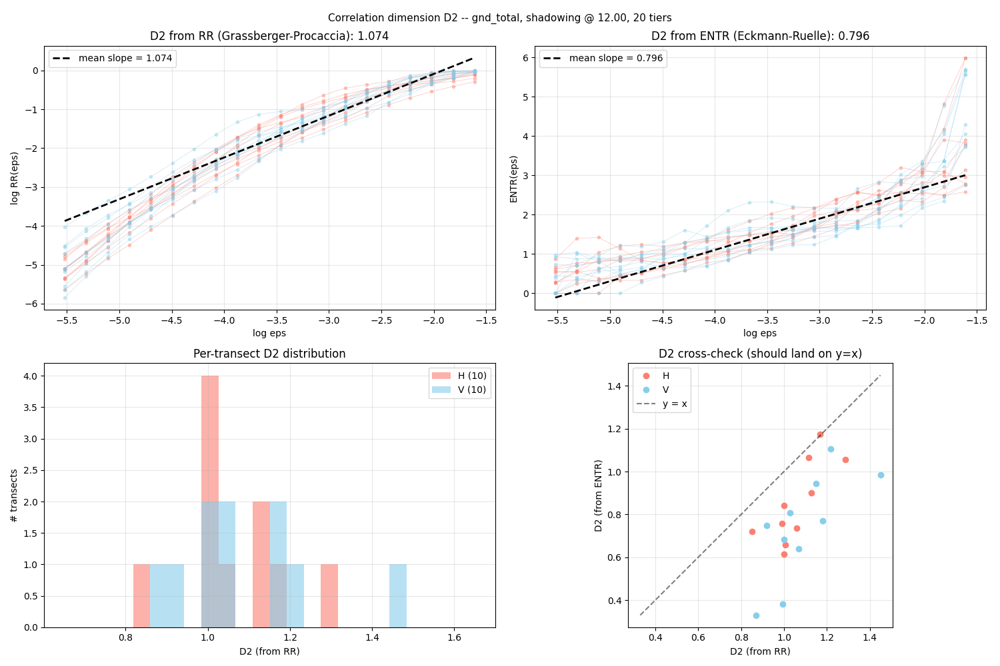


Stashed: d2_results_per_transect (per-transect D2_RR, D2_ENTR, fit R^2)


In [154]:
# ===== Correlation dimension D₂ from log RR(ε) and ENTR(ε) =====
# Many-tier (default 20) version of the per-tier RQA, used purely for slope
# fitting. Doesn't replace the 5-tier visual RPs.

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# ---- Parameters ----
D2_FIELD          = BX_FIELD if 'BX_FIELD' in globals() else 'gnd_total'
D2_FILTER         = (opt_filter_kind  if 'opt_filter_kind'  in globals()
                     else BX_FILTER   if 'BX_FILTER'        in globals() else 'gaussian')
D2_FILTER_PARAM   = (opt_filter_param if 'opt_filter_param' in globals()
                     else BX_FILTER_PARAM if 'BX_FILTER_PARAM' in globals() else 2.0)
D2_TAU            = (OPT_TAU_RESOLVED if 'OPT_TAU_RESOLVED' in globals()
                     else BX_TAU if 'BX_TAU' in globals() else 3)
D2_M              = (BX_M if 'BX_M' in globals() else 3)
D2_N_TIERS        = 20             # number of eps values
D2_EPS_MIN_FRAC   = 0.01           # smallest eps as fraction of d_ref
D2_EPS_MAX_FRAC   = 0.5             # largest eps as fraction of d_ref
D2_THEILER        = 1
D2_MAX_N          = 800
D2_N_TRANSECTS    = 10
D2_SEED           = 0
D2_FIT_RR_MIN_FRAC = 0.05            # exclude eps where RR < this for the fit
D2_FIT_RR_MAX_FRAC = 0.95           # exclude eps where RR > this for the fit
                                     # (avoid the saturated tails at both ends)

# ---- d_ref resolution ----
if 'd_ref' in globals() and isinstance(d_ref, (int, float)) and d_ref > 0:
    d_ref_d2 = float(d_ref)
elif 'bx_d_ref' in globals() and isinstance(bx_d_ref, (int, float)) and bx_d_ref > 0:
    d_ref_d2 = float(bx_d_ref)
else:
    raise RuntimeError('No d_ref in globals. Run cell 34 (filter sweep) or '
                        'cell 36 (box-and-whisker) first.')

eps_values = np.geomspace(D2_EPS_MIN_FRAC * d_ref_d2,
                           D2_EPS_MAX_FRAC * d_ref_d2,
                           D2_N_TIERS)
log_eps = np.log(eps_values)

# ---- Helpers ----
def _d2_RR_at_eps(emb, eps, max_n, theiler):
    n = len(emb)
    if n > max_n:
        ix = np.linspace(0, n - 1, max_n).astype(int); y = emb[ix]
    else:
        y = emb
    diff = y[:, None, :] - y[None, :, :]
    D = np.sqrt((diff ** 2).sum(axis=-1))
    R = (D <= eps)
    if theiler > 0:
        ii, jj = np.indices(R.shape)
        R &= (np.abs(ii - jj) > theiler)
    return float(R.mean())

def _d2_ENTR_at_eps(emb, eps, max_n, theiler, l_min=2):
    n = len(emb)
    if n > max_n:
        ix = np.linspace(0, n - 1, max_n).astype(int); y = emb[ix]
    else:
        y = emb
    diff = y[:, None, :] - y[None, :, :]
    D = np.sqrt((diff ** 2).sum(axis=-1))
    R = (D <= eps)
    if theiler > 0:
        ii, jj = np.indices(R.shape)
        R &= (np.abs(ii - jj) > theiler)
    N, M = R.shape
    diag_runs = []
    for offset in range(-(N-1), M):
        if abs(offset) <= theiler: continue
        diag_runs.append(_opt_runs(R.diagonal(offset)))
    d = np.concatenate(diag_runs) if diag_runs else np.empty(0, dtype=int)
    d_kept = d[d >= l_min]
    if d_kept.size == 0: return 0.0
    _, c = np.unique(d_kept, return_counts=True)
    pp = c / c.sum()
    return float(-(pp * np.log(pp + 1e-30)).sum())

# ---- Sample transects ----
F = rqa_fields[D2_FIELD]
ny, nx = F.shape
rng = np.random.default_rng(D2_SEED)
H_rows = rng.choice(ny, size=min(D2_N_TRANSECTS, ny), replace=False)
V_cols = rng.choice(nx, size=min(D2_N_TRANSECTS, nx), replace=False)
transects = ([(F[int(r), :], 'H', int(r)) for r in H_rows] +
             [(F[:, int(c)], 'V', int(c)) for c in V_cols])

# ---- Compute RR(eps) and ENTR(eps) per transect, fit D₂ ----
print(f'Computing RR(eps), ENTR(eps) at {D2_N_TIERS} eps values for '
      f'{len(transects)} transects...')
print(f'eps range: [{eps_values[0]:.4g}, {eps_values[-1]:.4g}]')

results = []
for ser, kind, idx in transects:
    s = ser[np.isfinite(ser)]
    if s.size < 50: continue
    s_filt = _opt_smooth(s, D2_FILTER, D2_FILTER_PARAM)
    emb = _opt_embed(s_filt, D2_TAU, D2_M)
    if emb is None or len(emb) < 30: continue
    rr_vals   = np.array([_d2_RR_at_eps  (emb, e, D2_MAX_N, D2_THEILER) for e in eps_values])
    entr_vals = np.array([_d2_ENTR_at_eps(emb, e, D2_MAX_N, D2_THEILER) for e in eps_values])

    # Fit log RR vs log eps in the linear (non-saturated) regime
    valid_rr = ((rr_vals > D2_FIT_RR_MIN_FRAC) &
                (rr_vals < D2_FIT_RR_MAX_FRAC) & (rr_vals > 0))
    if valid_rr.sum() >= 5:
        log_rr_v = np.log(rr_vals[valid_rr]); log_e_v = log_eps[valid_rr]
        slope_rr, intercept_rr = np.polyfit(log_e_v, log_rr_v, 1)
        pred = slope_rr * log_e_v + intercept_rr
        ss_res = np.sum((log_rr_v - pred) ** 2)
        ss_tot = np.sum((log_rr_v - log_rr_v.mean()) ** 2)
        r2_rr = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    else:
        slope_rr = intercept_rr = r2_rr = np.nan

    # Fit ENTR vs log eps over the same valid range
    if valid_rr.sum() >= 5 and (entr_vals[valid_rr] > 0).sum() >= 3:
        e_v = entr_vals[valid_rr]; log_e_v = log_eps[valid_rr]
        slope_entr, intercept_entr = np.polyfit(log_e_v, e_v, 1)
        pred = slope_entr * log_e_v + intercept_entr
        ss_res = np.sum((e_v - pred) ** 2)
        ss_tot = np.sum((e_v - e_v.mean()) ** 2)
        r2_entr = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    else:
        slope_entr = intercept_entr = r2_entr = np.nan

    results.append({'kind': kind, 'idx': idx,
                    'rr': rr_vals, 'entr': entr_vals,
                    'D2_RR': slope_rr, 'R2_RR': r2_rr,
                    'D2_ENTR': slope_entr, 'R2_ENTR': r2_entr,
                    'valid_rr': valid_rr})

# ---- Print summary ----
H_results = [r for r in results if r['kind'] == 'H']
V_results = [r for r in results if r['kind'] == 'V']

def _summary(name, lst):
    d2_rr = np.array([r['D2_RR'] for r in lst])
    d2_e  = np.array([r['D2_ENTR'] for r in lst])
    r2_rr = np.array([r['R2_RR'] for r in lst])
    r2_e  = np.array([r['R2_ENTR'] for r in lst])
    print(f'\n{name} ({len(lst)} transects):')
    print(f'  D2 from RR:   mean={np.nanmean(d2_rr):.3f}, std={np.nanstd(d2_rr):.3f}, '
          f'<R^2>={np.nanmean(r2_rr):.3f}')
    print(f'  D2 from ENTR: mean={np.nanmean(d2_e):.3f}, std={np.nanstd(d2_e):.3f}, '
          f'<R^2>={np.nanmean(r2_e):.3f}')

_summary('H rows', H_results)
_summary('V cols', V_results)
_summary('All',    results)

# ---- Plot ----
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (0, 0): log RR vs log eps -- all transects
ax = axes[0, 0]
for r in H_results:
    ax.plot(log_eps, np.log(r['rr'] + 1e-30), 'o-', color='salmon',
             alpha=0.4, markersize=3, lw=0.6)
for r in V_results:
    ax.plot(log_eps, np.log(r['rr'] + 1e-30), 'o-', color='skyblue',
             alpha=0.4, markersize=3, lw=0.6)
# Mean fit
mean_d2_rr = np.nanmean([r['D2_RR'] for r in results])
mean_int_rr = np.nanmean([np.log(r['rr'][r['valid_rr']]).mean() - mean_d2_rr * log_eps[r['valid_rr']].mean()
                           for r in results if not np.isnan(r['D2_RR'])])
ax.plot(log_eps, mean_d2_rr * log_eps + mean_int_rr, 'k--', lw=2,
         label=f'mean slope = {mean_d2_rr:.3f}')
ax.set(xlabel='log eps', ylabel='log RR(eps)',
        title=f'D2 from RR (Grassberger-Procaccia): {mean_d2_rr:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)

# (0, 1): ENTR vs log eps -- all transects
ax = axes[0, 1]
for r in H_results:
    ax.plot(log_eps, r['entr'], 'o-', color='salmon',
             alpha=0.4, markersize=3, lw=0.6)
for r in V_results:
    ax.plot(log_eps, r['entr'], 'o-', color='skyblue',
             alpha=0.4, markersize=3, lw=0.6)
mean_d2_e = np.nanmean([r['D2_ENTR'] for r in results])
mean_int_e = np.nanmean([r['entr'][r['valid_rr']].mean() - mean_d2_e * log_eps[r['valid_rr']].mean()
                          for r in results if not np.isnan(r['D2_ENTR'])])
ax.plot(log_eps, mean_d2_e * log_eps + mean_int_e, 'k--', lw=2,
         label=f'mean slope = {mean_d2_e:.3f}')
ax.set(xlabel='log eps', ylabel='ENTR(eps)',
        title=f'D2 from ENTR (Eckmann-Ruelle): {mean_d2_e:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)

# (1, 0): histogram of D2_RR
ax = axes[1, 0]
d2_h = np.array([r['D2_RR'] for r in H_results if not np.isnan(r['D2_RR'])])
d2_v = np.array([r['D2_RR'] for r in V_results if not np.isnan(r['D2_RR'])])
bins = np.linspace(min(np.nanmin(d2_h) if d2_h.size else 0,
                        np.nanmin(d2_v) if d2_v.size else 0) - 0.2,
                    max(np.nanmax(d2_h) if d2_h.size else 5,
                        np.nanmax(d2_v) if d2_v.size else 5) + 0.2, 25)
if d2_h.size: ax.hist(d2_h, bins=bins, color='salmon', alpha=0.6, label=f'H ({len(d2_h)})')
if d2_v.size: ax.hist(d2_v, bins=bins, color='skyblue', alpha=0.6, label=f'V ({len(d2_v)})')
ax.set(xlabel='D2 (from RR)', ylabel='# transects',
        title='Per-transect D2 distribution')
ax.legend(); ax.grid(True, alpha=0.3)

# (1, 1): D2_RR vs D2_ENTR scatter (sanity: should lie on y=x)
ax = axes[1, 1]
all_d2_rr = np.array([r['D2_RR']   for r in results])
all_d2_e  = np.array([r['D2_ENTR'] for r in results])
all_kinds = np.array([r['kind']    for r in results])
ok = np.isfinite(all_d2_rr) & np.isfinite(all_d2_e)
for k, color in [('H', 'salmon'), ('V', 'skyblue')]:
    sel = ok & (all_kinds == k)
    if sel.any():
        ax.plot(all_d2_rr[sel], all_d2_e[sel], 'o', color=color, ms=6, label=k)
if ok.sum():
    lo = min(all_d2_rr[ok].min(), all_d2_e[ok].min())
    hi = max(all_d2_rr[ok].max(), all_d2_e[ok].max())
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='y = x')
ax.set(xlabel='D2 (from RR)', ylabel='D2 (from ENTR)',
        title='D2 cross-check (should land on y=x)')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect('equal')

fig.suptitle(f'Correlation dimension D2 -- {D2_FIELD}, {D2_FILTER} @ '
             f'{D2_FILTER_PARAM:.2f}, {D2_N_TIERS} tiers',
             fontsize=11)
fig.tight_layout(); plt.show()

# Stash for downstream
d2_results_per_transect = results
print(f'\nStashed: d2_results_per_transect '
      f'(per-transect D2_RR, D2_ENTR, fit R^2)')


## Radial power spectrum P(k) — Turing peak detector

Wiener–Khinchin power spectrum, binned in radial annuli. Two diagnostics:

1. **Power-law regime** P(k) ∝ k^(–β) → Hurst exponent H = (β−1)/2. Confirms scale-free regime.
2. **Finite-k bumps** above the power-law fit → Turing-type characteristic wavelength λ = 1/k_peak. WTMM partition functions integrate this away — only P(k) reveals it. Compare λ to independent estimates of the compaction length δ_c = √(L_HH/L_MM) (Regenauer-Lieb 2026).

In [ ]:
# ===== Radial power spectrum P(k) of scalar fields =====
# Detects: (a) k^-beta power-law -> Hurst H, (b) finite-k bumps -> Turing wavelength.

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def _radial_power_spectrum(F, mask=None, hanning=True):
    F = np.asarray(F, dtype=np.float64).copy()
    if mask is not None and not mask.all():
        F = np.where(mask, F, np.nan)
    if np.any(~np.isfinite(F)):
        F = np.where(np.isfinite(F), F, np.nanmean(F))
    F = F - F.mean()
    if hanning:
        ny, nx = F.shape
        F = F * np.hanning(ny)[:, None] * np.hanning(nx)[None, :]
    Fhat = np.fft.fft2(F)
    P2d = np.fft.fftshift(np.abs(Fhat) ** 2)
    ny, nx = P2d.shape
    cy, cx = ny // 2, nx // 2
    yy, xx = np.indices(P2d.shape)
    rr = np.hypot(yy - cy, xx - cx).astype(int)
    k_max = int(min(cy, cx))
    Pk = np.zeros(k_max, dtype=np.float64)
    for k in range(k_max):
        sel = (rr == k)
        if sel.any():
            Pk[k] = P2d[sel].mean()
    k_arr = np.arange(k_max) / max(ny, nx)   # cycles/pixel
    return k_arr[1:], Pk[1:]

_field_dd_pk  = widgets.Dropdown(options=list(rqa_fields.keys()),
                                  description='Field:',
                                  layout=widgets.Layout(width='320px'))
_fit_kmin = widgets.FloatLogSlider(value=0.005, base=10, min=-3, max=-0.5, step=0.05,
    description='fit k_min:', readout_format='.4f',
    continuous_update=False, layout=widgets.Layout(width='340px'))
_fit_kmax = widgets.FloatLogSlider(value=0.2, base=10, min=-2, max=-0.3, step=0.05,
    description='fit k_max:', readout_format='.4f',
    continuous_update=False, layout=widgets.Layout(width='340px'))
_log_log = widgets.Checkbox(value=True, description='log-log',
    layout=widgets.Layout(width='120px'))
_detect_bump = widgets.Checkbox(value=True, description='Detect Turing bump',
    layout=widgets.Layout(width='220px'))
_mask_use = widgets.Checkbox(value=True, description='Mask outside grains',
    layout=widgets.Layout(width='200px'))

_px_label = float(px_um) if 'px_um' in globals() else 1.0
_pk_fig, _pk_axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=110)
plt.subplots_adjust(top=0.90, bottom=0.15, wspace=0.30)

# Stash results so other cells can compare across fields
pk_results = {}

def _refresh_pk(*_):
    name = _field_dd_pk.value
    F = rqa_fields.get(name)
    if F is None: return
    use_mask = combined_mask if (_mask_use.value and 'combined_mask' in globals()) else None
    k, Pk = _radial_power_spectrum(F, mask=use_mask, hanning=True)
    if k.size < 5 or Pk.max() <= 0: return
    win = (k >= _fit_kmin.value) & (k <= _fit_kmax.value) & (Pk > 0)
    if win.sum() >= 5:
        slope, intercept = np.polyfit(np.log(k[win]), np.log(Pk[win]), 1)
        beta = -slope; H = (beta - 1.0) / 2.0
    else:
        beta = H = slope = intercept = np.nan

    bump_k = bump_lambda_um = bump_amp = np.nan
    if _detect_bump.value and np.isfinite(slope):
        Pk_fit = np.exp(intercept + slope * np.log(k))
        residual = np.log10(Pk + 1e-30) - np.log10(Pk_fit + 1e-30)
        if win.sum() >= 5:
            i_peak = win.nonzero()[0][np.argmax(residual[win])]
            if residual[i_peak] > 0.15:
                bump_k = k[i_peak]
                bump_lambda_um = (1.0 / bump_k) * _px_label
                bump_amp = residual[i_peak]

    pk_results[name] = {'k': k, 'Pk': Pk, 'beta': beta, 'H': H,
                        'bump_k': bump_k, 'bump_lambda_um': bump_lambda_um,
                        'bump_amp': bump_amp}

    # Field heatmap
    _pk_axes[0].clear()
    F_disp = np.where(combined_mask, F, np.nan) if use_mask is not None else F
    vmax = float(np.nanpercentile(F_disp, 99))
    vmin = float(np.nanpercentile(F_disp, 1))
    _pk_axes[0].imshow(F_disp, cmap='gist_yarg', vmin=vmin, vmax=vmax, origin='upper')
    _pk_axes[0].set_xticks([]); _pk_axes[0].set_yticks([])
    _pk_axes[0].set_title(name, fontsize=10)

    # P(k) plot
    _pk_axes[1].clear()
    if _log_log.value:
        _pk_axes[1].loglog(k, Pk, 'k-', lw=1.0, label='P(k)')
    else:
        _pk_axes[1].plot(k, Pk, 'k-', lw=1.0, label='P(k)')
    if np.isfinite(slope):
        Pk_fit_plot = np.exp(intercept + slope * np.log(k))
        _pk_axes[1].plot(k[win], Pk_fit_plot[win], 'r--', lw=1.0,
                         label=fr'fit: $\beta$={beta:.2f}, H={H:.2f}')
    if np.isfinite(bump_k):
        lam_um = bump_lambda_um
        _pk_axes[1].axvline(bump_k, color='blue', linestyle=':', lw=1.0,
                            label=fr'bump: $\lambda$={lam_um:.1f} {"um" if "px_um" in globals() else "px"}')
    _pk_axes[1].set_xlabel('k (cycles / pixel)', fontsize=9)
    _pk_axes[1].set_ylabel('P(k)', fontsize=9)
    _pk_axes[1].legend(fontsize=8, loc='best')
    _pk_axes[1].grid(which='both', alpha=0.3)
    _pk_fig.canvas.draw_idle()

for _w in (_field_dd_pk, _fit_kmin, _fit_kmax, _log_log, _detect_bump, _mask_use):
    _w.observe(_refresh_pk, names='value')

display(widgets.HBox([_field_dd_pk, _mask_use]))
display(widgets.HBox([_fit_kmin, _fit_kmax]))
display(widgets.HBox([_log_log, _detect_bump]))
_refresh_pk()
plt.show()


## Angle-binned 2-point structure function S₂(r, θ) — anisotropy + Turing wavelength

S₂(r, θ) = ⟨[f(x+r) − f(x)]²⟩ binned by direction θ. Two diagnostics:

1. **First minimum / oscillation** in S₂ along any θ direction → Turing wavelength λ along that direction. Same physics as P(k) bump but more readable (real-space, not log-log).
2. **Anisotropy** of the first-minimum location across θ → directional patterning. Per H&O Claim H4 (fabric is kinematic), the principal anisotropy direction should align with the velocity-gradient eigenvector L, NOT with the principal strain axis. Eyeball the angle-binned curves to see if they collapse (isotropic) or split (foliation present).

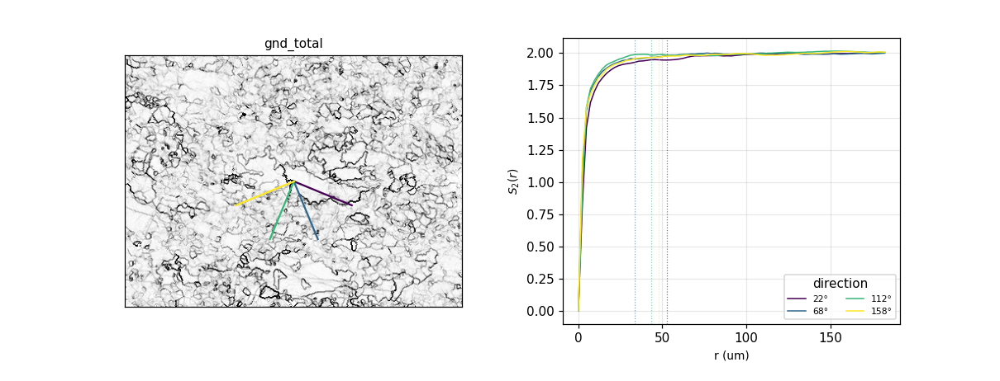

In [153]:
# ===== Angle-binned 2-point structure function S2(r, theta) =====
# Tests: (a) first-minimum -> Turing wavelength, (b) directional asymmetry -> H&O H4 (fabric kinematic).

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def _autocov_2d_norm(F, mask=None):
    F = np.asarray(F, dtype=np.float64).copy()
    if mask is not None and not mask.all():
        F = np.where(mask, F, np.nan)
    if np.any(~np.isfinite(F)):
        F = np.where(np.isfinite(F), F, np.nanmean(F))
    F = F - F.mean()
    Fhat = np.fft.fft2(F)
    P = np.abs(Fhat) ** 2
    C = np.fft.ifft2(P).real
    if abs(C.flat[0]) < 1e-30: return None
    C = C / C.flat[0]   # C(0) = 1
    return np.fft.fftshift(C)

def _angle_binned_S2(F, mask=None, n_bins=4, r_max=None):
    C = _autocov_2d_norm(F, mask=mask)
    if C is None: return None, None, None
    ny, nx = C.shape
    cy, cx = ny // 2, nx // 2
    yy, xx = np.indices(C.shape)
    dy = yy - cy; dx = xx - cx
    rr = np.hypot(dy, dx)
    th = np.mod(np.arctan2(dy, dx), np.pi)   # fold to [0, pi)
    if r_max is None:
        r_max = int(min(cy, cx))
    r_int = rr.astype(int)
    edges = np.linspace(0, np.pi, n_bins + 1)
    S2 = np.zeros((n_bins, r_max), dtype=np.float64)
    for it in range(n_bins):
        sec = (th >= edges[it]) & (th < edges[it + 1])
        for ir in range(r_max):
            sel = sec & (r_int == ir)
            if sel.any():
                S2[it, ir] = 2.0 * (1.0 - C[sel].mean())
    centers = 0.5 * (edges[:-1] + edges[1:])
    return np.arange(r_max), centers, S2

_field_dd_s2 = widgets.Dropdown(options=list(rqa_fields.keys()),
                                 description='Field:',
                                 layout=widgets.Layout(width='320px'))
_n_bins_w   = widgets.IntSlider(value=4, min=2, max=12, step=1,
                                 description='angle bins:', continuous_update=False,
                                 layout=widgets.Layout(width='280px'))
_mask_use2  = widgets.Checkbox(value=True, description='Mask outside grains',
                                layout=widgets.Layout(width='200px'))
_r_max_frac = widgets.FloatSlider(value=0.5, min=0.1, max=1.0, step=0.05,
                                   description='r_max frac:', continuous_update=False,
                                   layout=widgets.Layout(width='280px'))
_log_x      = widgets.Checkbox(value=False, description='log r',
                                layout=widgets.Layout(width='100px'))

s2_results = {}
_s2_fig, _s2_axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=110)
plt.subplots_adjust(top=0.90, bottom=0.15, wspace=0.30)

def _refresh_s2(*_):
    name = _field_dd_s2.value
    F = rqa_fields.get(name)
    if F is None: return
    mask = combined_mask if (_mask_use2.value and 'combined_mask' in globals()) else None
    r_arr, th_arr, S2_tab = _angle_binned_S2(F, mask=mask, n_bins=_n_bins_w.value)
    if r_arr is None: return
    r_max_use = max(2, int(_r_max_frac.value * len(r_arr)))
    r_arr = r_arr[:r_max_use]; S2_tab = S2_tab[:, :r_max_use]
    s2_results[name] = {'r': r_arr, 'theta': th_arr, 'S2': S2_tab}

    _s2_axes[0].clear()
    F_disp = np.where(combined_mask, F, np.nan) if mask is not None else F
    vmax = float(np.nanpercentile(F_disp, 99)); vmin = float(np.nanpercentile(F_disp, 1))
    _s2_axes[0].imshow(F_disp, cmap='gist_yarg', vmin=vmin, vmax=vmax, origin='upper')
    _s2_axes[0].set_xticks([]); _s2_axes[0].set_yticks([])
    _s2_axes[0].set_title(name, fontsize=10)
    cmap_a = plt.cm.viridis
    cy_, cx_ = F.shape[0] // 2, F.shape[1] // 2
    L = min(F.shape) // 4
    for it, th in enumerate(th_arr):
        col = cmap_a(it / max(1, len(th_arr) - 1))
        _s2_axes[0].plot([cx_, cx_ + L * np.cos(th)], [cy_, cy_ + L * np.sin(th)],
                          color=col, lw=1.5)

    _s2_axes[1].clear()
    px_lbl = float(px_um) if 'px_um' in globals() else 1.0
    r_phys = r_arr * px_lbl
    for it, th in enumerate(th_arr):
        col = cmap_a(it / max(1, len(th_arr) - 1))
        deg = np.degrees(th)
        _s2_axes[1].plot(r_phys, S2_tab[it], color=col, lw=1.0, label=f'{deg:.0f}°')
        # First local minimum (after r=2) below the asymptote -> Turing-like wavelength
        plateau = float(np.median(S2_tab[it, len(r_arr) // 2:])) if len(r_arr) >= 4 else 0.0
        for i in range(2, len(r_arr) - 1):
            if (S2_tab[it, i] < plateau and
                S2_tab[it, i] < S2_tab[it, i - 1] and
                S2_tab[it, i] < S2_tab[it, i + 1]):
                _s2_axes[1].axvline(r_phys[i], color=col, linestyle=':',
                                     lw=0.8, alpha=0.6)
                break
    if _log_x.value: _s2_axes[1].set_xscale('log')
    _s2_axes[1].set_xlabel(f'r ({"um" if "px_um" in globals() else "px"})', fontsize=9)
    _s2_axes[1].set_ylabel(r'$S_2(r)$', fontsize=9)
    _s2_axes[1].legend(fontsize=7, loc='best', ncol=2, title='direction')
    _s2_axes[1].grid(which='both', alpha=0.3)
    _s2_fig.canvas.draw_idle()

for _w in (_field_dd_s2, _n_bins_w, _mask_use2, _r_max_frac, _log_x):
    _w.observe(_refresh_s2, names='value')

display(widgets.HBox([_field_dd_s2, _mask_use2]))
display(widgets.HBox([_n_bins_w, _r_max_frac, _log_x]))
_refresh_s2()
plt.show()


## Takens validation — does `_opt_embed` actually reconstruct a known attractor?

Sanity check underwriting every embedding result above. The Lorenz butterfly is rebuilt from the scalar `x(t)` alone using this notebook's own `_opt_embed`. If it comes back, the embedding machinery is sound; if not, nothing downstream (RQA, D₂, FNN) can be trusted.

The brown-noise row is the trap: a random walk looks smooth and structured but is not deterministic, and it is the obvious null model for a spatially correlated microstructure field.


In [ ]:
# ===== Takens validation: reconstruct KNOWN attractors with THIS notebook's embedder =====
# Sanity check for every embedding result above. If _opt_embed can rebuild the Lorenz
# butterfly from the scalar x(t) alone, the embedding machinery is sound. If it can't,
# nothing downstream (RQA, D2, FNN) is trustworthy.
#
# tau too small -> trajectory collapses onto the diagonal (coordinates over-correlated)
# tau too large -> attractor folds and scrambles (coordinates effectively independent)
# The MI first minimum should land between those two failure modes.

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Prefer this notebook's own helpers (cell 34); fall back if that cell hasn't run.
_E   = globals().get('_opt_embed')
_MI  = globals().get('_opt_mi_first_min')
if _E is None:
    def _E(x, tau, m):
        n = len(x) - (m - 1) * tau
        return None if n <= 0 else np.column_stack([x[i*tau:i*tau+n] for i in range(m)])
if _MI is None:
    def _MI(x, max_lag=50, bins=24):
        x = np.asarray(x, float); out = np.full(min(max_lag+1, len(x)), np.nan)
        for lag in range(1, len(out)):
            h, _, _ = np.histogram2d(x[:-lag], x[lag:], bins=bins)
            p = h / h.sum() if h.sum() else h
            pa, pb = p.sum(1), p.sum(0)
            with np.errstate(divide='ignore', invalid='ignore'):
                lr = np.log(p / np.outer(pa, pb))
            out[lag] = float(np.nansum(np.where(p > 0, p * lr, 0.0)))
        for i in range(1, len(out)-1):
            if out[i] < out[i-1] and out[i] < out[i+1]:
                return i
        return 1


def _ref_lorenz(n=6000, dt=0.01, transient=2000):
    f = lambda t, s: [10.0*(s[1]-s[0]), s[0]*(28.0-s[2])-s[1], s[0]*s[1]-(8/3)*s[2]]
    T = (n+transient)*dt
    return solve_ivp(f, (0, T), [1., 1., 1.], t_eval=np.arange(0, T, dt),
                     rtol=1e-9, atol=1e-9).y.T[transient:transient+n]


def _ref_rossler(n=6000, dt=0.05, transient=2000):
    f = lambda t, s: [-s[1]-s[2], s[0]+0.2*s[1], 0.2+s[2]*(s[0]-5.7)]
    T = (n+transient)*dt
    return solve_ivp(f, (0, T), [1., 1., 1.], t_eval=np.arange(0, T, dt),
                     rtol=1e-9, atol=1e-9).y.T[transient:transient+n]


def _ref_brown(n=6000, seed=0):
    """Random walk: the null model for a spatially correlated microstructure field.
    Looks smooth and structured but is NOT deterministic -- the key adversarial control."""
    return np.cumsum(np.random.default_rng(seed).normal(size=(n, 3)), axis=0)


REF_SYSTEMS = {'Lorenz': _ref_lorenz(), 'Rossler': _ref_rossler(),
               'brown noise (random walk)': _ref_brown(),
               'white noise': np.random.default_rng(0).normal(size=(6000, 3))}

_val_taus = (1, 5, 17, 60)
_val_show = ('Lorenz', 'Rossler', 'brown noise (random walk)')
fig = plt.figure(figsize=(3.1*(len(_val_taus)+1), 3.1*len(_val_show)))
for r, nm in enumerate(_val_show):
    traj = REF_SYSTEMS[nm]; x = traj[:, 0]
    tau_mi = _MI(x, max_lag=120)
    ax = fig.add_subplot(len(_val_show), len(_val_taus)+1, r*(len(_val_taus)+1)+1,
                         projection='3d')
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], lw=0.3, color='#111111')
    ax.set_title(f'{nm}\nTRUE (x,y,z)', fontsize=8)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    for k, tau in enumerate(_val_taus):
        ax = fig.add_subplot(len(_val_show), len(_val_taus)+1,
                             r*(len(_val_taus)+1)+2+k, projection='3d')
        Y = _E(x, tau, 3)
        if Y is not None:
            ax.plot(Y[:, 0], Y[:, 1], Y[:, 2], lw=0.3, color='#c0392b')
        ax.set_title(f'_opt_embed(x, tau={tau}, m=3)'
                     + ('  <- MI' if abs(tau-tau_mi) <= 2 else ''), fontsize=8)
        ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
plt.tight_layout(); plt.show()

print('MI-suggested tau per reference system:')
for nm, tr in REF_SYSTEMS.items():
    print(f'  {nm:28s} tau = {_MI(tr[:, 0], max_lag=120)}')


## Determinism test — Cao E2 against IAAFT surrogates

Separates *deterministic* from merely *autocorrelated*, which FNN alone cannot do.

An absolute Cao-E2 threshold is not usable here — a random walk scores 0.605 on its own and would read "deterministic". Only the **excess over surrogates** carries information.

| surrogate | Lorenz z | brown-noise z | usable? |
|---|---|---|---|
| FT (phase-randomise) | 16.4 | 1.0 | assumes Gaussianity |
| AAFT | 16.7 | **5.2** | ❌ false positive (distorts spectrum ~28%) |
| **IAAFT** | 16.1 | **−0.4** | ✅ default |

The noise rows stay in the output as a permanent *"does this test lie?"* control: if brown noise ever reads significant, distrust the whole table.


In [ ]:
# ===== Determinism test: Cao E2 vs IAAFT surrogates =====
# Is a transect deterministic, or just autocorrelated?
#
# An ABSOLUTE Cao-E2 threshold does NOT answer this. Measured on this machinery:
#     Lorenz                    max|E2-1| = 0.938  -> "deterministic"  correct
#     brown noise (random walk) max|E2-1| = 0.605  -> "deterministic"  FALSE POSITIVE
#     white noise               max|E2-1| = 0.020  -> "stochastic"     correct
# A random walk is the obvious null for a spatially correlated microstructure field, so
# the statistic is only meaningful as an EXCESS OVER SURROGATES built from the signal.
#
# Three surrogate types, calibrated on brown noise (correct answer: not significant):
#     FT (phase-randomise)  Lorenz z=16.4   brown z= 1.0   assumes Gaussianity
#     AAFT                  Lorenz z=16.7   brown z= 5.2   FALSE POSITIVE (distorts spectrum ~28%)
#     IAAFT                 Lorenz z=16.1   brown z=-0.4   <- default
# IAAFT (Schreiber & Schmitz 1996) matches amplitude distribution AND power spectrum.
# The noise rows stay in the table below as a permanent "does this test lie?" control.

import numpy as np
from scipy.spatial import cKDTree

_E  = globals().get('_opt_embed', _E)
_MI = globals().get('_opt_mi_first_min', _MI)


def phase_randomise(x, rng):
    """FT surrogate: preserves the power spectrum. Null = linearly filtered Gaussian noise."""
    x = np.asarray(x, float); n = len(x); mu = x.mean()
    F = np.fft.rfft(x - mu); ph = rng.uniform(0, 2*np.pi, size=len(F)); ph[0] = 0.0
    if n % 2 == 0:
        ph[-1] = 0.0
    return np.fft.irfft(np.abs(F)*np.exp(1j*ph), n=n) + mu


def aaft(x, rng):
    """Amplitude-adjusted FT. Fixes Gaussianity but DISTORTS the spectrum -- unreliable
    on strongly autocorrelated data (see the brown-noise row)."""
    x = np.asarray(x, float)
    g = np.sort(rng.normal(size=len(x)))
    y = g[np.argsort(np.argsort(x))]
    return np.sort(x)[np.argsort(np.argsort(phase_randomise(y, rng)))]


def iaaft(x, rng, n_iter=100):
    """Iterative AAFT -- matches amplitude distribution AND power spectrum."""
    x = np.asarray(x, float); n = len(x)
    amp_t = np.abs(np.fft.rfft(x)); sx = np.sort(x)
    s = rng.permutation(x)
    for _ in range(n_iter):
        s = np.fft.irfft(amp_t*np.exp(1j*np.angle(np.fft.rfft(s))), n=n)
        s = sx[np.argsort(np.argsort(s))]
    return s


SURROGATES = {'IAAFT': iaaft, 'AAFT': aaft, 'FT': phase_randomise}


def cao_E1_E2(x, tau, m_max=8):
    """Cao (1997). E1 saturates at the embedding dimension; E2 == 1 for all m iff
    the data are stochastic (uses the max/Chebyshev norm, as in the paper)."""
    Em, Es = [], []
    for m in range(1, m_max + 2):
        Y, Y2 = _E(x, tau, m), _E(x, tau, m + 1)
        if Y is None or Y2 is None:
            Em.append(np.nan); Es.append(np.nan); continue
        n = min(len(Y), len(Y2))
        if n < 20:
            Em.append(np.nan); Es.append(np.nan); continue
        Y, Y2 = Y[:n], Y2[:n]
        d, j = cKDTree(Y).query(Y, k=2, p=np.inf)
        d1, nn = d[:, 1], j[:, 1]
        with np.errstate(divide='ignore', invalid='ignore'):
            Em.append(float(np.nanmean(np.max(np.abs(Y2 - Y2[nn]), axis=1)
                                        / np.where(d1 > 0, d1, np.nan))))
        Es.append(float(np.nanmean(np.abs(Y2[:, -1] - Y2[nn, -1]))))
    Em, Es = np.array(Em), np.array(Es)
    with np.errstate(divide='ignore', invalid='ignore'):
        return Em[1:]/Em[:-1], Es[1:]/Es[:-1]


def e2_deviation(x, tau, m_max=8):
    return float(np.nanmax(np.abs(cao_E1_E2(x, tau, m_max)[1] - 1)))


def determinism_test(x, kind='IAAFT', n_sur=19, m_max=8, seed=0, tau=None):
    """max|E2-1| of x vs an ensemble of surrogates. significant := z>3 and rank==n_sur."""
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if tau is None:
        tau = max(1, _MI(x, max_lag=min(50, max(8, len(x)//8))))
    d0 = e2_deviation(x, tau, m_max)
    rng = np.random.default_rng(seed)
    ds = np.array([e2_deviation(SURROGATES[kind](x, rng), tau, m_max)
                   for _ in range(n_sur)])
    z = float((d0 - np.nanmean(ds)) / (np.nanstd(ds) + 1e-12))
    rank = int(np.sum(d0 > ds))
    return dict(tau=int(tau), stat=d0, sur_mean=float(np.nanmean(ds)),
                sur_sd=float(np.nanstd(ds)), z=z, rank=rank, n_sur=n_sur,
                significant=bool(z > 3 and rank == n_sur))


# ---- Controls first: if brown noise reads SIGNIFICANT, distrust the whole table ----
DET_KIND, DET_NSUR, DET_NLINES = 'IAAFT', 19, 8
print(f'CONTROLS ({DET_KIND}, {DET_NSUR} surrogates) '
      f'-- Lorenz/Rossler must be significant, noise must not')
print(f"{'system':28s} {'tau':>4s} {'stat':>7s} {'z':>8s} {'rank':>7s}  verdict")
print('-' * 70)
for nm in ('Lorenz', 'Rossler', 'brown noise (random walk)', 'white noise'):
    r = determinism_test(REF_SYSTEMS[nm][:, 0], kind=DET_KIND, n_sur=DET_NSUR)
    print(f"{nm:28s} {r['tau']:4d} {r['stat']:7.3f} {r['z']:8.2f} "
          f"{r['rank']:3d}/{r['n_sur']}  "
          f"{'SIGNIFICANT' if r['significant'] else 'not significant'}")

# ---- Then the actual fields ----
_dt_fields = globals().get('rqa_fields')
if not isinstance(_dt_fields, dict) or not _dt_fields:
    print('\n`rqa_fields` not in scope -- run cell 28 first to screen real fields.')
else:
    print(f'\nFIELDS -- {DET_NLINES} horizontal scan lines each, median over lines')
    print(f"{'field':28s} {'n_ok':>5s} {'tau':>5s} {'stat':>7s} {'z':>8s} "
          f"{'frac sig':>9s}  verdict")
    print('-' * 78)
    for fname, F in _dt_fields.items():
        F = np.asarray(F)
        if F.ndim != 2:
            continue
        rows = np.linspace(0, F.shape[0]-1, DET_NLINES).astype(int)
        zs, st, ta, sig = [], [], [], 0
        for rr in rows:
            x = F[rr][np.isfinite(F[rr])]
            if len(x) < 192 or np.std(x) == 0:
                continue
            res = determinism_test(x, kind=DET_KIND, n_sur=DET_NSUR)
            zs.append(res['z']); st.append(res['stat']); ta.append(res['tau'])
            sig += int(res['significant'])
        if not zs:
            print(f'{fname:28s} {0:5d}   --      --       --        --   no valid lines')
            continue
        mz, frac = float(np.nanmedian(zs)), sig/len(zs)
        print(f'{fname:28s} {len(zs):5d} {np.median(ta):5.0f} {np.nanmedian(st):7.3f} '
              f'{mz:8.2f} {frac:8.0%}  '
              f"{'DETERMINISM SIGNIFICANT' if (mz > 3 and frac > 0.5) else 'not significant'}")
